In [1]:
from neuprint import Client, fetch_neurons, NeuronCriteria as NC, fetch_adjacencies
from dotenv import load_dotenv
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
from scipy.sparse import csr_matrix, save_npz, load_npz
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

# load the NEUPRINT_TOKEN from dotenv
load_dotenv()
NEUPRINT_TOKEN = os.getenv("NEUPRINT_TOKEN")

In [2]:
c = Client('https://neuprint.janelia.org', dataset='male-cns:v0.9', token=NEUPRINT_TOKEN)

In [3]:
# get all neurons
try:
    # load cached neurons if available
    with open('../../data/Male_CNS/neurons.pkl', 'rb') as f:
        neurons = pickle.load(f)
except FileNotFoundError:
    # fetch neurons from neuprint and cache them
    neurons = fetch_neurons(NC())
    with open('../../data/Male_CNS/neurons.pkl', 'wb') as f:
        pickle.dump(neurons, f)

In [4]:
try:
    # load cached connectivity matrix if available
    conn_matrix = pd.read_feather('../../data/Male_CNS/connectome-weights-male-cns-v0.9-minconf-0.5-normalized.feather')
except FileNotFoundError:
    # load the connectivity matrix from the feather file
    conn_matrix = pd.read_feather('../../data/Male_CNS/connectome-weights-male-cns-v0.9-minconf-0.5.feather')
    # Compute normalized weights efficiently using groupby
    weight_sums = conn_matrix.groupby('body_post')['weight'].sum()
    conn_matrix['total_weight'] = conn_matrix['body_post'].map(weight_sums)
    conn_matrix['normalized_weight'] = conn_matrix['weight'] / conn_matrix['total_weight']
    # save the updated conn_matrix with normalized weights
    conn_matrix.to_feather('../../data/Male_CNS/connectome-weights-male-cns-v0.9-minconf-0.5-normalized.feather')

In [5]:
if os.path.exists('../../data/Male_CNS/n_bodyIds_bodyId_idx_maps.pkl'):
    # load cached data if available
    with open('../../data/Male_CNS/n_bodyIds_bodyId_idx_maps.pkl', 'rb') as f:
        n, bodyIds, bodyId_to_idx, idx_to_bodyId = pickle.load(f)
else:
    # get unique bodyIds from conn_matrix
    bodyIds = pd.unique(conn_matrix[['body_pre', 'body_post']].values.ravel('K'))
    # create mappings
    bodyId_to_idx = {bodyId: idx for idx, bodyId in enumerate(bodyIds)}
    idx_to_bodyId = {idx: bodyId for bodyId, idx in bodyId_to_idx.items()}
    n = len(bodyIds)
    with open('../../data/Male_CNS/n_bodyIds_bodyId_idx_maps.pkl', 'wb') as f:
        pickle.dump((n, bodyIds, bodyId_to_idx, idx_to_bodyId), f)

In [6]:
try:
    # load cached connectivity matrices if available
    connectivity_matrix = load_npz('../../data/Male_CNS/connectivity_matrix.npz')
    connectivity_matrix_normalized = load_npz('../../data/Male_CNS/connectivity_matrix_normalized.npz')
except FileNotFoundError:
    # Map body_pre and body_post to indices
    row_indices = conn_matrix['body_pre'].map(bodyId_to_idx)
    col_indices = conn_matrix['body_post'].map(bodyId_to_idx)
    weights = conn_matrix['weight'].values
    
    # Create sparse matrix
    connectivity_matrix = csr_matrix((weights, (row_indices, col_indices)), shape=(n, n))
    # save the matrix
    save_npz('../../data/Male_CNS/connectivity_matrix.npz', connectivity_matrix)
    
    # also create the sparse matrix with normalized weights (post-normalized)
    normalized_weights = conn_matrix['normalized_weight'].values
    connectivity_matrix_normalized = csr_matrix((normalized_weights, (row_indices, col_indices)), shape=(n, n))
    # save the normalized matrix
    save_npz('../../data/Male_CNS/connectivity_matrix_normalized.npz', connectivity_matrix_normalized)

# Pre-normalized (row-normalized by body_pre) for downstream strength
if os.path.exists('../../data/Male_CNS/connectivity_matrix_pre_normalized.npz'):
    connectivity_matrix_pre_normalized = load_npz('../../data/Male_CNS/connectivity_matrix_pre_normalized.npz')
else:
    # Ensure pre-normalized weights exist
    if 'normalized_weight_pre' not in conn_matrix.columns:
        pre_sums = conn_matrix.groupby('body_pre')['weight'].sum()
        conn_matrix['total_weight_pre'] = conn_matrix['body_pre'].map(pre_sums)
        conn_matrix['normalized_weight_pre'] = conn_matrix['weight'] / conn_matrix['total_weight_pre']

    row_indices = conn_matrix['body_pre'].map(bodyId_to_idx)
    col_indices = conn_matrix['body_post'].map(bodyId_to_idx)
    pre_norm_weights = conn_matrix['normalized_weight_pre'].values

    connectivity_matrix_pre_normalized = csr_matrix(
        (pre_norm_weights, (row_indices, col_indices)), shape=(n, n)
    )
    save_npz('../../data/Male_CNS/connectivity_matrix_pre_normalized.npz', connectivity_matrix_pre_normalized)

In [7]:
def fetch_body_ids(**queries):
    """
    Fetch bodyIds matching all column queries (intersection).
    Usage:
      fetch_body_ids(type_=('P1', 'startswith'),
                     class_=('olfactory', 'exact'))
    Each query can be:
      - (value, match_type) where match_type in {'exact','startswith','endswith','contains'}
      - value (defaults to 'exact')

    Valid columns are 
    'type_', 'status', 'statusLabel', 'matchingNotes', 'somaNeuromere', 'subclass', 'celltypePredictedNt', 
    'flywireType', 'birthtime', 'tosomaLocation', 'exitNerve', 'fruDsx', 'receptorType', 'rootSide', 
    'entryNerve', 'class_', 'somaSide', 'trumanHl', 'synonyms', 'dimorphism', 'itoleeHl', 'hemibrainType', 
    'mancType', 'consensusNt', 'superclass', 'supertype', 'predictedNt', 'serialMotif'
    
    Note: For Python keywords (like 'type', 'class'), use trailing underscore (type_, class_)
    """
    neurons_df = neurons[0].copy()
    mask = pd.Series(True, index=neurons_df.index)

    for col, spec in queries.items():
        # Strip trailing underscore to handle Python keywords
        col_name = col.rstrip('_')
        
        if col_name not in ['type', 'status', 'statusLabel', 'matchingNotes', 'somaNeuromere', 'subclass', 'celltypePredictedNt', 'flywireType', 'birthtime', 'tosomaLocation', 'exitNerve', 'fruDsx', 'receptorType', 'rootSide', 'entryNerve', 'class', 'somaSide', 'trumanHl', 'synonyms', 'dimorphism', 'itoleeHl', 'hemibrainType', 'mancType', 'consensusNt', 'superclass', 'supertype', 'predictedNt', 'serialMotif']:
            raise ValueError(f"Column '{col_name}' not found in valid columns")

        if isinstance(spec, tuple):
            value, match_type = spec
        else:
            value, match_type = spec, "exact"

        s = neurons_df[col_name].astype(str)

        if match_type == "exact":
            col_mask = s.eq(str(value))
        elif match_type == "startswith":
            col_mask = s.str.startswith(str(value))
        elif match_type == "endswith":
            col_mask = s.str.endswith(str(value))
        elif match_type == "contains":
            col_mask = s.str.contains(str(value), regex=False)
        else:
            raise ValueError("match_type must be one of: exact, startswith, endswith, contains")

        mask &= col_mask

    return neurons_df.loc[mask, "bodyId"].values

In [8]:
def create_neuron_vector(bodyIds_list, values=None, dtype=None):
    """
    Create a sparse vector from a list of bodyIds with optional custom values.
    
    Args:
        bodyIds_list: List or array of bodyIds
        values: Optional array of values corresponding to each bodyId.
                If None, all values are set to 1.0
        dtype: Optional numpy dtype for values (e.g., np.float32)
        
    Returns:
        Sparse (1, n) vector with specified values at positions corresponding to bodyIds
    """
    # Filter valid bodyIds and get their indices
    if values is None:
        # Simple case: all 1s
        indices = [bodyId_to_idx[bodyId] for bodyId in bodyIds_list if bodyId in bodyId_to_idx]
        if len(indices) == 0:
            return csr_matrix((1, n))
        vals = np.ones(len(indices), dtype=dtype) if dtype is not None else np.ones(len(indices))
    else:
        # Custom values case
        indices = []
        vals = []
        for i, bodyId in enumerate(bodyIds_list):
            if bodyId in bodyId_to_idx:
                indices.append(bodyId_to_idx[bodyId])
                vals.append(values[i])
        if len(indices) == 0:
            return csr_matrix((1, n))
        vals = np.array(vals, dtype=dtype) if dtype is not None else np.array(vals)
    
    return csr_matrix((vals, (np.zeros(len(indices), dtype=int), indices)), shape=(1, n))


def _propagate_frontier(signal, matrix):
    """Efficiently propagate using only active rows (frontier-based)."""
    if signal.nnz == 0:
        return csr_matrix(signal.shape)

    idx = signal.indices
    vals = signal.data

    # Slice only active rows and compute weighted sum
    sub = matrix[idx, :]
    weights = csr_matrix((vals, (np.zeros(len(idx)), np.arange(len(idx)))), shape=(1, len(idx)))
    return (weights @ sub).tocsr()


def propagate_signal(
    source_bodyIds,
    values=None,
    max_order=5,
    return_sorted=True,
    return_arrays=False,
    return_sparse_arrays=True,
    dtype=None,
    method="iterative",
    matrix=None,
):
    """
    Propagate signal from source neurons through the network up to max_order hops.

    Methods:
        - "iterative" (default): repeatedly multiply by the base matrix. Low memory.
        - "frontier": multiply using only active rows (often faster for sparse fronts).
    
    Args:
        source_bodyIds: List or array of source neuron bodyIds
        values: Optional array of initial values for each bodyId. If None, all set to 1.0.
                Can be used to set different activation levels, odor responses, etc.
        max_order: Maximum number of hops (>=1)
        return_sorted: If True, sort results by signal strength (default: True)
        return_arrays: If True, also return the full signal arrays (default: False)
        return_sparse_arrays: If True and return_arrays is True, return sparse vectors instead of dense arrays.
        dtype: Optional numpy dtype for the source vector (e.g., np.float32)
        method: "iterative" or "frontier"
        matrix: Optional custom sparse matrix to use for propagation.
                Examples:
                  - connectivity_matrix (raw weights)
                  - connectivity_matrix_normalized (post-normalized)
                  - connectivity_matrix_pre_normalized (pre-normalized)
        
    Returns:
        If return_arrays=False:
            List of tuples [(bodyId, strength), ...] for each order
        If return_arrays=True:
            (results_list, arrays_list) where arrays_list contains full signal arrays
            (sparse vectors if return_sparse_arrays=True, else dense arrays)
            
    Example:
        # Uniform activation
        results = propagate_signal([bodyId1, bodyId2, bodyId3])
        
        # Custom activation levels
        results = propagate_signal([bodyId1, bodyId2, bodyId3], values=[0.5, 1.0, 0.8])
    """
    if max_order < 1:
        raise ValueError("max_order must be >= 1")

    if method not in {"iterative", "frontier"}:
        raise ValueError("method must be 'iterative' or 'frontier'")

    # create source vector with custom values
    source_vector = create_neuron_vector(source_bodyIds, values=values, dtype=dtype)
    
    results = []
    arrays = []

    mat = connectivity_matrix_pre_normalized if matrix is None else matrix

    signal = source_vector
    for _ in range(max_order):
        if method == "frontier":
            signal = _propagate_frontier(signal, mat)
        else:
            signal = (signal @ mat).tocsr()

        nonzero_idx = signal.indices
        nonzero_vals = signal.data
        order_results = [(idx_to_bodyId[idx], nonzero_vals[i]) for i, idx in enumerate(nonzero_idx)]

        if return_sorted:
            order_results.sort(key=lambda x: x[1], reverse=True)

        results.append(order_results)
        if return_arrays:
            arrays.append(signal if return_sparse_arrays else signal.toarray().ravel())
    
    if return_arrays:
        return results, arrays
    return results

In [12]:
# Find putative GABAergic AL interneurons with strong GABAergic input from other neurons

# 1) Candidate AL interneurons (heuristic: LN/local + AL/antennal/olfactory tags)
neuron_meta_cols = [
    'bodyId', 'type', 'class', 'subclass', 'superclass', 'supertype',
    'somaNeuromere', 'predictedNt', 'consensusNt', 'celltypePredictedNt',
    'hemibrainType', 'flywireType', 'mancType'
]
neuron_meta_cols = [c for c in neuron_meta_cols if c in neurons[0].columns]
meta = neurons[0][neuron_meta_cols].copy()

m_ln = pd.Series(False, index=meta.index)
m_al = pd.Series(False, index=meta.index)
for c in ['type', 'hemibrainType', 'flywireType', 'mancType', 'supertype']:
    if c in meta.columns:
        s = meta[c].astype(str)
        m_ln |= s.str.contains('LN|local', case=False, na=False)
        m_al |= s.str.contains('AL|antennal', case=False, na=False)
if 'class' in meta.columns:
    m_al |= meta['class'].astype(str).str.contains('olfactory', case=False, na=False)

al_ln_candidates = meta[m_ln & m_al].copy()

# 2) Putative GABA labels from available NT annotation columns
def is_putative_gaba(df):
    nt_cols = [c for c in ['consensusNt', 'predictedNt', 'celltypePredictedNt'] if c in df.columns]
    mask = pd.Series(False, index=df.index)
    for c in nt_cols:
        mask |= df[c].astype(str).str.lower().eq('gaba')
    return mask

gaba_mask = is_putative_gaba(meta)
putative_gaba_ids = set(meta.loc[gaba_mask, 'bodyId'].astype(int).tolist())

# Keep only AL-LN neurons that are putative GABAergic
al_ln_gaba = al_ln_candidates[al_ln_candidates['bodyId'].isin(putative_gaba_ids)].copy()
al_ln_gaba_ids = set(al_ln_gaba['bodyId'].astype(int).tolist())

# 3) Incoming connectivity onto these targets; quantify GABA->GABA input strengths
incoming = conn_matrix[conn_matrix['body_post'].isin(al_ln_gaba_ids)].copy()
incoming = incoming[incoming['body_pre'] != incoming['body_post']]
incoming['pre_is_gaba'] = incoming['body_pre'].isin(putative_gaba_ids)
incoming['post_is_gaba'] = incoming['body_post'].isin(putative_gaba_ids)
incoming = incoming[incoming['post_is_gaba']]

agg = incoming.groupby('body_post').agg(
    total_input_weight=('weight', 'sum'),
    gaba_input_weight=('weight', lambda x: x[incoming.loc[x.index, 'pre_is_gaba']].sum()),
    total_input_norm=('normalized_weight', 'sum'),
    gaba_input_norm=('normalized_weight', lambda x: x[incoming.loc[x.index, 'pre_is_gaba']].sum()),
    gaba_edge_count=('pre_is_gaba', 'sum'),
    edge_count=('pre_is_gaba', 'size')
)
agg['gaba_frac_weight'] = agg['gaba_input_weight'] / agg['total_input_weight'].replace(0, np.nan)
agg['gaba_frac_norm'] = agg['gaba_input_norm'] / agg['total_input_norm'].replace(0, np.nan)

# Strong = top quartile by GABA input weight among the filtered targets
if len(agg) > 0:
    strong_cutoff = agg['gaba_input_weight'].quantile(0.75)
else:
    strong_cutoff = np.nan

ranked = agg.sort_values(['gaba_input_weight', 'gaba_frac_weight'], ascending=False).reset_index()
ranked = ranked.merge(
    meta[['bodyId', 'type', 'class', 'supertype', 'consensusNt', 'predictedNt']],
    left_on='body_post', right_on='bodyId', how='left'
)
ranked['strong_gaba_input'] = ranked['gaba_input_weight'] >= strong_cutoff

print(f"AL-LN candidates: {len(al_ln_candidates)}")
print(f"Putative GABA AL-LN candidates: {len(al_ln_gaba)}")
print(f"Targets with any incoming edges in conn_matrix: {len(ranked)}")
print(f"Strong-input cutoff (75th percentile of gaba_input_weight): {strong_cutoff:.2f}" if len(ranked) else "No ranked targets")

display_cols = [
    'body_post', 'type', 'class', 'supertype', 'consensusNt', 'predictedNt',
    'gaba_input_weight', 'total_input_weight', 'gaba_frac_weight',
    'gaba_edge_count', 'edge_count', 'strong_gaba_input'
]
ranked_top = ranked[display_cols].head(30)
ranked_top

AL-LN candidates: 2
Putative GABA AL-LN candidates: 2
Targets with any incoming edges in conn_matrix: 2
Strong-input cutoff (75th percentile of gaba_input_weight): 662.50


,body_post,type,class,supertype,consensusNt,predictedNt,gaba_input_weight,total_input_weight,gaba_frac_weight,gaba_edge_count,edge_count,strong_gaba_input
0,11566,ALIN4,ALIN,11566,gaba,gaba,684,4052,0.168806,109,1526,True
1,11644,ALIN4,ALIN,11566,gaba,gaba,598,4086,0.146353,97,1434,False


In [13]:
# Top GABAergic presynaptic partners for each ranked target
partner_tables = {}
for target_id in ranked['body_post'].tolist():
    sub = incoming[(incoming['body_post'] == target_id) & (incoming['pre_is_gaba'])].copy()
    partner = (
        sub.groupby('body_pre')
        .agg(weight=('weight', 'sum'), normalized_weight=('normalized_weight', 'sum'))
        .sort_values('weight', ascending=False)
        .reset_index()
    )
    partner = partner.merge(
        meta[['bodyId', 'type', 'class', 'consensusNt', 'predictedNt']],
        left_on='body_pre', right_on='bodyId', how='left'
    )
    partner['is_self'] = partner['body_pre'] == target_id
    partner_tables[target_id] = partner

for target_id, tbl in partner_tables.items():
    print(f"\nTarget {target_id} ({ranked.loc[ranked['body_post']==target_id, 'type'].iloc[0]}): top GABA presynaptic partners")
    display(tbl[['body_pre', 'type', 'class', 'weight', 'normalized_weight', 'is_self']].head(15))


Target 11566 (ALIN4): top GABA presynaptic partners


,body_pre,type,class,weight,normalized_weight,is_self
0,11193,ALIN6,ALIN,178,0.043929,False
1,12759,ALIN6,ALIN,169,0.041708,False
2,10310,GNG073,None,53,0.013080,False
3,11419,WED195,None,36,0.008885,False
4,76858,GNG073,None,26,0.006417,False
5,15673,DNg20,None,15,0.003702,False
6,10831,WED195,None,14,0.003455,False
7,73179,AN00A009,None,10,0.002468,False
8,523591,il3LN6,ALLN,8,0.001974,False
9,13883,AN17B005,None,8,0.001974,False



Target 11644 (ALIN4): top GABA presynaptic partners


,body_pre,type,class,weight,normalized_weight,is_self
0,12759,ALIN6,ALIN,161,0.039403,False
1,11193,ALIN6,ALIN,137,0.033529,False
2,10310,GNG073,None,50,0.012237,False
3,15673,DNg20,None,31,0.007587,False
4,76858,GNG073,None,29,0.007097,False
5,10831,WED195,None,23,0.005629,False
6,13348,DNg20,None,7,0.001713,False
7,529031,GNG300,None,6,0.001468,False
8,10967,DNg70,None,6,0.001468,False
9,11419,WED195,None,6,0.001468,False


In [14]:
# Broader check: all putative GABA neurons in ALIN/ALLN classes (not just LN/local heuristic)
meta_all = neurons[0].copy()

# Putative GABA call
def is_putative_gaba_df(df):
    nt_cols = [c for c in ['consensusNt', 'predictedNt', 'celltypePredictedNt'] if c in df.columns]
    m = pd.Series(False, index=df.index)
    for col in nt_cols:
        m |= df[col].astype(str).str.lower().eq('gaba')
    return m

all_gaba = is_putative_gaba_df(meta_all)

class_mask = pd.Series(False, index=meta_all.index)
if 'class' in meta_all.columns:
    class_mask |= meta_all['class'].astype(str).str.upper().isin(['ALIN', 'ALLN'])

type_mask = pd.Series(False, index=meta_all.index)
if 'type' in meta_all.columns:
    type_mask |= meta_all['type'].astype(str).str.contains('ALIN|LN', case=False, na=False)

# Broad AL-inhibitory candidate pool
broad_targets = meta_all[(all_gaba) & (class_mask | type_mask)].copy()
broad_ids = set(broad_targets['bodyId'].astype(int).tolist())
all_gaba_ids = set(meta_all.loc[all_gaba, 'bodyId'].astype(int).tolist())

broad_in = conn_matrix[conn_matrix['body_post'].isin(broad_ids)].copy()
broad_in = broad_in[broad_in['body_pre'] != broad_in['body_post']]
broad_in['pre_gaba'] = broad_in['body_pre'].isin(all_gaba_ids)

broad_rank = broad_in.groupby('body_post').agg(
    total_input_weight=('weight', 'sum'),
    gaba_input_weight=('weight', lambda x: x[broad_in.loc[x.index, 'pre_gaba']].sum()),
    gaba_edge_count=('pre_gaba', 'sum'),
    edge_count=('pre_gaba', 'size')
)
broad_rank['gaba_frac_weight'] = broad_rank['gaba_input_weight'] / broad_rank['total_input_weight'].replace(0, np.nan)

if len(broad_rank):
    broad_rank['strong_q75'] = broad_rank['gaba_input_weight'] >= broad_rank['gaba_input_weight'].quantile(0.75)
    broad_rank['strong_q90'] = broad_rank['gaba_input_weight'] >= broad_rank['gaba_input_weight'].quantile(0.90)

broad_rank = broad_rank.sort_values('gaba_input_weight', ascending=False).reset_index()
broad_rank = broad_rank.merge(
    meta_all[['bodyId', 'type', 'class', 'consensusNt', 'predictedNt']],
    left_on='body_post', right_on='bodyId', how='left'
)

print(f"Broad GABA ALIN/ALLN targets with incoming edges: {len(broad_rank)}")
print(f"Q75 strong count: {int(broad_rank['strong_q75'].sum()) if len(broad_rank) else 0}")
print(f"Q90 strong count: {int(broad_rank['strong_q90'].sum()) if len(broad_rank) else 0}")

display(broad_rank[['body_post','type','class','gaba_input_weight','total_input_weight','gaba_frac_weight','gaba_edge_count','edge_count','strong_q75','strong_q90']].head(25))

# Where do the two ALIN4 neurons fall in the broad ranking?
query_ids = [11566, 11644]
subset = broad_rank[broad_rank['body_post'].isin(query_ids)][['body_post','type','class','gaba_input_weight','gaba_frac_weight','strong_q75','strong_q90']]
print('\nALIN4 targets in broad ranking:')
display(subset)


Broad GABA ALIN/ALLN targets with incoming edges: 134
Q75 strong count: 34
Q90 strong count: 14


,body_post,type,class,gaba_input_weight,total_input_weight,gaba_frac_weight,gaba_edge_count,edge_count,strong_q75,strong_q90
0,10515,lLN2F_b,ALLN,4876,41323,0.117997,89,4861,True,True
1,10169,lLN2F_b,ALLN,4594,41853,0.109765,82,4667,True,True
2,523591,il3LN6,ALLN,4259,51082,0.083376,136,5360,True,True
3,10473,il3LN6,ALLN,4220,54791,0.077020,145,5639,True,True
4,10254,lLN2F_a,ALLN,3759,28669,0.131117,63,3802,True,True
5,10456,lLN2F_a,ALLN,3690,29036,0.127084,57,3908,True,True
6,67052,lLN2T_b,ALLN,3351,30272,0.110696,59,3711,True,True
7,10376,lLN2F_b,ALLN,2968,41043,0.072314,68,5018,True,True
8,10133,lLN2F_b,ALLN,2830,39488,0.071667,66,5168,True,True
9,16460,lLN2T_b,ALLN,2597,22770,0.114054,67,3121,True,True



ALIN4 targets in broad ranking:


,body_post,type,class,gaba_input_weight,gaba_frac_weight,strong_q75,strong_q90
26,11566,ALIN4,ALIN,684,0.168806,True,False
32,11644,ALIN4,ALIN,598,0.146353,True,False


In [15]:
broad_targets

,bodyId,instance,type,pre,post,downstream,upstream,size,status,statusLabel,...,assignedOlHex2,group,supertype,mancBodyid,totalNtPredictions,predictedNt,mancGroup,serialMotif,inputRois,outputRois
119,10133,lLN2F_b(Full)_L,lLN2F_b,8904,39488,39472,39488,9.141898e+09,Traced,Prelim Roughly traced,...,NaN,10133.0,10096,NaN,8904.0,gaba,NaN,None,"[AL(L), CentralBrain, CentralBrain-unspecified...","[AL(L), CentralBrain, CentralBrain-unspecified..."
153,10169,lLN2F_b(Full)_R,lLN2F_b,9970,41853,43101,41853,9.276834e+09,Traced,Prelim Roughly traced,...,NaN,10133.0,10096,NaN,9970.0,gaba,NaN,None,"[AL(R), CentralBrain, CentralBrain-unspecified...","[AL(R), CentralBrain, CentralBrain-unspecified]"
233,10254,lLN2F_a(Full)_R,lLN2F_a,6824,28669,26933,28669,6.528086e+09,Traced,Prelim Roughly traced,...,NaN,10096.0,10096,NaN,6824.0,gaba,NaN,None,"[AL(R), CentralBrain, CentralBrain-unspecified...","[AL(R), CentralBrain, CentralBrain-unspecified]"
348,10376,lLN2F_b(Full)_L,lLN2F_b,9455,41043,42129,41043,9.299929e+09,Traced,Prelim Roughly traced,...,NaN,10133.0,10096,NaN,9455.0,gaba,NaN,None,"[AL(L), CentralBrain, CentralBrain-unspecified...","[AL(L), CentralBrain, CentralBrain-unspecified..."
420,10456,lLN2F_a(Full)_R,lLN2F_a,6856,29036,27797,29036,5.939876e+09,Traced,Prelim Roughly traced,...,NaN,10096.0,10096,NaN,6856.0,gaba,NaN,None,"[AL(R), CentralBrain, CentralBrain-unspecified...","[AL(R), CentralBrain, CentralBrain-unspecified]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147100,551294,lLN2P_c_R,lLN2P_c,1796,8346,8414,8346,1.727964e+09,Traced,Prelim Roughly traced,...,NaN,NaN,11603,NaN,1796.0,gaba,NaN,None,"[AL(R), CentralBrain, CentralBrain-unspecified...","[AL(R), CentralBrain, CentralBrain-unspecified..."
147779,555322,lLN2X02_L,lLN2X02,960,3739,5101,3739,1.563126e+09,Traced,Prelim Roughly traced,...,NaN,NaN,12511,NaN,960.0,gaba,NaN,None,"[AL(L), CentralBrain, CentralBrain-unspecified]","[AL(L), CentralBrain, CentralBrain-unspecified]"
147949,556502,LNO1_R,LNO1,685,2580,4385,2580,1.036255e+09,Traced,Roughly traced,...,NaN,17016.0,None,NaN,685.0,unclear,NaN,None,"[AVLP(R), CRE(R), CentralBrain, CentralBrain-u...","[CRE(R), CentralBrain, LAL(R), NO]"
148718,564824,lLN2R_a_R,lLN2R_a,1007,3034,4019,3034,9.213227e+08,Traced,Prelim Roughly traced,...,NaN,14343.0,14343,NaN,1007.0,gaba,NaN,None,"[AL(R), CentralBrain, CentralBrain-unspecified]","[AL(R), CentralBrain, CentralBrain-unspecified]"


In [10]:
# use optimized propagation function
olfactory_neurons = fetch_body_ids(class_=('olfactory', 'exact'))
results = propagate_signal(olfactory_neurons, max_order=3, return_sorted=True)

# unpack results
first_order_bodyIds, second_order_bodyIds, third_order_bodyIds = results

print(f"First order: {len(first_order_bodyIds)} neurons")
print(f"Second order: {len(second_order_bodyIds)} neurons")
print(f"Third order: {len(third_order_bodyIds)} neurons")

First order: 379743 neurons
Second order: 3088477 neurons
Third order: 46059951 neurons


In [17]:
MBON_bodyIds = fetch_body_ids(type_=('MBON', 'startswith'))
neurons[0][neurons[0]['bodyId'].isin(MBON_bodyIds)]

,bodyId,instance,type,pre,post,downstream,upstream,size,status,statusLabel,...,assignedOlHex2,group,supertype,mancBodyid,totalNtPredictions,predictedNt,mancGroup,serialMotif,inputRois,outputRois
9,10013,MBON01(y5B'2a)_R,MBON01,2616,25357,23601,25357,4.723838e+09,Traced,Roughly traced,...,NaN,10013.0,None,NaN,2616.0,glutamate,NaN,None,"[CRE(L), CRE(R), CentralBrain, CentralBrain-un...","[CRE(L), CRE(R), CentralBrain, CentralBrain-un..."
66,10079,MBON06(B1>a)_R,MBON06,1406,15258,9692,15258,2.580791e+09,Traced,Roughly traced,...,NaN,10079.0,None,NaN,1406.0,glutamate,NaN,None,"[CRE(L), CentralBrain, CentralBrain-unspecifie...","[CRE(L), CentralBrain, CentralBrain-unspecifie..."
246,10267,MBON14(a3)_R,MBON14,565,5918,4357,5918,1.229307e+09,Traced,Roughly traced,...,NaN,10267.0,10267,NaN,565.0,acetylcholine,NaN,None,"[CentralBrain, CentralBrain-unspecified, PRW, ...","[CentralBrain, SIP(R), SLP(R), SMP(R), a'L(R),..."
459,10495,MBON05(y4>y1y2)_R,MBON05,2000,23812,14684,23812,3.746016e+09,Traced,Roughly traced,...,NaN,10495.0,None,NaN,2000.0,unclear,NaN,None,"[BU(R), CRE(L), CentralBrain, CentralBrain-uns...","[BU(R), CRE(L), CentralBrain, CentralBrain-uns..."
558,10599,MBON35(y2)_L,MBON35,2221,26172,19643,26172,2.859859e+09,Traced,Roughly traced,...,NaN,10599.0,None,NaN,2221.0,acetylcholine,NaN,None,"[AL(L), AOTU(L), CRE(L), CentralBrain, Central...","[AOTU(L), CRE(L), CentralBrain, CentralBrain-u..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143513,540383,MBON10(B'1)_R,MBON10,190,714,1415,714,3.196596e+08,Traced,Roughly traced,...,NaN,39608.0,27954,NaN,190.0,gaba,NaN,None,"[CRE(R), CentralBrain, CentralBrain-unspecifie...","[CRE(R), CentralBrain, LAL(R), SIP(R), SMP(R),..."
147912,556300,MBON25-like(y1y2)_R,MBON25-like,368,695,2733,695,3.742415e+08,Traced,Prelim Roughly traced,...,NaN,110448.0,25975,NaN,368.0,glutamate,NaN,None,"[CRE(L), CRE(R), CentralBrain, CentralBrain-un...","[CRE(L), CRE(R), CentralBrain, CentralBrain-un..."
148238,558665,MBON10(B'1)_R,MBON10,157,832,1153,832,2.643490e+08,Traced,Roughly traced,...,NaN,39608.0,27954,NaN,157.0,gaba,NaN,None,"[CRE(R), CentralBrain, CentralBrain-unspecifie...","[CRE(R), CentralBrain, SIP(R), SMP(R), a'L(R),..."
148591,562782,MBON16(a'3ap)_R,MBON16,625,2729,5599,2729,7.552894e+08,Traced,Roughly traced,...,NaN,520186.0,11777,NaN,625.0,acetylcholine,NaN,None,"[CentralBrain, CentralBrain-unspecified, LH(L)...","[CentralBrain, CentralBrain-unspecified, LH(L)..."


In [18]:
FBt_bodyIds = fetch_body_ids(type_=('FB', 'startswith'))
neurons[0][neurons[0]['bodyId'].isin(FBt_bodyIds)]

,bodyId,instance,type,pre,post,downstream,upstream,size,status,statusLabel,...,assignedOlHex2,group,supertype,mancBodyid,totalNtPredictions,predictedNt,mancGroup,serialMotif,inputRois,outputRois
365,10396,FB2F_a_L,FB2F_a,567,1017,4799,1017,6.219642e+08,Traced,Roughly traced,...,NaN,10396.0,10396,NaN,567.0,glutamate,NaN,None,"[ATL(L), CRE(L), CentralBrain, CentralBrain-un...","[CentralBrain, CentralBrain-unspecified, FB, S..."
417,10453,FB6A_a_L,FB6A_a,2817,4415,12684,4415,2.375948e+09,Traced,Roughly traced,...,NaN,10453.0,10453,NaN,2817.0,glutamate,NaN,None,"[BU(R), CA(L), CentralBrain, CentralBrain-unsp...","[CentralBrain, CentralBrain-unspecified, FB, S..."
477,10514,FB6A_c_R,FB6A_c,2350,5004,12206,5004,2.231741e+09,Traced,Roughly traced,...,NaN,10514.0,10453,NaN,2350.0,glutamate,NaN,None,"[BU(R), CentralBrain, CentralBrain-unspecified...","[BU(R), CentralBrain, CentralBrain-unspecified..."
529,10568,FB4L_R,FB4L,379,2583,1606,2583,1.245089e+09,Traced,Roughly traced,...,NaN,10568.0,10568,NaN,379.0,dopamine,NaN,None,"[AB(R), AOTU(R), BU(R), CRE(R), CentralBrain, ...","[AB(R), AOTU(R), CentralBrain, CentralBrain-un..."
690,10744,FB5A_R,FB5A,1289,5520,11543,5520,1.705934e+09,Traced,Roughly traced,...,NaN,10744.0,10744,NaN,1289.0,gaba,NaN,None,"[BU(R), CRE(R), CentralBrain, CentralBrain-uns...","[CRE(R), CentralBrain, CentralBrain-unspecifie..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149564,580653,FB1B_R,FB1B,293,835,1928,835,4.190842e+08,Traced,Roughly traced,...,NaN,29016.0,29016,NaN,293.0,glutamate,NaN,None,"[AB(L), AB(R), CentralBrain, CentralBrain-unsp...","[AB(L), AB(R), CentralBrain, CentralBrain-unsp..."
149612,580819,FB5R_R,FB5R,162,920,914,920,2.177813e+08,Traced,Prelim Roughly traced,...,NaN,148726.0,31585,NaN,162.0,glutamate,NaN,None,"[CentralBrain, CentralBrain-unspecified, FB]","[CentralBrain, CentralBrain-unspecified, FB]"
149787,581422,FB5V_a_R,FB5V_a,271,1289,1872,1289,4.129331e+08,Traced,Roughly traced,...,NaN,23473.0,12311,NaN,271.0,glutamate,NaN,None,"[CRE(R), CentralBrain, CentralBrain-unspecifie...","[CRE(R), CentralBrain, CentralBrain-unspecifie..."
149910,588507,FB5W_b_R,FB5W_b,180,477,1327,477,2.723992e+08,Traced,Prelim Roughly traced,...,NaN,149891.0,11994,NaN,180.0,glutamate,NaN,None,"[CRE(R), CentralBrain, CentralBrain-unspecifie...","[CRE(R), CentralBrain, FB, LAL(R), bL(R)]"


In [11]:
# get all bodyIds of P1 neurons
P1_bodyIds = fetch_body_ids(type_=('P1_', 'startswith'))
neurons[0][neurons[0]['bodyId'].isin(P1_bodyIds)]

,bodyId,instance,type,pre,post,downstream,upstream,size,status,statusLabel,...,assignedOlHex2,group,supertype,mancBodyid,totalNtPredictions,predictedNt,mancGroup,serialMotif,inputRois,outputRois
2285,12442,P1_4a_L,P1_4a,735,2690,5067,2690,7.938411e+08,Traced,Roughly traced,...,NaN,12442.0,12442,NaN,735.0,acetylcholine,NaN,None,"[AOTU(L), AVLP(L), AVLP(R), CentralBrain, Cent...","[AVLP(L), AVLP(R), CentralBrain, CentralBrain-..."
2290,12448,P1_18a_L,P1_18a,1013,1510,7927,1510,1.181694e+09,Traced,Roughly traced,...,NaN,12448.0,10217,NaN,1013.0,acetylcholine,NaN,None,"[AVLP(L), CentralBrain, CentralBrain-unspecifi...","[CentralBrain, CentralBrain-unspecified, SCL(L..."
3057,13266,P1_3b_L,P1_3b,962,2306,7801,2306,1.087628e+09,Traced,Roughly traced,...,NaN,13266.0,12442,NaN,962.0,acetylcholine,NaN,None,"[AVLP(L), AVLP(R), CentralBrain, CentralBrain-...","[AVLP(L), AVLP(R), CentralBrain, CentralBrain-..."
3267,13495,P1_11a_R,P1_11a,953,3191,7807,3191,1.334601e+09,Traced,Roughly traced,...,NaN,13495.0,13495,NaN,953.0,acetylcholine,NaN,None,"[AOTU(R), AVLP(L), AVLP(R), CentralBrain, Cent...","[AVLP(L), AVLP(R), CentralBrain, CentralBrain-..."
3327,13562,P1_12b_L,P1_12b,763,1617,5831,1617,9.347908e+08,Traced,Roughly traced,...,NaN,13562.0,13562,NaN,763.0,acetylcholine,NaN,None,"[AVLP(L), AVLP(R), CentralBrain, CentralBrain-...","[AVLP(L), AVLP(R), CentralBrain, CentralBrain-..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147799,555488,P1_9a_L,P1_9a,744,1779,5656,1779,9.366389e+08,Traced,Roughly traced,...,NaN,15876.0,15876,NaN,744.0,acetylcholine,NaN,None,"[AOTU(L), AVLP(L), CentralBrain, CentralBrain-...","[AOTU(L), AVLP(L), CentralBrain, CentralBrain-..."
147836,555746,P1_13b_R,P1_13b,565,1245,4316,1245,7.328690e+08,Traced,Roughly traced,...,NaN,21538.0,13562,NaN,565.0,acetylcholine,NaN,None,"[AOTU(R), AVLP(R), CentralBrain, CentralBrain-...","[AVLP(R), CentralBrain, CentralBrain-unspecifi..."
147837,555747,P1_13c_R,P1_13c,537,1090,4312,1090,6.342511e+08,Traced,Roughly traced,...,NaN,23787.0,13562,NaN,537.0,acetylcholine,NaN,None,"[AOTU(R), AVLP(R), CentralBrain, CentralBrain-...","[AVLP(R), CentralBrain, CentralBrain-unspecifi..."
147838,555751,P1_9a_R,P1_9a,649,1745,4950,1745,9.414752e+08,Traced,Roughly traced,...,NaN,15876.0,15876,NaN,649.0,acetylcholine,NaN,None,"[AOTU(R), AVLP(R), CentralBrain, CentralBrain-...","[AVLP(R), CentralBrain, CentralBrain-unspecifi..."


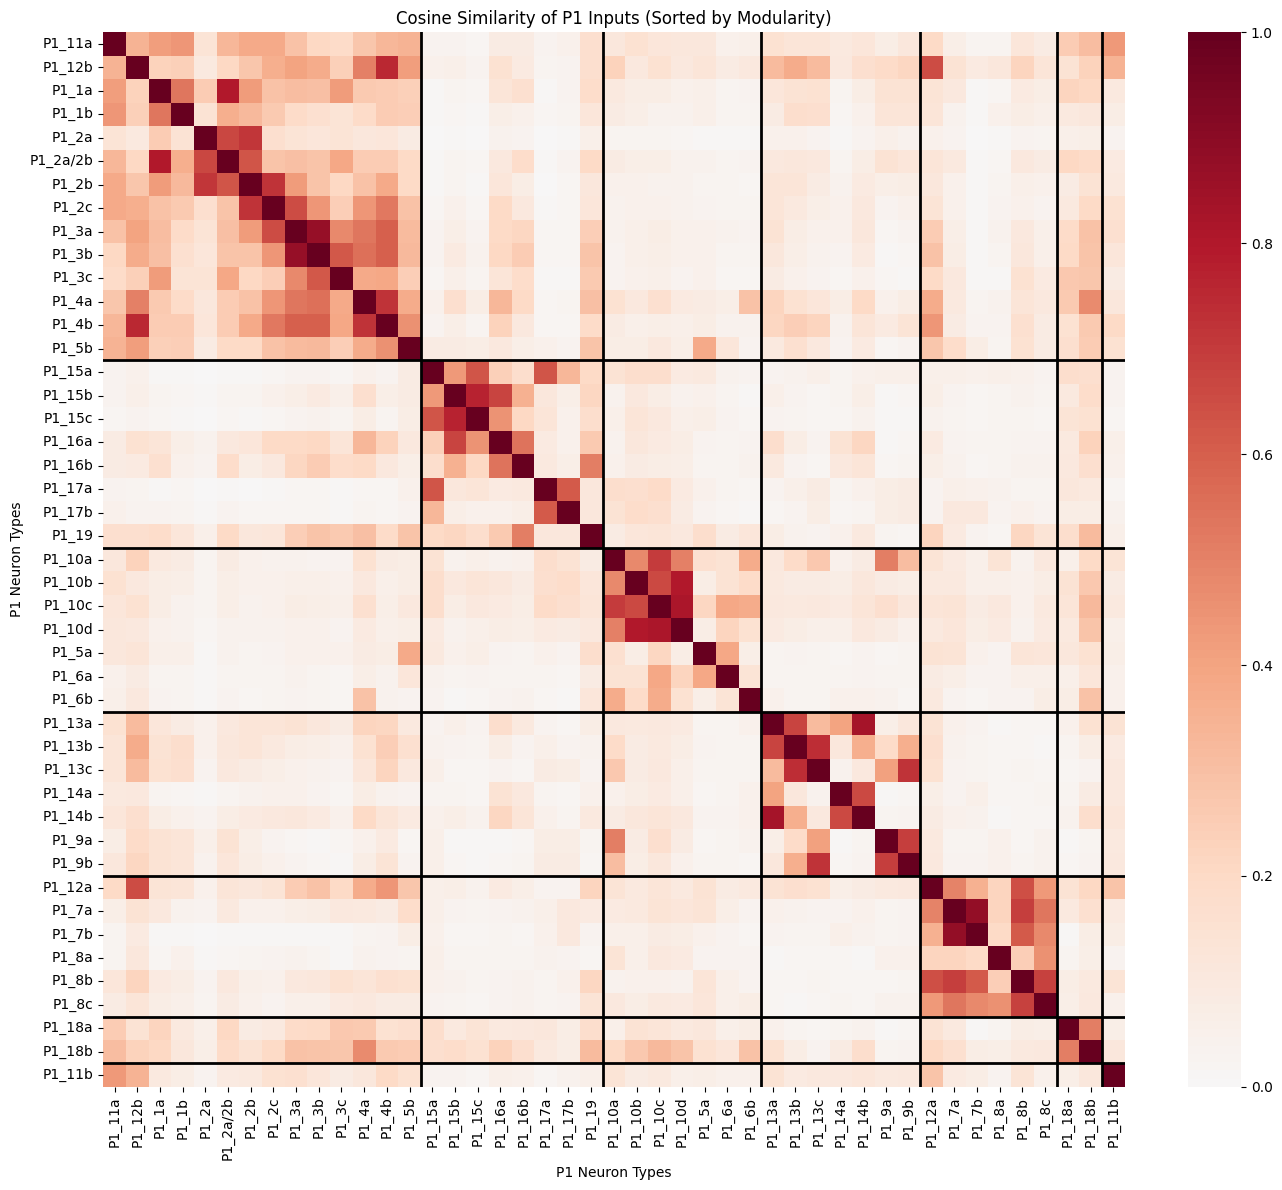

In [57]:
inputs = conn_matrix[conn_matrix['body_post'].isin(P1_bodyIds)]
# map body_post to cell type using type in neuron[0
inputs = inputs.merge(neurons[0][['bodyId', 'type']], left_on='body_post', right_on='bodyId', how='left')
inputs = inputs.rename(columns={'type': 'post_type'})
# map body_pre to cell type using type in neuron[0]
inputs = inputs.merge(neurons[0][['bodyId', 'type']], left_on='body_pre', right_on='bodyId', how='left')
inputs = inputs.rename(columns={'type': 'pre_type'})
inputs = inputs.groupby(['post_type','pre_type'])['normalized_weight'].sum()
inputs_matrix = inputs.unstack(fill_value=0)

# calculate cosine similarity
similarity_matrix = cosine_similarity(inputs_matrix)
similarity_df = pd.DataFrame(similarity_matrix, index=inputs_matrix.index, columns=inputs_matrix.index)

# perform community detection
# Create a graph from the similarity matrix
G = nx.from_pandas_adjacency(similarity_df)

# Find communities using greedy modularity
communities = greedy_modularity_communities(G, weight='weight')

# Map types to communities
type_to_comm = {}
for i, comm in enumerate(communities):
    for node in comm:
        type_to_comm[node] = i

# Sort indices by community ID
sorted_rows = sorted(similarity_df.index, key=lambda x: (type_to_comm.get(x, -1), x))
sorted_cols = sorted(similarity_df.columns, key=lambda x: (type_to_comm.get(x, -1), x))

# Reorder similarity matrix
sorted_similarity = similarity_df.loc[sorted_rows, sorted_cols]

# plot the data with separators
plt.figure(figsize=(14, 12))
sns.heatmap(sorted_similarity, cmap='RdBu_r', center=0, xticklabels=True, yticklabels=True, vmin=0, vmax=1)

# Draw community boundaries
for i in range(len(sorted_rows)-1):
    if type_to_comm.get(sorted_rows[i]) != type_to_comm.get(sorted_rows[i+1]):
        plt.axhline(i+1, color='black', linewidth=2, linestyle='-')

for i in range(len(sorted_cols)-1):
    if type_to_comm.get(sorted_cols[i]) != type_to_comm.get(sorted_cols[i+1]):
        plt.axvline(i+1, color='black', linewidth=2, linestyle='-')

plt.xlabel('P1 Neuron Types')
plt.ylabel('P1 Neuron Types')
plt.title('Cosine Similarity of P1 Inputs (Sorted by Modularity)')
plt.tight_layout()
plt.show()

In [58]:
# keep only those bodyIds in first, second, third order lists
first_order_P1 = [(bodyId, weight) for bodyId, weight in first_order_bodyIds if bodyId in P1_bodyIds]
second_order_P1 = [(bodyId, weight) for bodyId, weight in second_order_bodyIds if bodyId in P1_bodyIds]
third_order_P1 = [(bodyId, weight) for bodyId, weight in third_order_bodyIds if bodyId in P1_bodyIds]   

In [59]:
# convert to DataFrame for better visualization
if len(first_order_P1) > 0:
    first_order_P1_df = pd.DataFrame(first_order_P1, columns=['bodyId', 'normalized_weight'])
else:
    first_order_P1_df = None

if len(second_order_P1) > 0:
    second_order_P1_df = pd.DataFrame(second_order_P1, columns=['bodyId', 'normalized_weight'])
else:
    second_order_P1_df = None

if len(third_order_P1) > 0:
    third_order_P1_df = pd.DataFrame(third_order_P1, columns=['bodyId', 'normalized_weight'])
else:
    third_order_P1_df = None

# for each of them get the neuron type
if first_order_P1_df is not None:
    first_order_P1_df = first_order_P1_df.merge(
        neurons[0][['bodyId', 'type']], 
        on='bodyId', 
        how='left'
    )

if second_order_P1_df is not None:
    second_order_P1_df = second_order_P1_df.merge(
        neurons[0][['bodyId', 'type']], 
        on='bodyId', 
        how='left'
    )

if third_order_P1_df is not None:
    third_order_P1_df = third_order_P1_df.merge(
        neurons[0][['bodyId', 'type']], 
        on='bodyId', 
        how='left'
    )


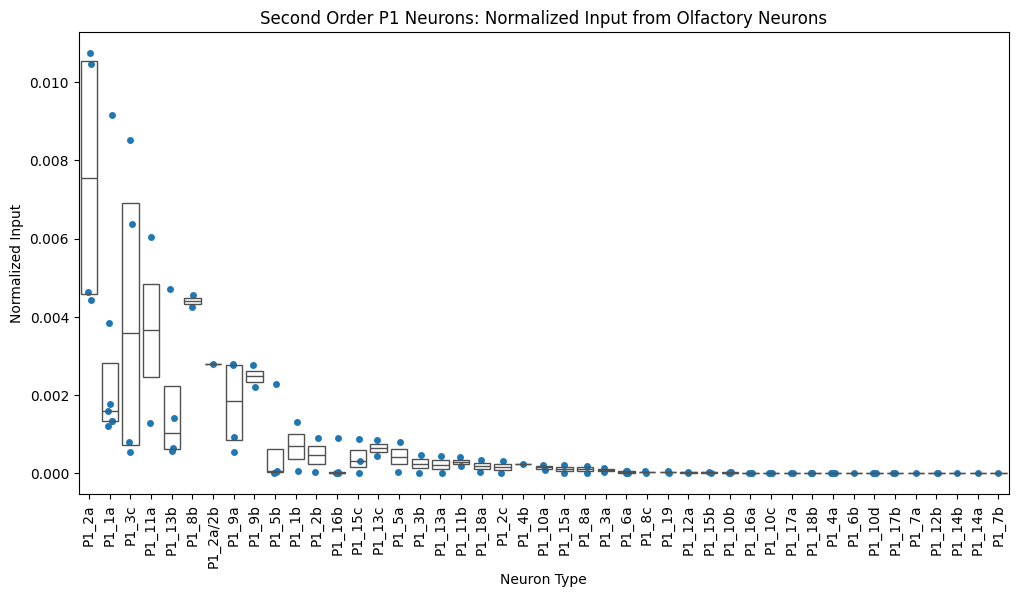

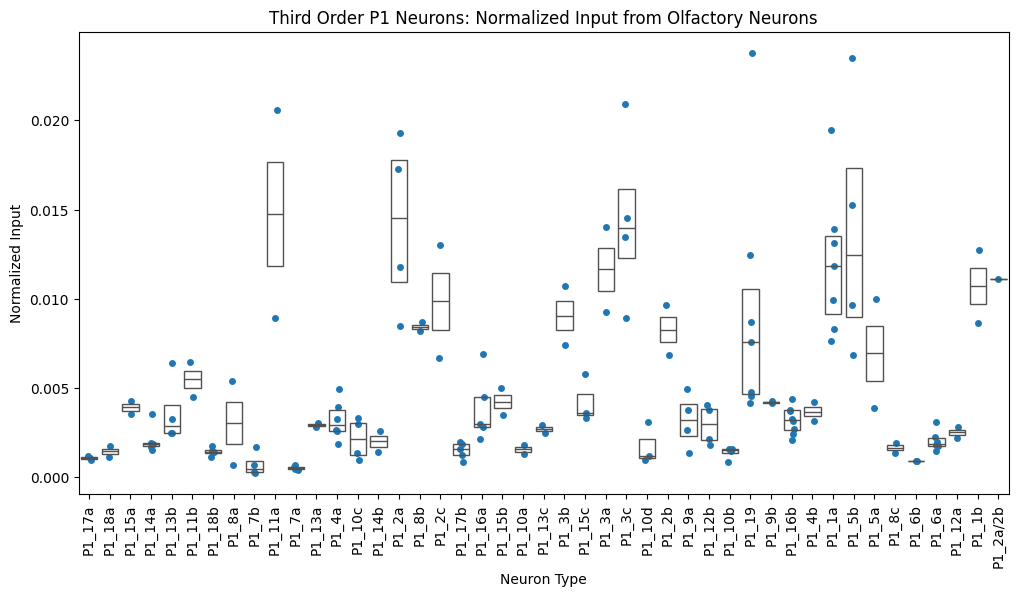

In [60]:
#  plot of normalized input vs neuron type for first order P1 neurons
if first_order_P1_df is not None:
    plt.figure(figsize=(12, 6))
    sns.stripplot(data=first_order_P1_df, x='type', y='normalized_weight', jitter=True)
    sns.boxplot(data=first_order_P1_df, x='type', y='normalized_weight', showcaps=False, boxprops={'facecolor':'None'}, showfliers=False, whiskerprops={'linewidth':0}, zorder=10)
    plt.xticks(rotation=90)
    plt.title('First Order P1 Neurons: Normalized Input from Olfactory Neurons')
    plt.ylabel('Normalized Input')
    plt.xlabel('Neuron Type')
    plt.show()

if second_order_P1_df is not None:
    plt.figure(figsize=(12, 6))
    sns.stripplot(data=second_order_P1_df, x='type', y='normalized_weight', jitter=True)
    sns.boxplot(data=second_order_P1_df, x='type', y='normalized_weight', showcaps=False, boxprops={'facecolor':'None'}, showfliers=False, whiskerprops={'linewidth':0}, zorder=10)
    plt.xticks(rotation=90)
    plt.title('Second Order P1 Neurons: Normalized Input from Olfactory Neurons')
    plt.ylabel('Normalized Input')
    plt.xlabel('Neuron Type')
    plt.show()

if third_order_P1_df is not None:
    plt.figure(figsize=(12, 6))
    sns.stripplot(data=third_order_P1_df, x='type', y='normalized_weight', jitter=True)
    sns.boxplot(data=third_order_P1_df, x='type', y='normalized_weight', showcaps=False, boxprops={'facecolor':'None'}, showfliers=False, whiskerprops={'linewidth':0}, zorder=10)
    plt.xticks(rotation=90)
    plt.title('Third Order P1 Neurons: Normalized Input from Olfactory Neurons')
    plt.ylabel('Normalized Input')
    plt.xlabel('Neuron Type')
    plt.show()

In [ ]:
# get the bodyId for getting the connectivity matrix
bodyId = second_order_P1_df['bodyId'].values
# get the indices of these bodyIds
post_indices = [bodyId_to_idx[bid] for bid in BodyId if bid in bodyId_to_idx]

In [18]:
conn_matrix

,body_pre,body_post,weight,total_weight,normalized_weight
0,10352,10351,2591,45229,0.057286
1,13612,16076,2385,37118,0.064255
2,10663,10051,2248,58038,0.038733
3,10289,10611,2230,54910,0.040612
4,10893,10066,1929,77367,0.024933
...,...,...,...,...,...
151871789,54588,878777930,1,1,1.000000
151871790,54588,864658553,1,1,1.000000
151871791,54588,864364339,1,4,0.250000
151871792,54588,862568438,1,3,0.333333


In [32]:
conn_matrix

,body_pre,body_post,weight
0,10352,10351,2591
1,13612,16076,2385
2,10663,10051,2248
3,10289,10611,2230
4,10893,10066,1929
...,...,...,...
151871789,54588,878777930,1
151871790,54588,864658553,1
151871791,54588,864364339,1
151871792,54588,862568438,1


In [9]:
# ==============================================================================
# First Order Connectivity: Full Method
# ==============================================================================

def create_first_order_connection_matrix(pre_neurons, post_neurons):
    filtered_connections = conn_matrix[
        conn_matrix['body_pre'].isin(pre_neurons) & 
        conn_matrix['body_post'].isin(post_neurons)
    ]
    grouped = filtered_connections.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    connection_matrix_df = grouped.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    connection_matrix_df = connection_matrix_df.reindex(index=pre_neurons, columns=post_neurons, fill_value=0)
    return connection_matrix_df.values

# ==============================================================================
# Second Order Connectivity: Full Method via Intermediate Neurons
# ==============================================================================

def create_second_order_connection_matrix(pre_neurons, post_neurons):
    # Filter connections for valid synapse strengths
    valid_connections = conn_matrix.copy()
    valid_connections = valid_connections[~np.isnan(valid_connections['normalized_weight'])]
    valid_connections = valid_connections[(valid_connections['normalized_weight'] > 0) & (valid_connections['normalized_weight'] < 1)]
    
    # Determine downstream (from pre_neurons) and upstream (to post_neurons) neurons
    downstream = valid_connections[valid_connections['body_pre'].isin(pre_neurons)]
    downstream_neurons = downstream['body_post'].unique()

    upstream = valid_connections[valid_connections['body_post'].isin(post_neurons)]
    upstream_neurons = upstream['body_pre'].unique()
    # Common intermediate neurons between the two groups
    common_neurons = np.intersect1d(downstream_neurons, upstream_neurons)

    # remove any neurons in common_neurons that are also in pre_neurons or post_neurons to prevent cycles
    common_neurons = common_neurons[~np.isin(common_neurons, np.concatenate([pre_neurons, post_neurons]))]
    
    # Build pre->common matrix
    pre_common_connections = valid_connections[
        valid_connections['body_pre'].isin(pre_neurons) & 
        valid_connections['body_post'].isin(common_neurons)
    ]
    pre_common_group = pre_common_connections.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    pre_common_df = pre_common_group.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    pre_common_df = pre_common_df.reindex(index=pre_neurons, columns=common_neurons, fill_value=0)
    pre_common_matrix = pre_common_df.values

    # Build common->post matrix
    common_post_connections = valid_connections[
        valid_connections['body_pre'].isin(common_neurons) &
        valid_connections['body_post'].isin(post_neurons)
    ]
    common_post_group = common_post_connections.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    common_post_df = common_post_group.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    common_post_df = common_post_df.reindex(index=common_neurons, columns=post_neurons, fill_value=0)
    common_post_matrix = common_post_df.values

    # Multiply the matrices to get second order connectivity and take geometric mean
    second_order = np.dot(pre_common_matrix, common_post_matrix)
    second_order = np.power(second_order, 1/2)
    return second_order, common_neurons, pre_common_matrix, common_post_matrix


# ==============================================================================
# Third Order Connectivity: Full Method via Intermediate Neurons
# ==============================================================================

def create_third_order_connection_matrix(pre_neurons, post_neurons):
    """
    Compute a third order connection matrix between pre_neurons and post_neurons.
    Here a third order connection is defined as a path:
      pre_neuron -> intermediate1 -> intermediate2 -> post_neuron,
    where intermediate1 and intermediate2 are chosen by:
      - I1: all neurons downstream of pre_neurons
      - I2: all neurons upstream of post_neurons
    Only direct connections are considered at each step.
    
    The final third order connectivity is computed as the product of three matrices,
    with a cube root taken to (optionally) keep values in a comparable range.
    """
    # Filter valid connections based on synapse strength
    valid_connections = conn_matrix.copy()
    valid_connections = valid_connections[~np.isnan(valid_connections['normalized_weight'])]
    valid_connections = valid_connections[(valid_connections['normalized_weight'] > 0) & 
                                          (valid_connections['normalized_weight'] < 1)]

    # Determine intermediate sets:
    # I1: neurons that appear as targets from pre_neurons
    pre_downstream = valid_connections[valid_connections['body_pre'].isin(pre_neurons)]
    I1 = np.unique(pre_downstream['body_post'])
    # remove any neurons in I1 that are also in pre_neurons or post_neurons to prevent cycles
    I1 = I1[~np.isin(I1, np.concatenate([pre_neurons, post_neurons]))]

    # I2: neurons that appear as sources to post_neurons
    post_upstream = valid_connections[valid_connections['body_post'].isin(post_neurons)]
    I2 = np.unique(post_upstream['body_pre'])
    # remove any neurons in I2 that are also in pre_neurons or post_neurons to prevent cycles
    I2 = I2[~np.isin(I2, np.concatenate([pre_neurons, post_neurons]))]

    # remove any neurons in I2 that are also in I1 to prevent cycles
    I2 = I2[~np.isin(I2, I1)] # I2: neurons that appear as sources to post_neurons

    
    # --- Build pre -> I1 matrix ---
    pre_I1 = valid_connections[
        valid_connections['body_pre'].isin(pre_neurons) &
        valid_connections['body_post'].isin(I1)
    ]
    pre_I1_group = pre_I1.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    pre_I1_df = pre_I1_group.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    pre_I1_df = pre_I1_df.reindex(index=pre_neurons, columns=I1, fill_value=0)
    pre_I1_matrix = pre_I1_df.values

    # --- Build I1 -> I2 matrix ---
    I1_I2 = valid_connections[
        valid_connections['body_pre'].isin(I1) &
        valid_connections['body_post'].isin(I2)
    ]
    I1_I2_group = I1_I2.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    I1_I2_df = I1_I2_group.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    I1_I2_df = I1_I2_df.reindex(index=I1, columns=I2, fill_value=0)
    I1_I2_matrix = I1_I2_df.values

    # --- Build I2 -> post matrix ---
    I2_post = valid_connections[
        valid_connections['body_pre'].isin(I2) &
        valid_connections['body_post'].isin(post_neurons)
    ]
    I2_post_group = I2_post.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    I2_post_df = I2_post_group.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    I2_post_df = I2_post_df.reindex(index=I2, columns=post_neurons, fill_value=0)
    I2_post_matrix = I2_post_df.values

    # --- Multiply the three matrices ---
    third_order = np.dot(np.dot(pre_I1_matrix, I1_I2_matrix), I2_post_matrix)
    # Apply the cube root (geometric mean) to temper large values
    third_order = np.power(third_order, 1/3)
    
    return third_order, I1, I2, pre_I1_matrix, I1_I2_matrix, I2_post_matrix

# ==============================================================================
# Fourth Order Connectivity: Full Method via Intermediate Neurons
# ==============================================================================

def create_fourth_order_connection_matrix(pre_neurons, post_neurons):
    """
    Compute a fourth order connection matrix between pre_neurons and post_neurons.
    Here a fourth order connection is defined as a path:
      pre_neuron -> I1 -> I2 -> I3 -> post_neuron,
    where intermediate layers are chosen by:
      - I1: all neurons downstream of pre_neurons
      - I3: all neurons upstream of post_neurons
      - I2: neurons connecting I1 to I3
    Only direct connections are considered at each step.
    
    The final fourth order connectivity is computed as the product of four matrices,
    with a fourth root taken to keep values in a comparable range.
    """
    # Filter valid connections based on synapse strength
    valid_connections = conn_matrix.copy()
    valid_connections = valid_connections[~np.isnan(valid_connections['normalized_weight'])]
    valid_connections = valid_connections[(valid_connections['normalized_weight'] > 0) & 
                                          (valid_connections['normalized_weight'] < 1)]

    # Determine intermediate sets:
    # I1: neurons that appear as targets from pre_neurons
    pre_downstream = valid_connections[valid_connections['body_pre'].isin(pre_neurons)]
    I1 = np.unique(pre_downstream['body_post'])
    # remove any neurons in I1 that are also in pre_neurons or post_neurons to prevent cycles
    I1 = I1[~np.isin(I1, np.concatenate([pre_neurons, post_neurons]))]

    # I3: neurons that appear as sources to post_neurons
    post_upstream = valid_connections[valid_connections['body_post'].isin(post_neurons)]
    I3 = np.unique(post_upstream['body_pre'])
    # remove any neurons in I3 that are also in pre_neurons or post_neurons to prevent cycles
    I3 = I3[~np.isin(I3, np.concatenate([pre_neurons, post_neurons]))]
    # remove any neurons in I3 that are also in I1 to prevent cycles
    I3 = I3[~np.isin(I3, I1)]

    # I2: neurons connecting I1 to I3
    I1_downstream = valid_connections[valid_connections['body_pre'].isin(I1)]
    I2_from_I1 = np.unique(I1_downstream['body_post'])
    I3_upstream = valid_connections[valid_connections['body_post'].isin(I3)]
    I2_to_I3 = np.unique(I3_upstream['body_pre'])
    I2 = np.intersect1d(I2_from_I1, I2_to_I3)
    # remove any neurons in I2 that are in pre_neurons, post_neurons, I1, or I3
    I2 = I2[~np.isin(I2, np.concatenate([pre_neurons, post_neurons, I1, I3]))]
    
    # --- Build pre -> I1 matrix ---
    pre_I1 = valid_connections[
        valid_connections['body_pre'].isin(pre_neurons) &
        valid_connections['body_post'].isin(I1)
    ]
    pre_I1_group = pre_I1.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    pre_I1_df = pre_I1_group.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    pre_I1_df = pre_I1_df.reindex(index=pre_neurons, columns=I1, fill_value=0)
    pre_I1_matrix = pre_I1_df.values

    # --- Build I1 -> I2 matrix ---
    I1_I2 = valid_connections[
        valid_connections['body_pre'].isin(I1) &
        valid_connections['body_post'].isin(I2)
    ]
    I1_I2_group = I1_I2.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    I1_I2_df = I1_I2_group.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    I1_I2_df = I1_I2_df.reindex(index=I1, columns=I2, fill_value=0)
    I1_I2_matrix = I1_I2_df.values

    # --- Build I2 -> I3 matrix ---
    I2_I3 = valid_connections[
        valid_connections['body_pre'].isin(I2) &
        valid_connections['body_post'].isin(I3)
    ]
    I2_I3_group = I2_I3.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    I2_I3_df = I2_I3_group.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    I2_I3_df = I2_I3_df.reindex(index=I2, columns=I3, fill_value=0)
    I2_I3_matrix = I2_I3_df.values

    # --- Build I3 -> post matrix ---
    I3_post = valid_connections[
        valid_connections['body_pre'].isin(I3) &
        valid_connections['body_post'].isin(post_neurons)
    ]
    I3_post_group = I3_post.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    I3_post_df = I3_post_group.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    I3_post_df = I3_post_df.reindex(index=I3, columns=post_neurons, fill_value=0)
    I3_post_matrix = I3_post_df.values

    # --- Multiply the four matrices ---
    fourth_order = np.dot(np.dot(np.dot(pre_I1_matrix, I1_I2_matrix), I2_I3_matrix), I3_post_matrix)
    # Apply the fourth root (geometric mean) to temper large values
    fourth_order = np.power(fourth_order, 1/4)
    
    return fourth_order, I1, I2, I3, pre_I1_matrix, I1_I2_matrix, I2_I3_matrix, I3_post_matrix

# ==============================================================================
# Fifth Order Connectivity: Full Method via Intermediate Neurons
# ==============================================================================

def create_fifth_order_connection_matrix(pre_neurons, post_neurons):
    """
    Compute a fifth order connection matrix between pre_neurons and post_neurons.
    Here a fifth order connection is defined as a path:
      pre_neuron -> I1 -> I2 -> I3 -> I4 -> post_neuron,
    where intermediate layers are chosen by:
      - I1: all neurons downstream of pre_neurons
      - I4: all neurons upstream of post_neurons
      - I2, I3: neurons forming intermediate connections
    Only direct connections are considered at each step.
    
    The final fifth order connectivity is computed as the product of five matrices,
    with a fifth root taken to keep values in a comparable range.
    """
    # Filter valid connections based on synapse strength
    valid_connections = conn_matrix.copy()
    valid_connections = valid_connections[~np.isnan(valid_connections['normalized_weight'])]
    valid_connections = valid_connections[(valid_connections['normalized_weight'] > 0) & 
                                          (valid_connections['normalized_weight'] < 1)]

    # Determine intermediate sets:
    # I1: neurons that appear as targets from pre_neurons
    pre_downstream = valid_connections[valid_connections['body_pre'].isin(pre_neurons)]
    I1 = np.unique(pre_downstream['body_post'])
    # remove any neurons in I1 that are also in pre_neurons or post_neurons to prevent cycles
    I1 = I1[~np.isin(I1, np.concatenate([pre_neurons, post_neurons]))]

    # I4: neurons that appear as sources to post_neurons
    post_upstream = valid_connections[valid_connections['body_post'].isin(post_neurons)]
    I4 = np.unique(post_upstream['body_pre'])
    # remove any neurons in I4 that are also in pre_neurons or post_neurons to prevent cycles
    I4 = I4[~np.isin(I4, np.concatenate([pre_neurons, post_neurons]))]
    # remove any neurons in I4 that are also in I1 to prevent cycles
    I4 = I4[~np.isin(I4, I1)]

    # I3: neurons connecting to I4
    I4_upstream = valid_connections[valid_connections['body_post'].isin(I4)]
    I3_candidates = np.unique(I4_upstream['body_pre'])
    I3_candidates = I3_candidates[~np.isin(I3_candidates, np.concatenate([pre_neurons, post_neurons, I1, I4]))]
    
    # I2: neurons connecting I1 to I3
    I1_downstream = valid_connections[valid_connections['body_pre'].isin(I1)]
    I2_from_I1 = np.unique(I1_downstream['body_post'])
    I3_upstream = valid_connections[valid_connections['body_post'].isin(I3_candidates)]
    I2_to_I3 = np.unique(I3_upstream['body_pre'])
    I2 = np.intersect1d(I2_from_I1, I2_to_I3)
    # remove any neurons in I2 that are in pre_neurons, post_neurons, I1, I4, or I3_candidates
    I2 = I2[~np.isin(I2, np.concatenate([pre_neurons, post_neurons, I1, I4, I3_candidates]))]
    
    # I3: filter I3_candidates to only include neurons connected from I2
    I2_downstream = valid_connections[valid_connections['body_pre'].isin(I2)]
    I3_from_I2 = np.unique(I2_downstream['body_post'])
    I3 = np.intersect1d(I3_candidates, I3_from_I2)
    
    # --- Build pre -> I1 matrix ---
    pre_I1 = valid_connections[
        valid_connections['body_pre'].isin(pre_neurons) &
        valid_connections['body_post'].isin(I1)
    ]
    pre_I1_group = pre_I1.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    pre_I1_df = pre_I1_group.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    pre_I1_df = pre_I1_df.reindex(index=pre_neurons, columns=I1, fill_value=0)
    pre_I1_matrix = pre_I1_df.values

    # --- Build I1 -> I2 matrix ---
    I1_I2 = valid_connections[
        valid_connections['body_pre'].isin(I1) &
        valid_connections['body_post'].isin(I2)
    ]
    I1_I2_group = I1_I2.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    I1_I2_df = I1_I2_group.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    I1_I2_df = I1_I2_df.reindex(index=I1, columns=I2, fill_value=0)
    I1_I2_matrix = I1_I2_df.values

    # --- Build I2 -> I3 matrix ---
    I2_I3 = valid_connections[
        valid_connections['body_pre'].isin(I2) &
        valid_connections['body_post'].isin(I3)
    ]
    I2_I3_group = I2_I3.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    I2_I3_df = I2_I3_group.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    I2_I3_df = I2_I3_df.reindex(index=I2, columns=I3, fill_value=0)
    I2_I3_matrix = I2_I3_df.values

    # --- Build I3 -> I4 matrix ---
    I3_I4 = valid_connections[
        valid_connections['body_pre'].isin(I3) &
        valid_connections['body_post'].isin(I4)
    ]
    I3_I4_group = I3_I4.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    I3_I4_df = I3_I4_group.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    I3_I4_df = I3_I4_df.reindex(index=I3, columns=I4, fill_value=0)
    I3_I4_matrix = I3_I4_df.values

    # --- Build I4 -> post matrix ---
    I4_post = valid_connections[
        valid_connections['body_pre'].isin(I4) &
        valid_connections['body_post'].isin(post_neurons)
    ]
    I4_post_group = I4_post.groupby(['body_pre', 'body_post'])['normalized_weight'].sum().reset_index()
    I4_post_df = I4_post_group.pivot(index='body_pre', columns='body_post', values='normalized_weight').fillna(0)
    I4_post_df = I4_post_df.reindex(index=I4, columns=post_neurons, fill_value=0)
    I4_post_matrix = I4_post_df.values

    # --- Multiply the five matrices ---
    fifth_order = np.dot(np.dot(np.dot(np.dot(pre_I1_matrix, I1_I2_matrix), I2_I3_matrix), I3_I4_matrix), I4_post_matrix)
    # Apply the fifth root (geometric mean) to temper large values
    fifth_order = np.power(fifth_order, 1/5)
    
    return fifth_order, I1, I2, I3, I4, pre_I1_matrix, I1_I2_matrix, I2_I3_matrix, I3_I4_matrix, I4_post_matrix

def map_to_celltypes(bodyIds, neurons_df):
    """
    Map a list of bodyIds to their corresponding cell types using the neurons DataFrame.
    
    Parameters:
    - bodyIds: List or array of bodyIds to map.
    - neurons_df: DataFrame containing neuron information with 'bodyId' and 'type' columns.

    Returns:
    - A DataFrame mapping each bodyId to its corresponding cell type.
    """
    type_map = neurons_df[neurons_df['bodyId'].isin(bodyIds)][['bodyId', 'type']]
    # map bodyIds to types
    mapped_types = pd.DataFrame(bodyIds, columns=['bodyId']).merge(type_map, on='bodyId', how='left')
    # replace None with ''
    mapped_types = mapped_types.fillna('')
    return mapped_types['type'].values

In [24]:
neurons[0][neurons[0]['bodyId'].isin(pre_neurons)]

,bodyId,instance,type,pre,post,downstream,upstream,size,status,statusLabel,...,assignedOlHex2,group,supertype,mancBodyid,totalNtPredictions,predictedNt,mancGroup,serialMotif,inputRois,outputRois
9,10013,MBON01(y5B'2a)_R,MBON01,2616,25357,23601,25357,4.723838e+09,Traced,Roughly traced,...,NaN,10013.0,None,NaN,2616.0,glutamate,NaN,None,"[CRE(L), CRE(R), CentralBrain, CentralBrain-un...","[CRE(L), CRE(R), CentralBrain, CentralBrain-un..."
66,10079,MBON06(B1>a)_R,MBON06,1406,15258,9692,15258,2.580791e+09,Traced,Roughly traced,...,NaN,10079.0,None,NaN,1406.0,glutamate,NaN,None,"[CRE(L), CentralBrain, CentralBrain-unspecifie...","[CRE(L), CentralBrain, CentralBrain-unspecifie..."
246,10267,MBON14(a3)_R,MBON14,565,5918,4357,5918,1.229307e+09,Traced,Roughly traced,...,NaN,10267.0,10267,NaN,565.0,acetylcholine,NaN,None,"[CentralBrain, CentralBrain-unspecified, PRW, ...","[CentralBrain, SIP(R), SLP(R), SMP(R), a'L(R),..."
459,10495,MBON05(y4>y1y2)_R,MBON05,2000,23812,14684,23812,3.746016e+09,Traced,Roughly traced,...,NaN,10495.0,None,NaN,2000.0,unclear,NaN,None,"[BU(R), CRE(L), CentralBrain, CentralBrain-uns...","[BU(R), CRE(L), CentralBrain, CentralBrain-uns..."
558,10599,MBON35(y2)_L,MBON35,2221,26172,19643,26172,2.859859e+09,Traced,Roughly traced,...,NaN,10599.0,None,NaN,2221.0,acetylcholine,NaN,None,"[AL(L), AOTU(L), CRE(L), CentralBrain, Central...","[AOTU(L), CRE(L), CentralBrain, CentralBrain-u..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143513,540383,MBON10(B'1)_R,MBON10,190,714,1415,714,3.196596e+08,Traced,Roughly traced,...,NaN,39608.0,27954,NaN,190.0,gaba,NaN,None,"[CRE(R), CentralBrain, CentralBrain-unspecifie...","[CRE(R), CentralBrain, LAL(R), SIP(R), SMP(R),..."
147912,556300,MBON25-like(y1y2)_R,MBON25-like,368,695,2733,695,3.742415e+08,Traced,Prelim Roughly traced,...,NaN,110448.0,25975,NaN,368.0,glutamate,NaN,None,"[CRE(L), CRE(R), CentralBrain, CentralBrain-un...","[CRE(L), CRE(R), CentralBrain, CentralBrain-un..."
148238,558665,MBON10(B'1)_R,MBON10,157,832,1153,832,2.643490e+08,Traced,Roughly traced,...,NaN,39608.0,27954,NaN,157.0,gaba,NaN,None,"[CRE(R), CentralBrain, CentralBrain-unspecifie...","[CRE(R), CentralBrain, SIP(R), SMP(R), a'L(R),..."
148591,562782,MBON16(a'3ap)_R,MBON16,625,2729,5599,2729,7.552894e+08,Traced,Roughly traced,...,NaN,520186.0,11777,NaN,625.0,acetylcholine,NaN,None,"[CentralBrain, CentralBrain-unspecified, LH(L)...","[CentralBrain, CentralBrain-unspecified, LH(L)..."


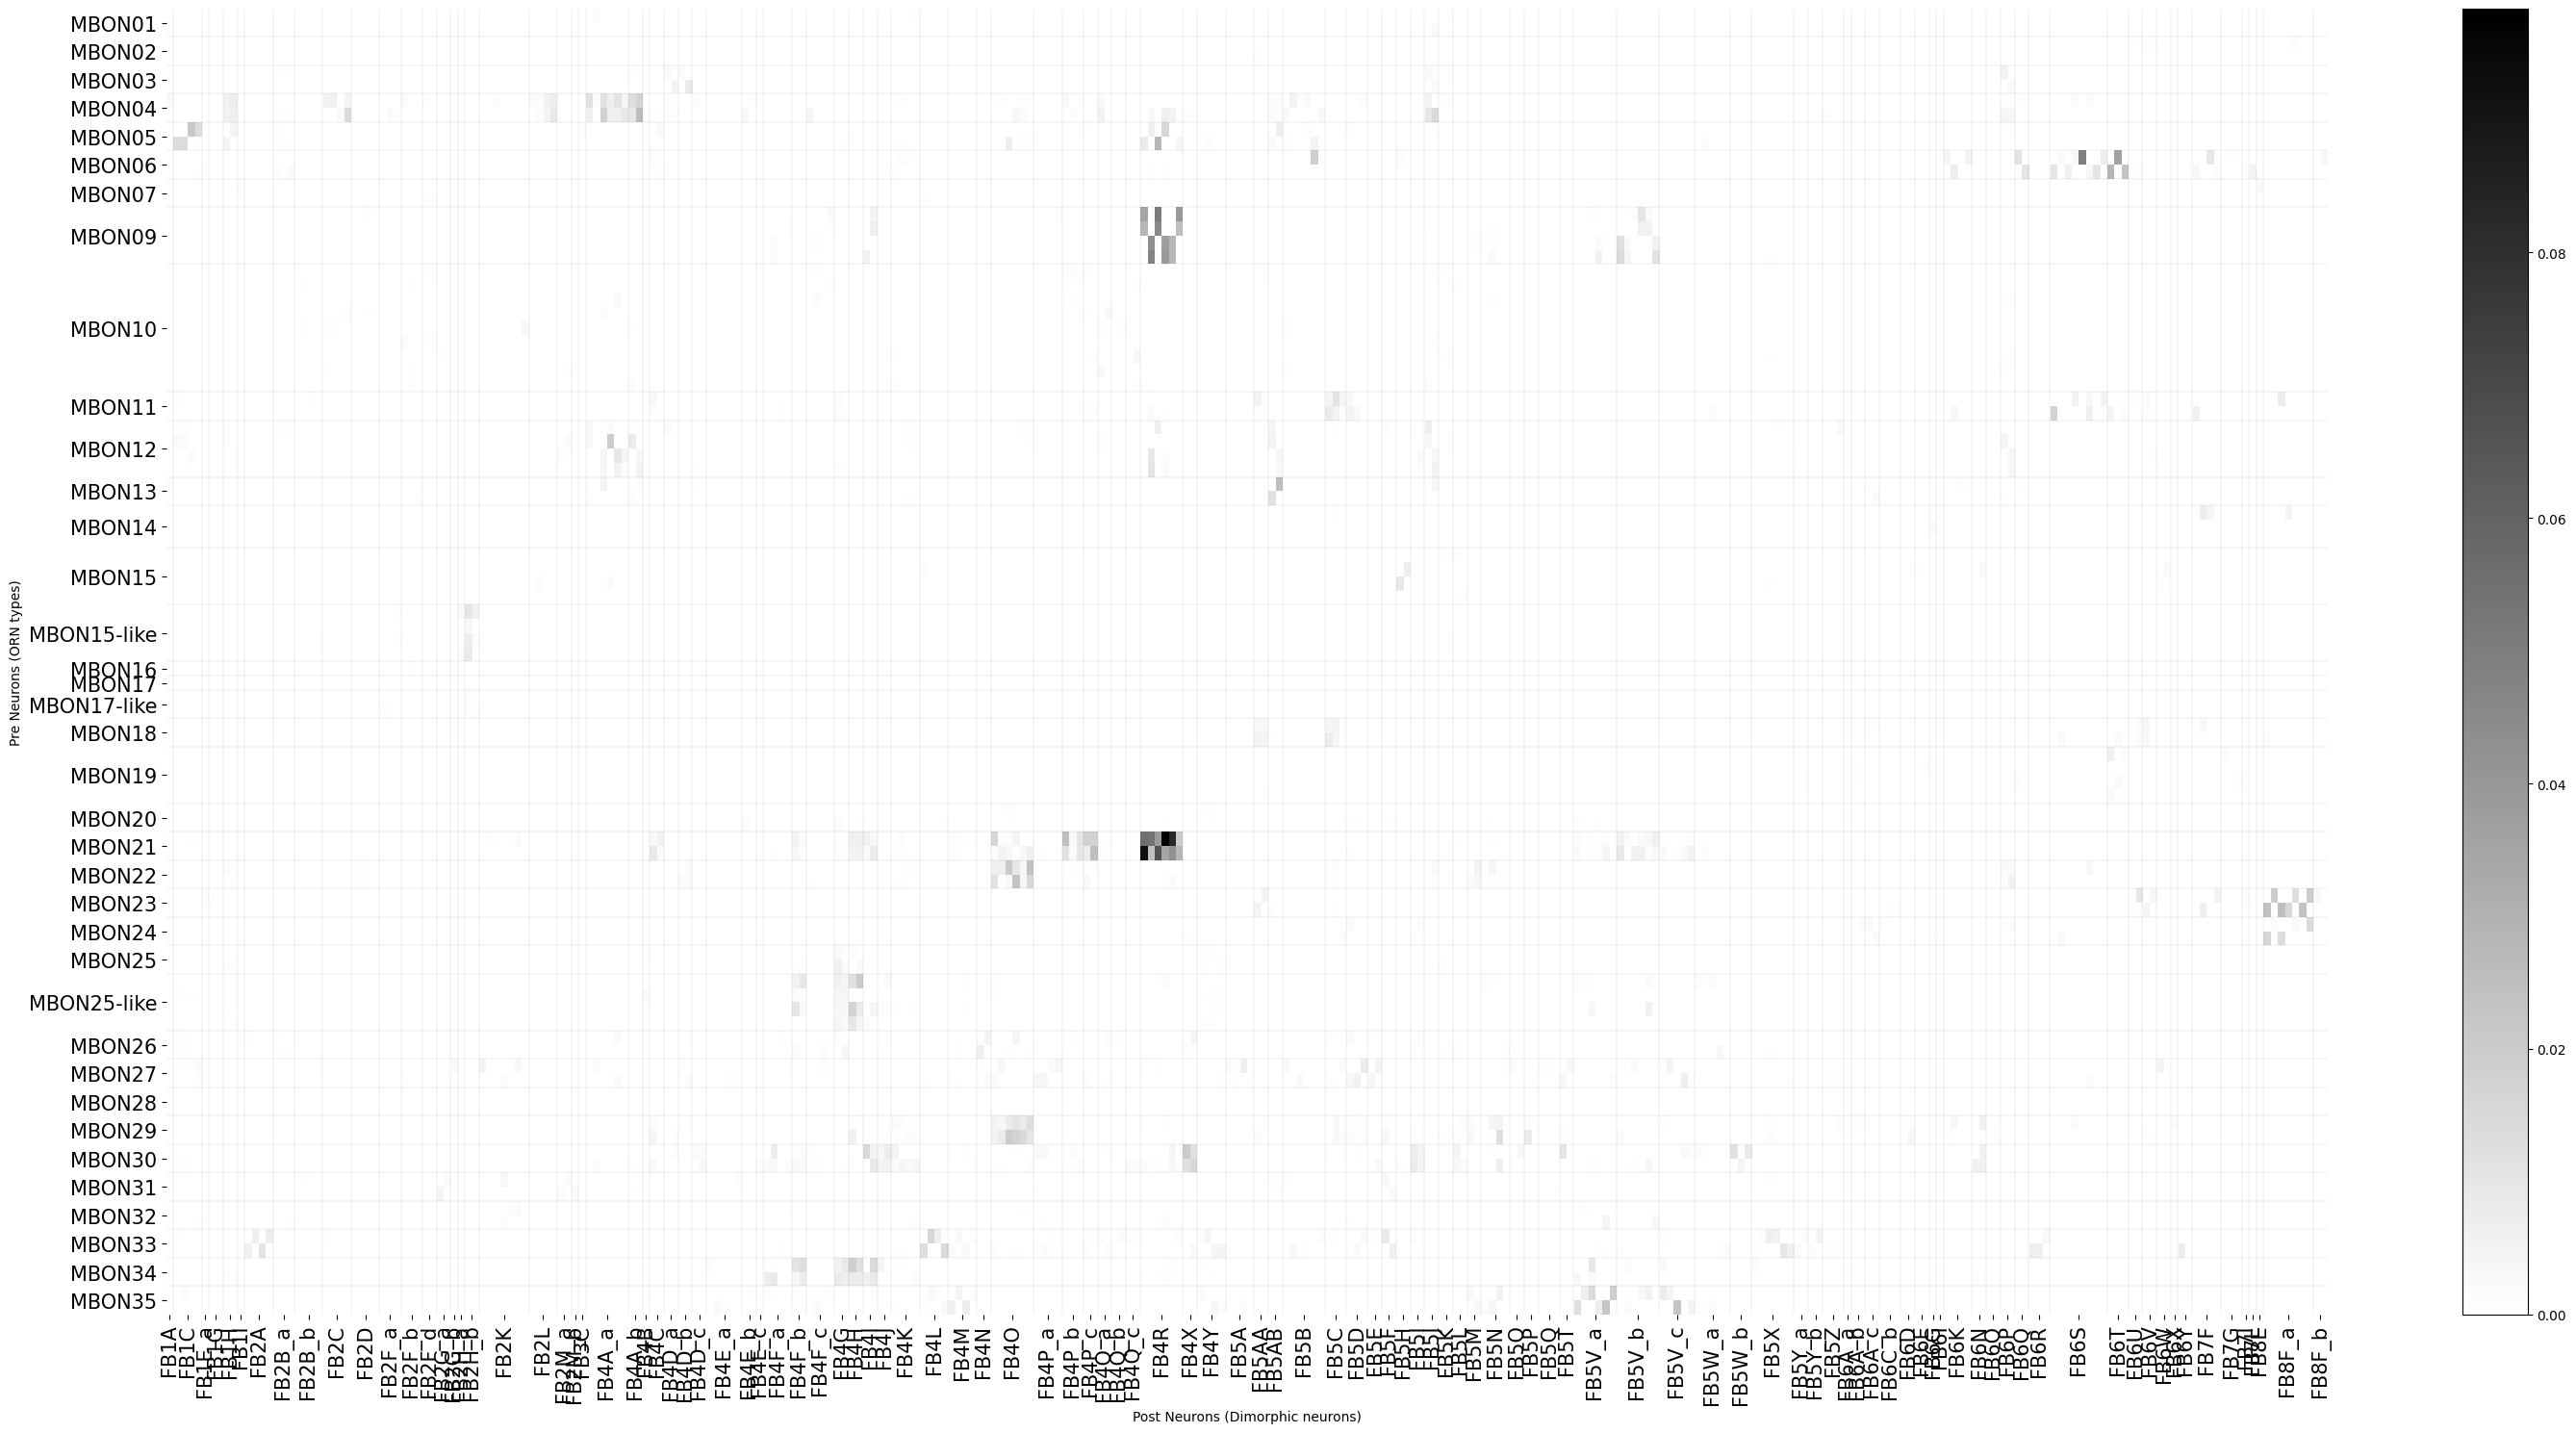

/Users/neurorishika/Projects/Rockefeller/Ruta/fly-connectomics/.venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/neurorishika/Projects/Rockefeller/Ruta/fly-connectomics/.venv/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1200x1000 with 0 Axes>

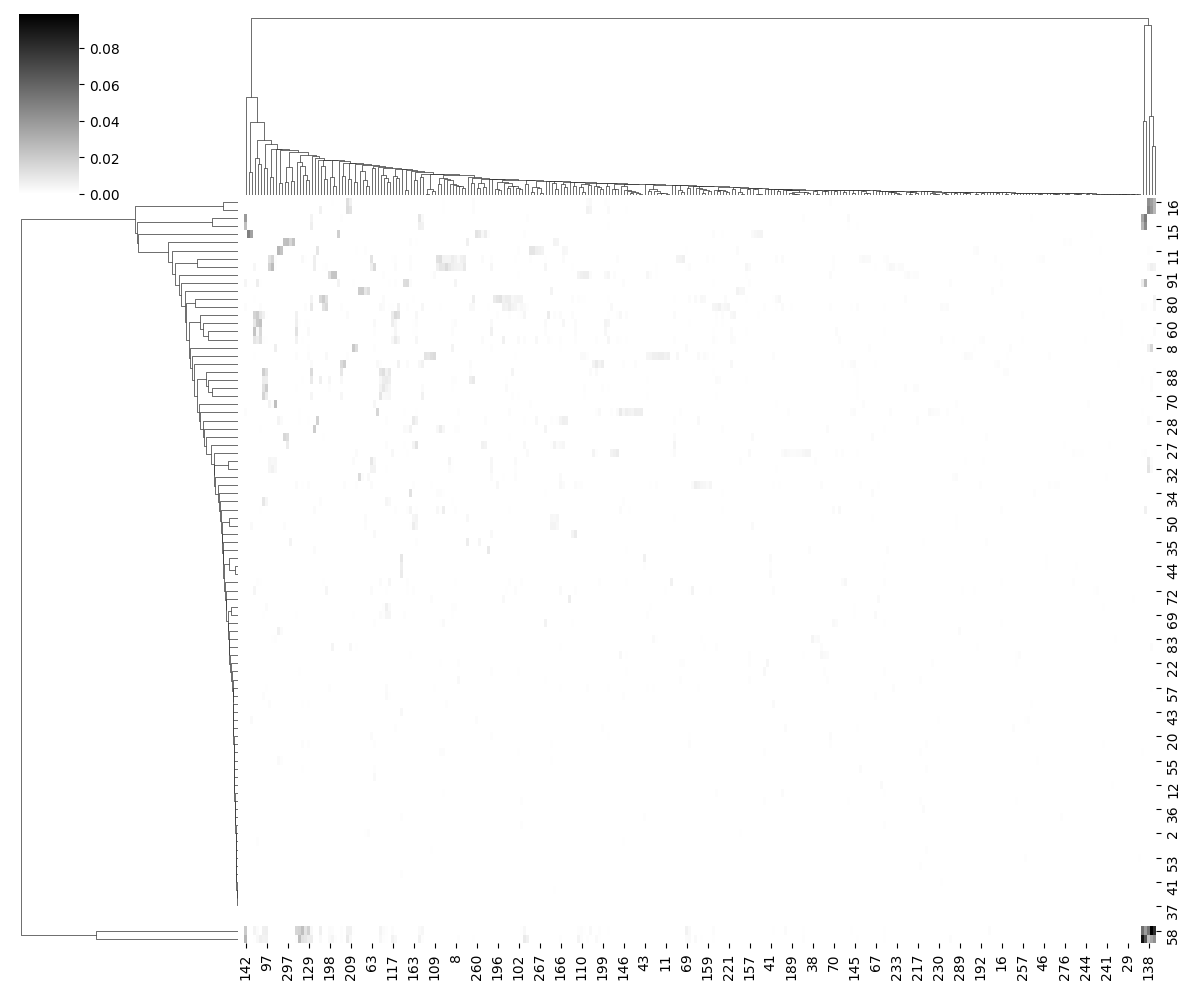

In [ ]:

# get all MBONs

pre_neurons = fetch_body_ids(type_=('MBON', 'startswith'))
post_neurons = fetch_body_ids(type_=('FB', 'startswith'))

matrix = create_first_order_connection_matrix(pre_neurons, post_neurons)
# matrix, common_neurons, pre_common_matrix, common_post_matrix = create_second_order_connection_matrix(pre_neurons, post_neurons)

# get  neuron celltypes
pre_neurons_types = map_to_celltypes(pre_neurons, neurons[0])
post_neurons_types = map_to_celltypes(post_neurons, neurons[0])

# sort the second order matrix by pre neuron types and post neuron types
pre_sort_indices = np.argsort(pre_neurons_types)
post_sort_indices = np.argsort(post_neurons_types)
sorted_matrix = matrix[pre_sort_indices, :][:, post_sort_indices]

# remove any rows and columns that are all zero
nonzero_row_indices = np.where(np.any(sorted_matrix != 0, axis=1))[0]
nonzero_col_indices = np.where(np.any(sorted_matrix != 0, axis=0))[0]
sorted_matrix = sorted_matrix[nonzero_row_indices, :][:, nonzero_col_indices]

pre_neurons_types = pre_neurons_types[pre_sort_indices][nonzero_row_indices]
post_neurons_types = post_neurons_types[post_sort_indices][nonzero_col_indices]

plt.figure(figsize=(30, 15))
plt.imshow(sorted_matrix, cmap='binary', aspect='auto')

# draw a line at every change in pre_neurons_types
pre_type_changes = np.where(pre_neurons_types[:-1] != pre_neurons_types[1:])[0]
for change in pre_type_changes:
    plt.axhline(change + 0.5, color='k', linestyle='-', linewidth=0.05)

# draw a line at every change in post_neurons_types
post_type_changes = np.where(post_neurons_types[:-1] != post_neurons_types[1:])[0]
for change in post_type_changes:
    plt.axvline(change + 0.5, color='k', linestyle='-', linewidth=0.05)

plt.colorbar()

# Get unique cell types and their positions
pre_unique_types = []
pre_positions = []
current_type = pre_neurons_types[0]
start_idx = 0
for i in range(1, len(pre_neurons_types)):
    if pre_neurons_types[i] != current_type:
        pre_unique_types.append(current_type)
        pre_positions.append((start_idx + i - 1) / 2)
        current_type = pre_neurons_types[i]
        start_idx = i
pre_unique_types.append(current_type)
pre_positions.append((start_idx + len(pre_neurons_types) - 1) / 2)

post_unique_types = []
post_positions = []
current_type = post_neurons_types[0]
start_idx = 0
for i in range(1, len(post_neurons_types)):
    if post_neurons_types[i] != current_type:
        post_unique_types.append(current_type)
        post_positions.append((start_idx + i - 1) / 2)
        current_type = post_neurons_types[i]
        start_idx = i
post_unique_types.append(current_type)
post_positions.append((start_idx + len(post_neurons_types) - 1) / 2)

# Set ticks at the center of each cell type group
plt.yticks(pre_positions, pre_unique_types, fontsize=15)
plt.xticks(post_positions, post_unique_types, rotation=90, fontsize=15)

plt.xlabel('Post Neurons (Dimorphic neurons)')
plt.ylabel('Pre Neurons (ORN types)')

# Remove spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
# save as pdf
# plt.savefig('2nd_order_olfactory_to_dimorphic.pdf', dpi=600)
plt.show()

# plot as a clustered heatmap
plt.figure(figsize=(12, 10))
sns.clustermap(sorted_matrix, cmap='binary', figsize=(12, 10), row_cluster=True, col_cluster=True)
# 
plt.show()

In [19]:
create_second_order_connection_matrix(pre_neurons, post_neurons)

(array([[0.        , 0.        , 0.        , ..., 0.        , 0.00070924,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.0004568 , 0.00292428,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00048881],
        ...,
        [0.00544241, 0.00428689, 0.00496686, ..., 0.00614193, 0.00425939,
         0.00530861],
        [0.00128262, 0.00089523, 0.00134017, ..., 0.00135632, 0.00105174,
         0.00143393],
        [0.00305166, 0.00381035, 0.00327846, ..., 0.00644667, 0.00338672,
         0.00590323]]),
 array([ 10063,  10223,  10245,  10394,  10458,  10712,  10765,  10842,
         10930,  11116,  11257,  11425,  11859,  12085,  12177,  12222,
         12750,  13249,  14567,  16297,  27714,  28165,  33487,  34667,
         35441,  36849,  39115,  41681, 223870, 513134, 514441, 523998]),
 array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.00036787, 0.

In [38]:
neurons[0]['type'].str.contains('pC1')

0         False
1         False
2         False
3         False
4         False
          ...  
176566    False
176567    False
176568    False
176569    False
176570    False
Name: type, Length: 176571, dtype: object

/var/folders/y6/xn2dyw2s14b79mrpmzrhykhc0000gn/T/ipykernel_12421/2157228576.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = mask.fillna(False)
/var/folders/y6/xn2dyw2s14b79mrpmzrhykhc0000gn/T/ipykernel_12421/2157228576.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = mask.fillna(False)


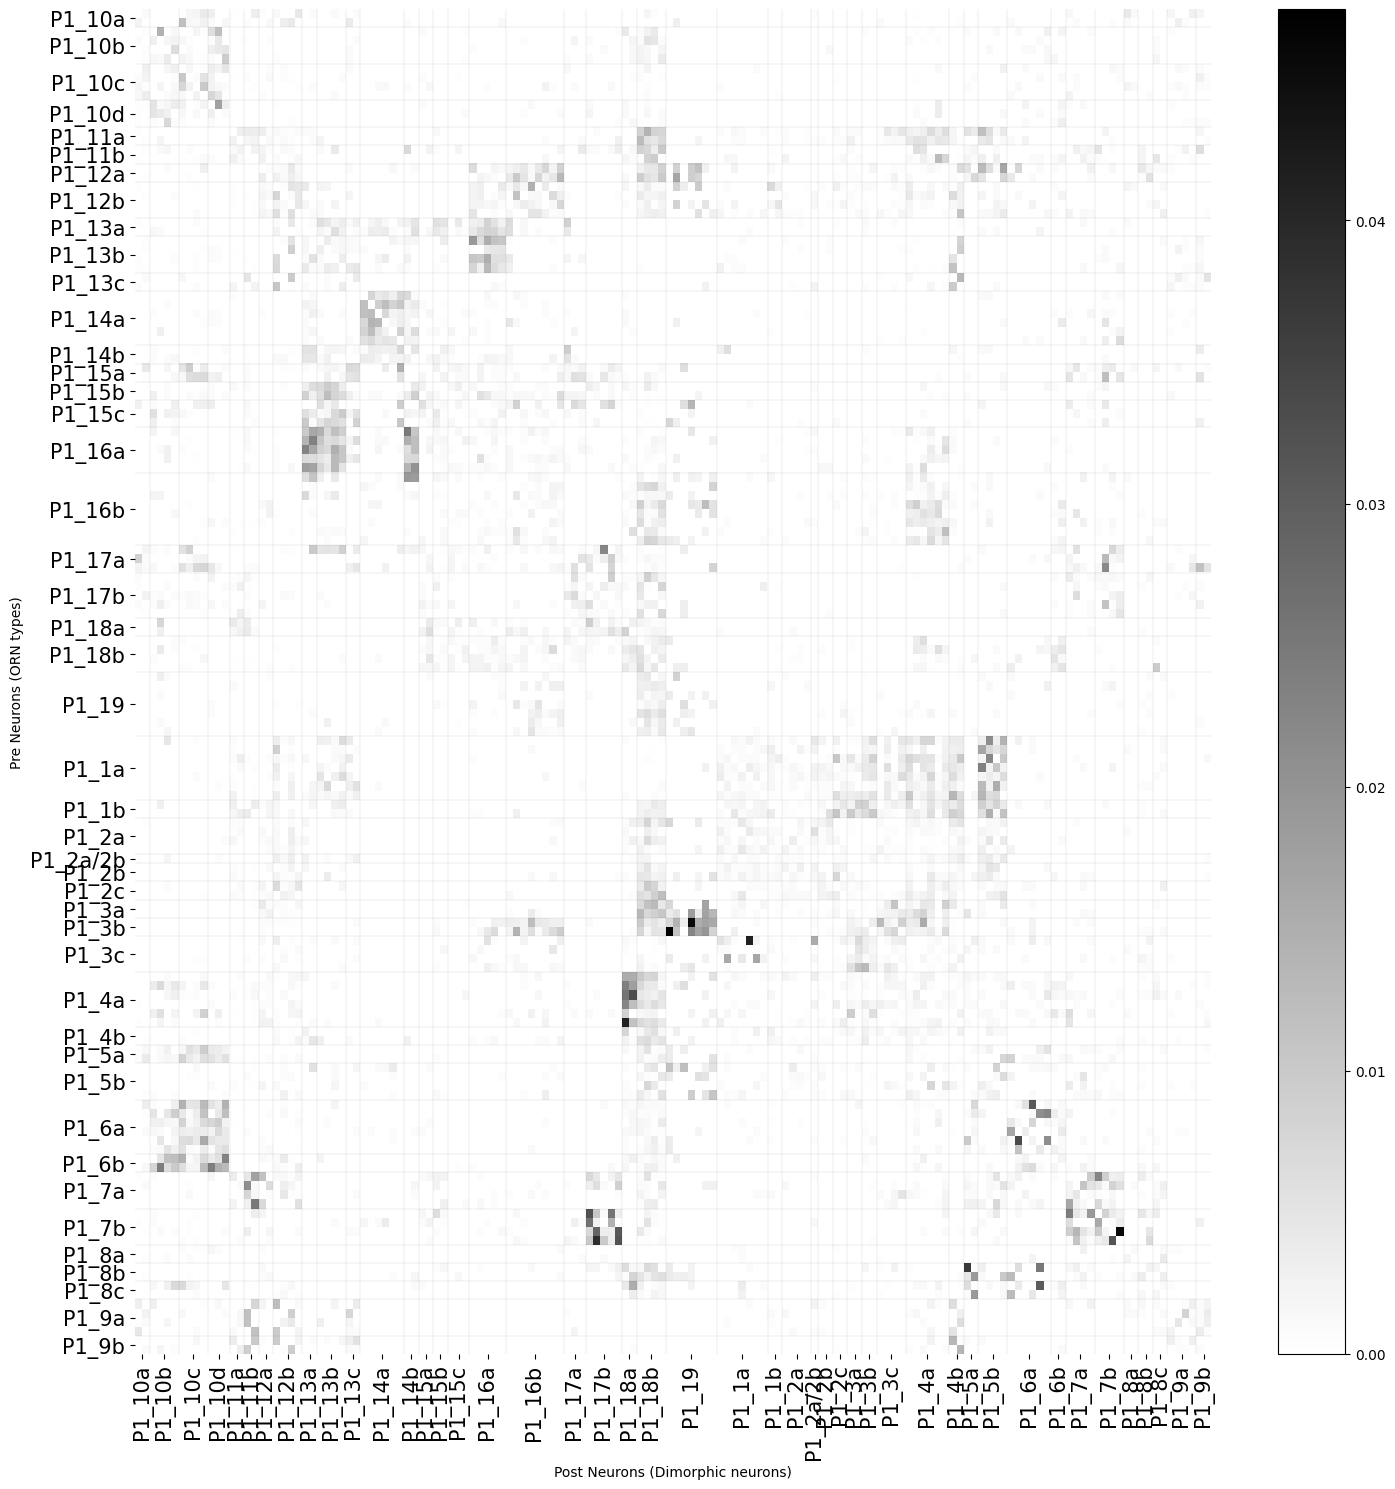

In [51]:

mask = neurons[0]['type'].str.startswith('P1')
mask = mask.fillna(False)
pre_neurons = neurons[0][mask]['bodyId'].values
mask = neurons[0]['type'].str.startswith('P1')
mask = mask.fillna(False)
post_neurons = neurons[0][mask]['bodyId'].values

first_order_matrix = create_first_order_connection_matrix(pre_neurons, post_neurons)

# get  neuron celltypes
pre_neurons_types = map_to_celltypes(pre_neurons, neurons[0])
post_neurons_types = map_to_celltypes(post_neurons, neurons[0])

# sort the second order matrix by pre neuron types and post neuron types
pre_sort_indices = np.argsort(pre_neurons_types)
post_sort_indices = np.argsort(post_neurons_types)
sorted_matrix = first_order_matrix[pre_sort_indices, :][:, post_sort_indices]

# remove any rows and columns that are all zero
nonzero_row_indices = np.where(np.any(sorted_matrix != 0, axis=1))[0]
nonzero_col_indices = np.where(np.any(sorted_matrix != 0, axis=0))[0]
sorted_matrix = sorted_matrix[nonzero_row_indices, :][:, nonzero_col_indices]

pre_neurons_types = pre_neurons_types[pre_sort_indices][nonzero_row_indices]
post_neurons_types = post_neurons_types[post_sort_indices][nonzero_col_indices]

plt.figure(figsize=(15, 15))
plt.imshow(sorted_matrix, cmap='binary', aspect='auto')

# draw a line at every change in pre_neurons_types
pre_type_changes = np.where(pre_neurons_types[:-1] != pre_neurons_types[1:])[0]
for change in pre_type_changes:
    plt.axhline(change + 0.5, color='k', linestyle='-', linewidth=0.05)

# draw a line at every change in post_neurons_types
post_type_changes = np.where(post_neurons_types[:-1] != post_neurons_types[1:])[0]
for change in post_type_changes:
    plt.axvline(change + 0.5, color='k', linestyle='-', linewidth=0.05)

plt.colorbar()

# Get unique cell types and their positions
pre_unique_types = []
pre_positions = []
current_type = pre_neurons_types[0]
start_idx = 0
for i in range(1, len(pre_neurons_types)):
    if pre_neurons_types[i] != current_type:
        pre_unique_types.append(current_type)
        pre_positions.append((start_idx + i - 1) / 2)
        current_type = pre_neurons_types[i]
        start_idx = i
pre_unique_types.append(current_type)
pre_positions.append((start_idx + len(pre_neurons_types) - 1) / 2)

post_unique_types = []
post_positions = []
current_type = post_neurons_types[0]
start_idx = 0
for i in range(1, len(post_neurons_types)):
    if post_neurons_types[i] != current_type:
        post_unique_types.append(current_type)
        post_positions.append((start_idx + i - 1) / 2)
        current_type = post_neurons_types[i]
        start_idx = i
post_unique_types.append(current_type)
post_positions.append((start_idx + len(post_neurons_types) - 1) / 2)

# Set ticks at the center of each cell type group
plt.yticks(pre_positions, pre_unique_types, fontsize=15)
plt.xticks(post_positions, post_unique_types, rotation=90, fontsize=15)

plt.xlabel('Post Neurons (Dimorphic neurons)')
plt.ylabel('Pre Neurons (ORN types)')

# Remove spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
# save as pdf
# plt.savefig('2nd_order_olfactory_to_dimorphic.pdf', dpi=600)
plt.show()

In [ ]:
# simulate the P1 - P1 connectivity matrix using a simple dynamic model

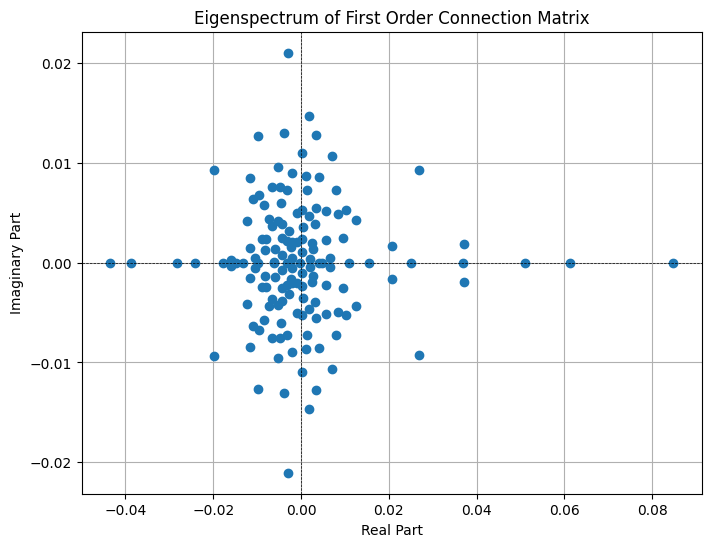

In [52]:
# explore the eigenspectrum of the first order connection matrix
eigenvalues, eigenvectors = np.linalg.eig(first_order_matrix)
plt.figure(figsize=(8, 6))
plt.plot(np.real(eigenvalues), np.imag(eigenvalues), 'o')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.title('Eigenspectrum of First Order Connection Matrix')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.grid()
plt.show()

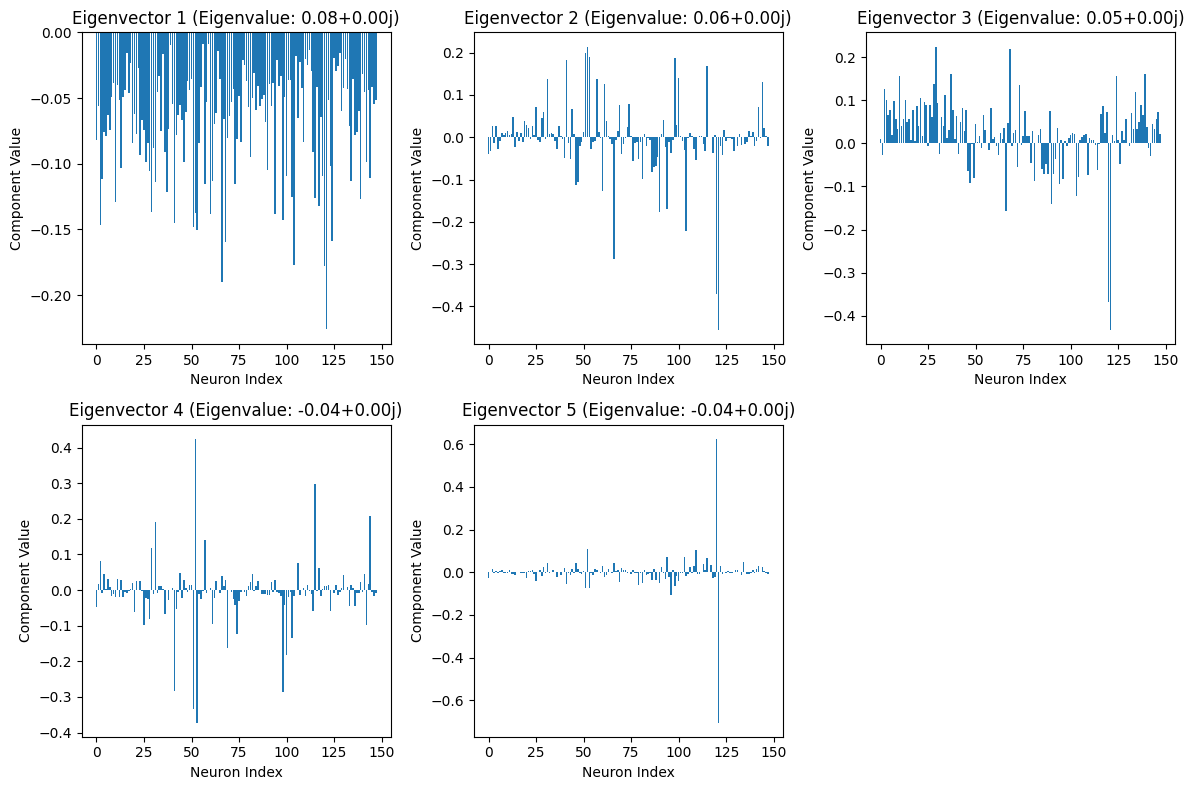

In [53]:
# look at the eigenvectors with the largest eigenvalues
idx = np.argsort(np.abs(eigenvalues))[::-1]
top_eigenvectors = eigenvectors[:, idx[:5]]
plt.figure(figsize=(12, 8))
for i in range(top_eigenvectors.shape[1]):
    plt.subplot(2, 3, i+1)
    plt.bar(range(top_eigenvectors.shape[0]), np.real(top_eigenvectors[:, i]))
    plt.title(f'Eigenvector {i+1} (Eigenvalue: {eigenvalues[idx[i]]:.2f})')
    plt.xlabel('Neuron Index')
    plt.ylabel('Component Value')
plt.tight_layout()
plt.show()

In [42]:
mask = neurons[0]['type'].str.contains('pC1x')
# remove nan to false
mask = mask.fillna(False)
neurons[0][mask]['bodyId'].values

/var/folders/y6/xn2dyw2s14b79mrpmzrhykhc0000gn/T/ipykernel_12421/1207887142.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = mask.fillna(False)


array([ 10217,  10666,  12257,  12366,  12893,  13449, 512580, 521150])

/var/folders/y6/xn2dyw2s14b79mrpmzrhykhc0000gn/T/ipykernel_12421/1437526646.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = mask.fillna(False)
/var/folders/y6/xn2dyw2s14b79mrpmzrhykhc0000gn/T/ipykernel_12421/1437526646.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = mask.fillna(False)


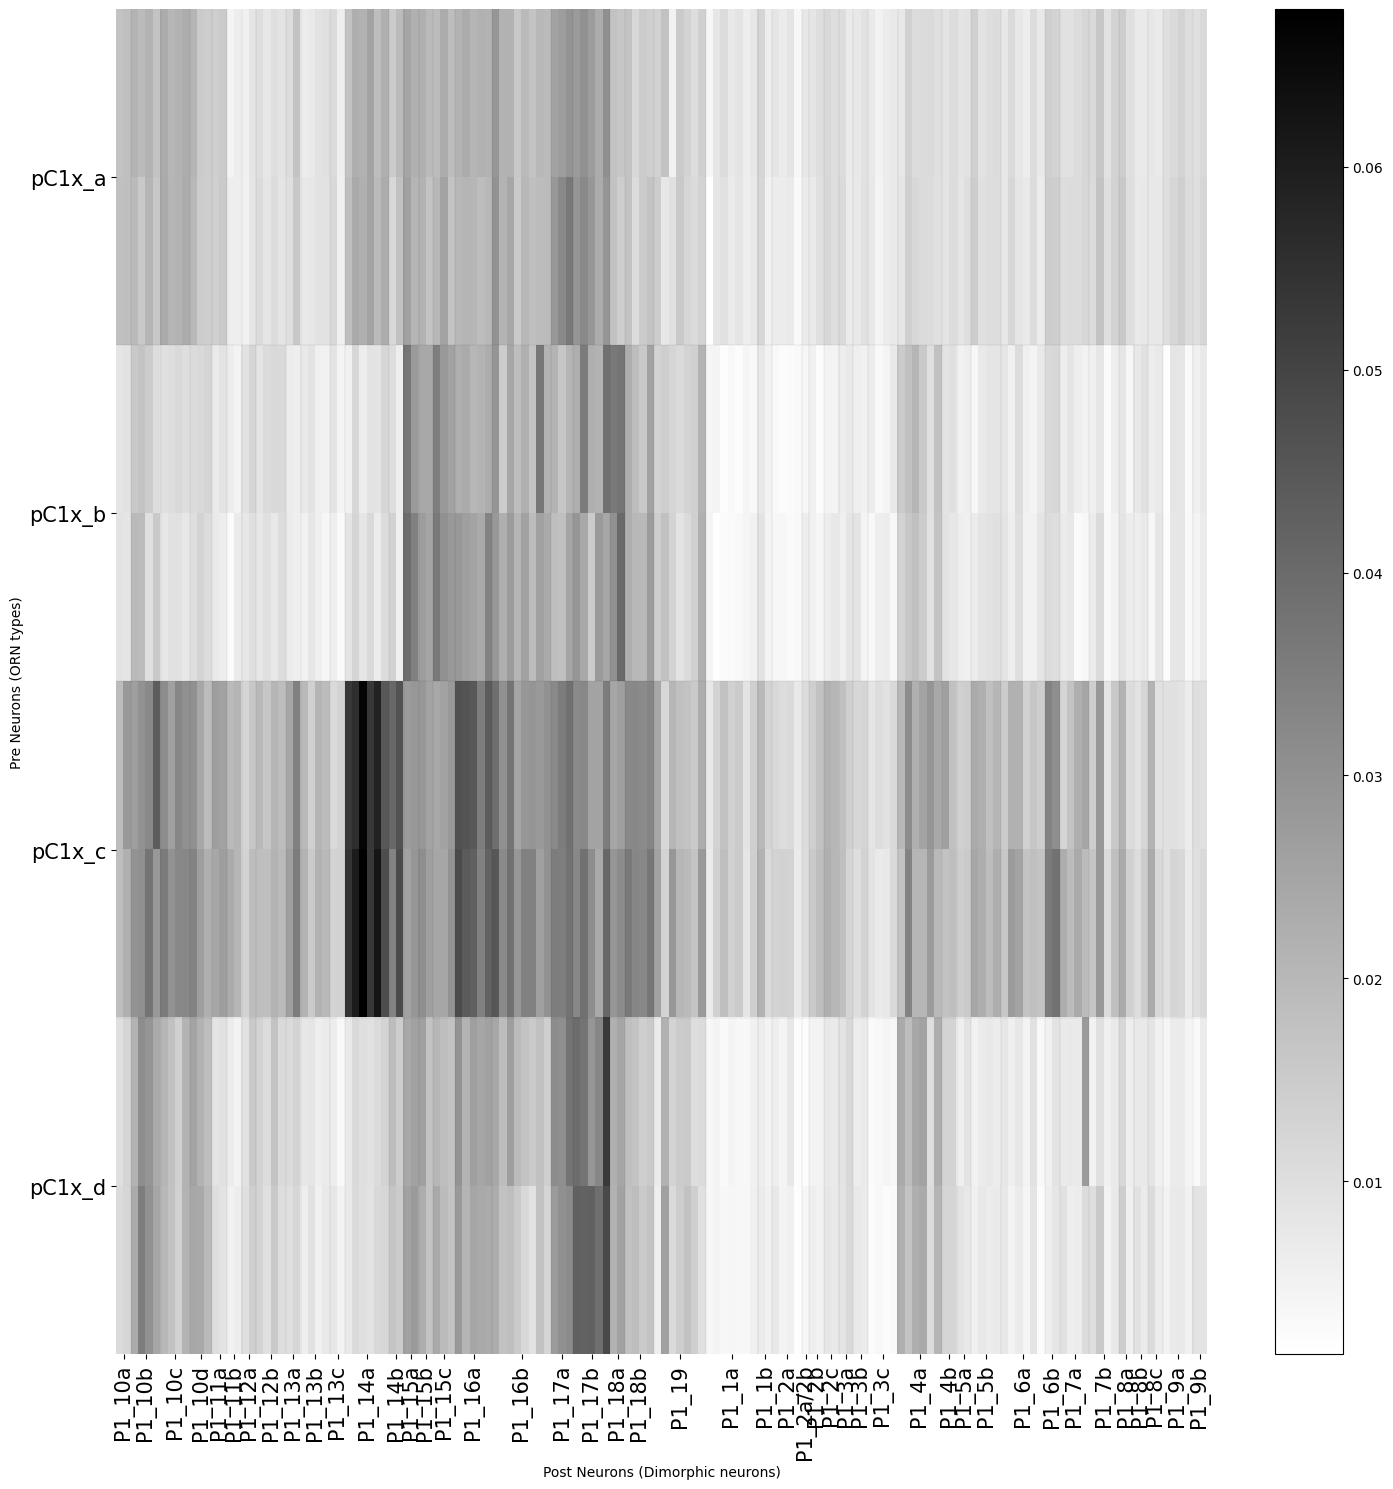

In [47]:

mask = neurons[0]['type'].str.contains('pC1x')
mask = mask.fillna(False)
pre_neurons = neurons[0][mask]['bodyId'].values
mask = neurons[0]['type'].str.startswith('P1')
mask = mask.fillna(False)
post_neurons = neurons[0][mask]['bodyId'].values

second_order, common_neurons, pre_common_matrix, common_post_matrix = create_second_order_connection_matrix(pre_neurons, post_neurons)

# get  neuron celltypes
pre_neurons_types = map_to_celltypes(pre_neurons, neurons[0])
post_neurons_types = map_to_celltypes(post_neurons, neurons[0])

# sort the second order matrix by pre neuron types and post neuron types
pre_sort_indices = np.argsort(pre_neurons_types)
post_sort_indices = np.argsort(post_neurons_types)
sorted_matrix = second_order[pre_sort_indices, :][:, post_sort_indices]

# remove any rows and columns that are all zero
nonzero_row_indices = np.where(np.any(sorted_matrix != 0, axis=1))[0]
nonzero_col_indices = np.where(np.any(sorted_matrix != 0, axis=0))[0]
sorted_matrix = sorted_matrix[nonzero_row_indices, :][:, nonzero_col_indices]

pre_neurons_types = pre_neurons_types[pre_sort_indices][nonzero_row_indices]
post_neurons_types = post_neurons_types[post_sort_indices][nonzero_col_indices]

plt.figure(figsize=(15, 15))
plt.imshow(sorted_matrix, cmap='binary', aspect='auto')

# draw a line at every change in pre_neurons_types
pre_type_changes = np.where(pre_neurons_types[:-1] != pre_neurons_types[1:])[0]
for change in pre_type_changes:
    plt.axhline(change + 0.5, color='k', linestyle='-', linewidth=0.05)

# draw a line at every change in post_neurons_types
post_type_changes = np.where(post_neurons_types[:-1] != post_neurons_types[1:])[0]
for change in post_type_changes:
    plt.axvline(change + 0.5, color='k', linestyle='-', linewidth=0.05)

plt.colorbar()

# Get unique cell types and their positions
pre_unique_types = []
pre_positions = []
current_type = pre_neurons_types[0]
start_idx = 0
for i in range(1, len(pre_neurons_types)):
    if pre_neurons_types[i] != current_type:
        pre_unique_types.append(current_type)
        pre_positions.append((start_idx + i - 1) / 2)
        current_type = pre_neurons_types[i]
        start_idx = i
pre_unique_types.append(current_type)
pre_positions.append((start_idx + len(pre_neurons_types) - 1) / 2)

post_unique_types = []
post_positions = []
current_type = post_neurons_types[0]
start_idx = 0
for i in range(1, len(post_neurons_types)):
    if post_neurons_types[i] != current_type:
        post_unique_types.append(current_type)
        post_positions.append((start_idx + i - 1) / 2)
        current_type = post_neurons_types[i]
        start_idx = i
post_unique_types.append(current_type)
post_positions.append((start_idx + len(post_neurons_types) - 1) / 2)

# Set ticks at the center of each cell type group
plt.yticks(pre_positions, pre_unique_types, fontsize=15)
plt.xticks(post_positions, post_unique_types, rotation=90, fontsize=15)

plt.xlabel('Post Neurons (Dimorphic neurons)')
plt.ylabel('Pre Neurons (ORN types)')

# Remove spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
# save as pdf
# plt.savefig('2nd_order_olfactory_to_dimorphic.pdf', dpi=600)
plt.show()

Top 20 contributing interneurons:
      bodyId     type  input_from_pre  output_to_post  total_contribution
548    28909  CL344_b        0.173981        0.193728            0.033705
141    12281  CL344_b        0.147328        0.195644            0.028824
190    13398  CL344_a        0.131191        0.098783            0.012959
725    58186  SIP141m        0.080938        0.139293            0.011274
230    14350    CL144        0.063317        0.170137            0.010772
6      10097    oviIN        0.016882        0.588062            0.009928
172    13131  CL344_a        0.111780        0.088772            0.009923
11     10138    oviIN        0.015769        0.592619            0.009345
196    13523   SMP165        0.071602        0.124774            0.008934
1139  525777   SMP165        0.065536        0.121302            0.007950
176    13171    CL144        0.058463        0.127765            0.007469
1003  514378  SIP141m        0.058756        0.126434            0.007429
140 

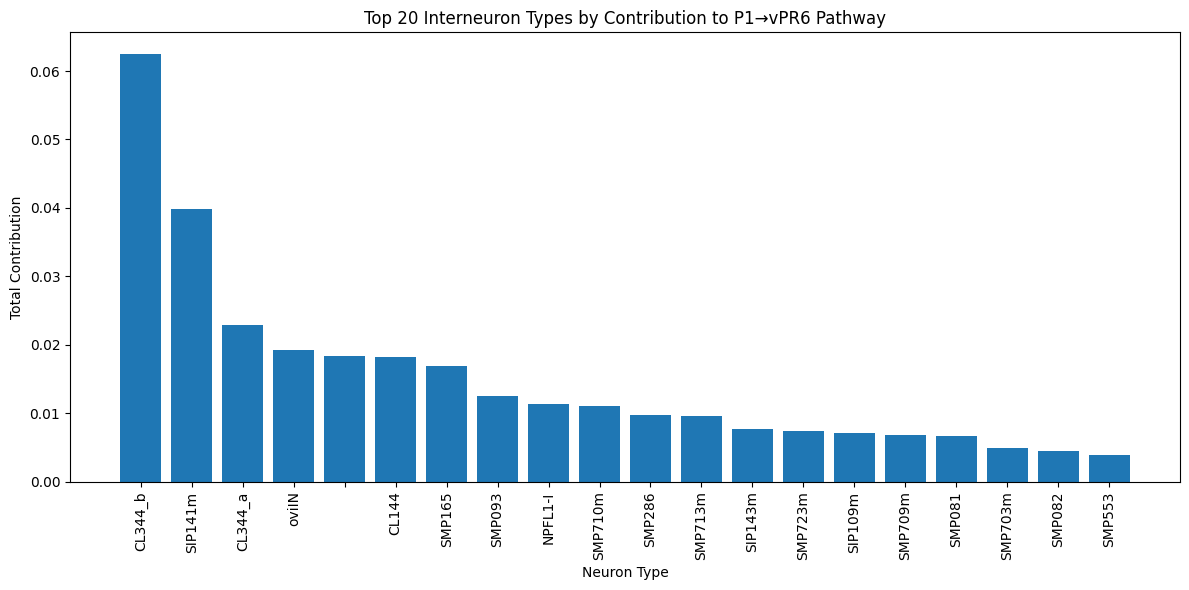

In [48]:
neurons[0][neurons[0]['bodyId'].isin(common_neurons)]
# Calculate contribution of each common interneuron
# Contribution is the product of input from pre-neurons and output to post-neurons
common_input = np.sum(pre_common_matrix, axis=0)  # Total input from pre neurons to each common neuron
common_output = np.sum(common_post_matrix, axis=1)  # Total output from each common neuron to post neurons

# Total contribution is the product (geometric mean already applied in second_order calculation)
common_contributions = common_input * common_output

# Map common neuron bodyIds to cell types
common_neuron_types = map_to_celltypes(common_neurons, neurons[0])

# Create DataFrame for easy sorting and viewing
contribution_df = pd.DataFrame({
    'bodyId': common_neurons,
    'type': common_neuron_types,
    'input_from_pre': common_input,
    'output_to_post': common_output,
    'total_contribution': common_contributions
})

# Sort by total contribution (highest first)
contribution_df = contribution_df.sort_values(by='total_contribution', ascending=False)

# Display top contributors
print("Top 20 contributing interneurons:")
print(contribution_df.head(20))

# Group by cell type and sum contributions
type_contributions = contribution_df.groupby('type').agg({
    'total_contribution': 'sum',
    'bodyId': 'count'
}).rename(columns={'bodyId': 'count'}).sort_values(by='total_contribution', ascending=False)

print("\nContributions by cell type:")
print(type_contributions.head(20))

# Visualize top contributing cell types
plt.figure(figsize=(12, 6))
plt.bar(type_contributions.head(20).index, type_contributions.head(20)['total_contribution'])
plt.xticks(rotation=90)
plt.ylabel('Total Contribution')
plt.xlabel('Neuron Type')
plt.title('Top 20 Interneuron Types by Contribution to P1→vPR6 Pathway')
plt.tight_layout()
plt.show()
#


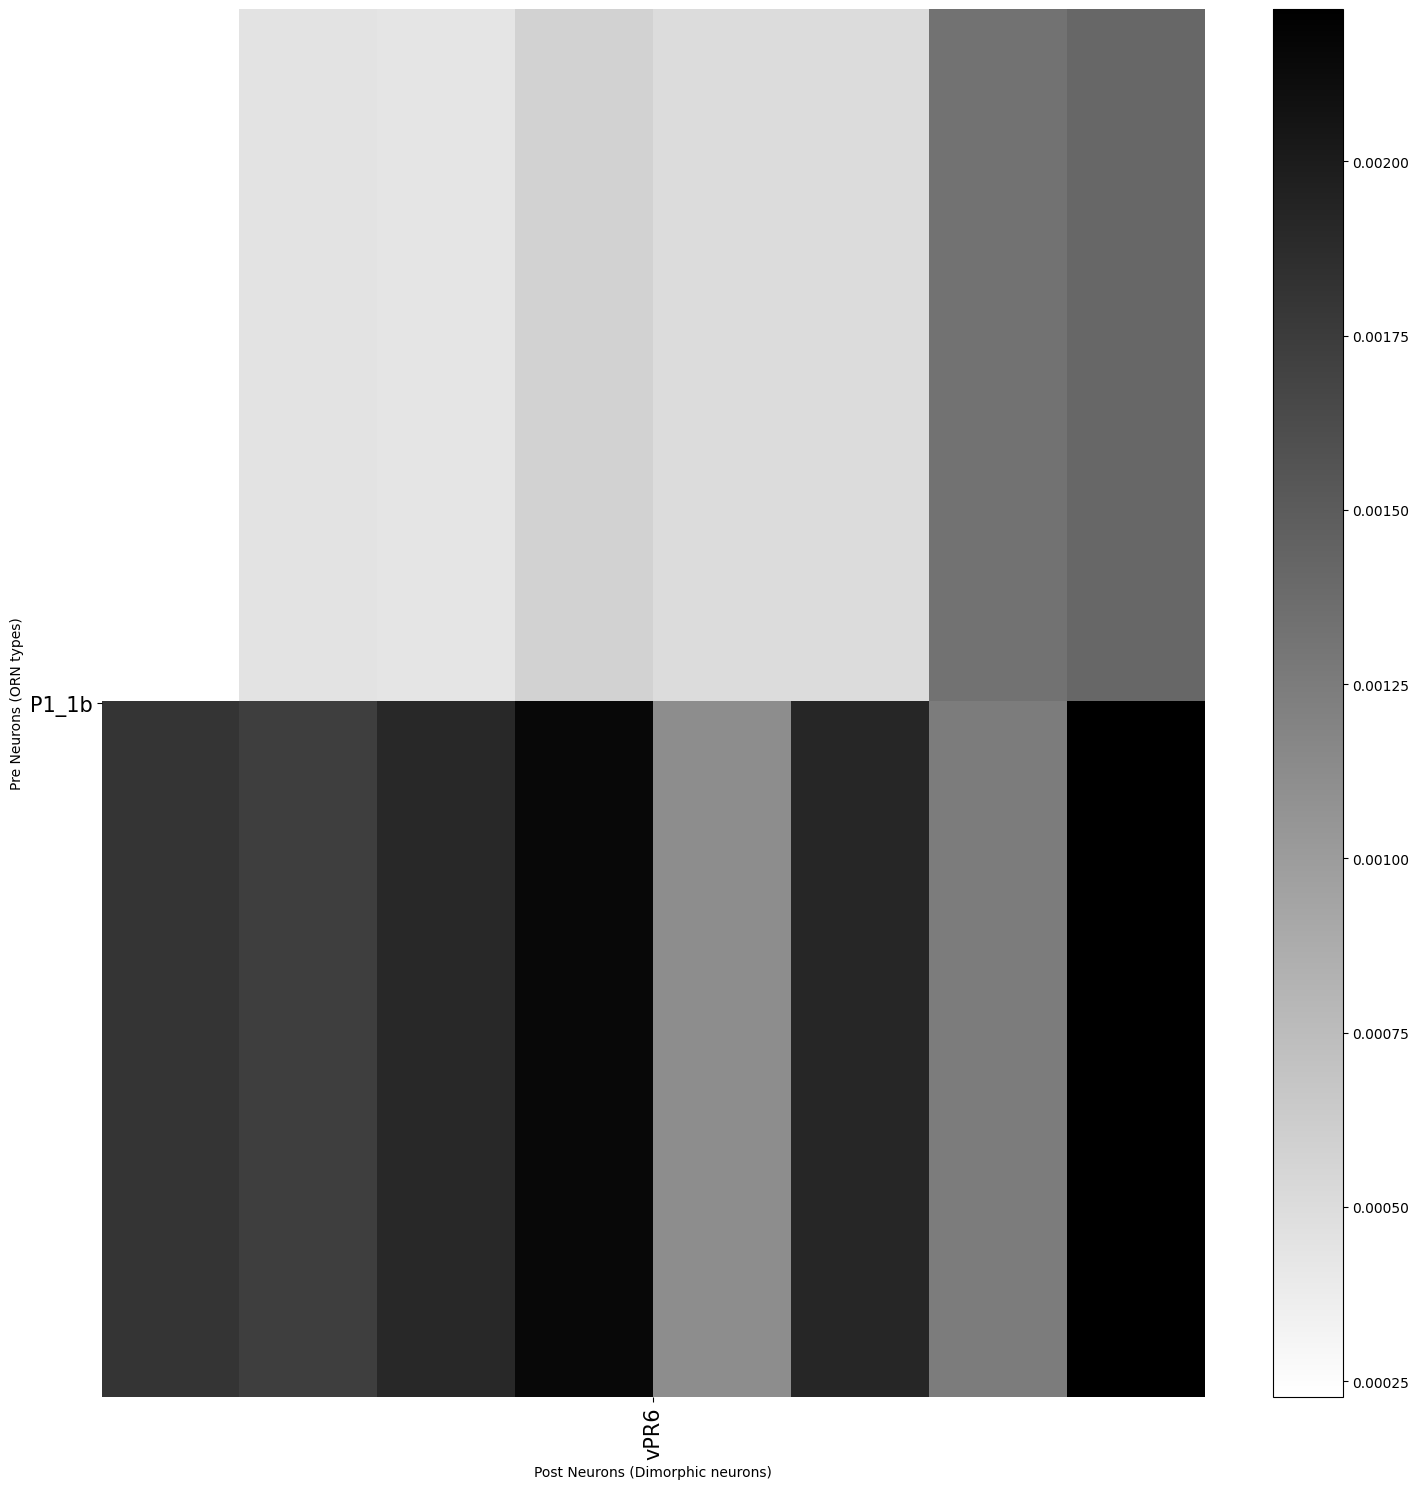

In [32]:
pre_neurons = neurons[0][neurons[0]['type']=='P1_1b']['bodyId'].values
post_neurons = neurons[0][neurons[0]['type']=='vPR6']['bodyId'].values

second_order, common_neurons, pre_common_matrix, common_post_matrix = create_second_order_connection_matrix(pre_neurons, post_neurons)

# get  neuron celltypes
pre_neurons_types = map_to_celltypes(pre_neurons, neurons[0])
post_neurons_types = map_to_celltypes(post_neurons, neurons[0])

# sort the second order matrix by pre neuron types and post neuron types
pre_sort_indices = np.argsort(pre_neurons_types)
post_sort_indices = np.argsort(post_neurons_types)
sorted_matrix = second_order[pre_sort_indices, :][:, post_sort_indices]

# remove any rows and columns that are all zero
nonzero_row_indices = np.where(np.any(sorted_matrix != 0, axis=1))[0]
nonzero_col_indices = np.where(np.any(sorted_matrix != 0, axis=0))[0]
sorted_matrix = sorted_matrix[nonzero_row_indices, :][:, nonzero_col_indices]

pre_neurons_types = pre_neurons_types[pre_sort_indices][nonzero_row_indices]
post_neurons_types = post_neurons_types[post_sort_indices][nonzero_col_indices]

plt.figure(figsize=(15, 15))
plt.imshow(sorted_matrix, cmap='binary', aspect='auto')

# draw a line at every change in pre_neurons_types
pre_type_changes = np.where(pre_neurons_types[:-1] != pre_neurons_types[1:])[0]
for change in pre_type_changes:
    plt.axhline(change + 0.5, color='k', linestyle='-', linewidth=0.05)

# draw a line at every change in post_neurons_types
post_type_changes = np.where(post_neurons_types[:-1] != post_neurons_types[1:])[0]
for change in post_type_changes:
    plt.axvline(change + 0.5, color='k', linestyle='-', linewidth=0.05)

plt.colorbar()

# Get unique cell types and their positions
pre_unique_types = []
pre_positions = []
current_type = pre_neurons_types[0]
start_idx = 0
for i in range(1, len(pre_neurons_types)):
    if pre_neurons_types[i] != current_type:
        pre_unique_types.append(current_type)
        pre_positions.append((start_idx + i - 1) / 2)
        current_type = pre_neurons_types[i]
        start_idx = i
pre_unique_types.append(current_type)
pre_positions.append((start_idx + len(pre_neurons_types) - 1) / 2)

post_unique_types = []
post_positions = []
current_type = post_neurons_types[0]
start_idx = 0
for i in range(1, len(post_neurons_types)):
    if post_neurons_types[i] != current_type:
        post_unique_types.append(current_type)
        post_positions.append((start_idx + i - 1) / 2)
        current_type = post_neurons_types[i]
        start_idx = i
post_unique_types.append(current_type)
post_positions.append((start_idx + len(post_neurons_types) - 1) / 2)

# Set ticks at the center of each cell type group
plt.yticks(pre_positions, pre_unique_types, fontsize=15)
plt.xticks(post_positions, post_unique_types, rotation=90, fontsize=15)

plt.xlabel('Post Neurons (Dimorphic neurons)')
plt.ylabel('Pre Neurons (ORN types)')

# Remove spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
# save as pdf
# plt.savefig('2nd_order_olfactory_to_dimorphic.pdf', dpi=600)
plt.show()

Top 20 contributing interneurons:
   bodyId      type  input_from_pre  output_to_post  total_contribution
0   10245     DNp36        0.000270        0.087056        2.352867e-05
1   10458     DNp13        0.004647        0.000483        2.246024e-06
6  523998     pIP10        0.000089        0.018115        1.609375e-06
4   13249   DNpe034        0.000918        0.001643        1.509077e-06
5   39115  AN08B084        0.001030        0.001369        1.409488e-06
2   10765      pMP2        0.000117        0.004921        5.760699e-07
3   10930      pMP2        0.000113        0.000967        1.091521e-07

Contributions by cell type:
          total_contribution  count
type                               
DNp36           2.352867e-05      1
DNp13           2.246024e-06      1
pIP10           1.609375e-06      1
DNpe034         1.509077e-06      1
AN08B084        1.409488e-06      1
pMP2            6.852220e-07      2


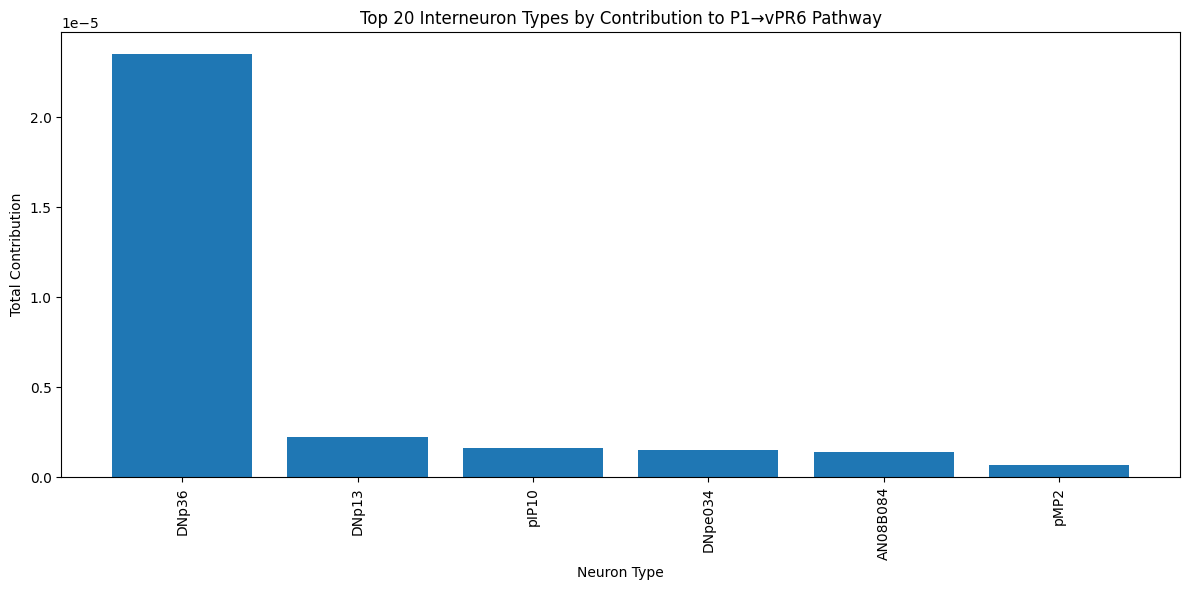

In [33]:
neurons[0][neurons[0]['bodyId'].isin(common_neurons)]
# Calculate contribution of each common interneuron
# Contribution is the product of input from pre-neurons and output to post-neurons
common_input = np.sum(pre_common_matrix, axis=0)  # Total input from pre neurons to each common neuron
common_output = np.sum(common_post_matrix, axis=1)  # Total output from each common neuron to post neurons

# Total contribution is the product (geometric mean already applied in second_order calculation)
common_contributions = common_input * common_output

# Map common neuron bodyIds to cell types
common_neuron_types = map_to_celltypes(common_neurons, neurons[0])

# Create DataFrame for easy sorting and viewing
contribution_df = pd.DataFrame({
    'bodyId': common_neurons,
    'type': common_neuron_types,
    'input_from_pre': common_input,
    'output_to_post': common_output,
    'total_contribution': common_contributions
})

# Sort by total contribution (highest first)
contribution_df = contribution_df.sort_values(by='total_contribution', ascending=False)

# Display top contributors
print("Top 20 contributing interneurons:")
print(contribution_df.head(20))

# Group by cell type and sum contributions
type_contributions = contribution_df.groupby('type').agg({
    'total_contribution': 'sum',
    'bodyId': 'count'
}).rename(columns={'bodyId': 'count'}).sort_values(by='total_contribution', ascending=False)

print("\nContributions by cell type:")
print(type_contributions.head(20))

# Visualize top contributing cell types
plt.figure(figsize=(12, 6))
plt.bar(type_contributions.head(20).index, type_contributions.head(20)['total_contribution'])
plt.xticks(rotation=90)
plt.ylabel('Total Contribution')
plt.xlabel('Neuron Type')
plt.title('Top 20 Interneuron Types by Contribution to P1→vPR6 Pathway')
plt.tight_layout()
plt.show()
#


In [28]:
neurons[0][neurons[0]['type'].isin(P1s)]['celltypePredictedNt'].unique()

array(['acetylcholine'], dtype=object)

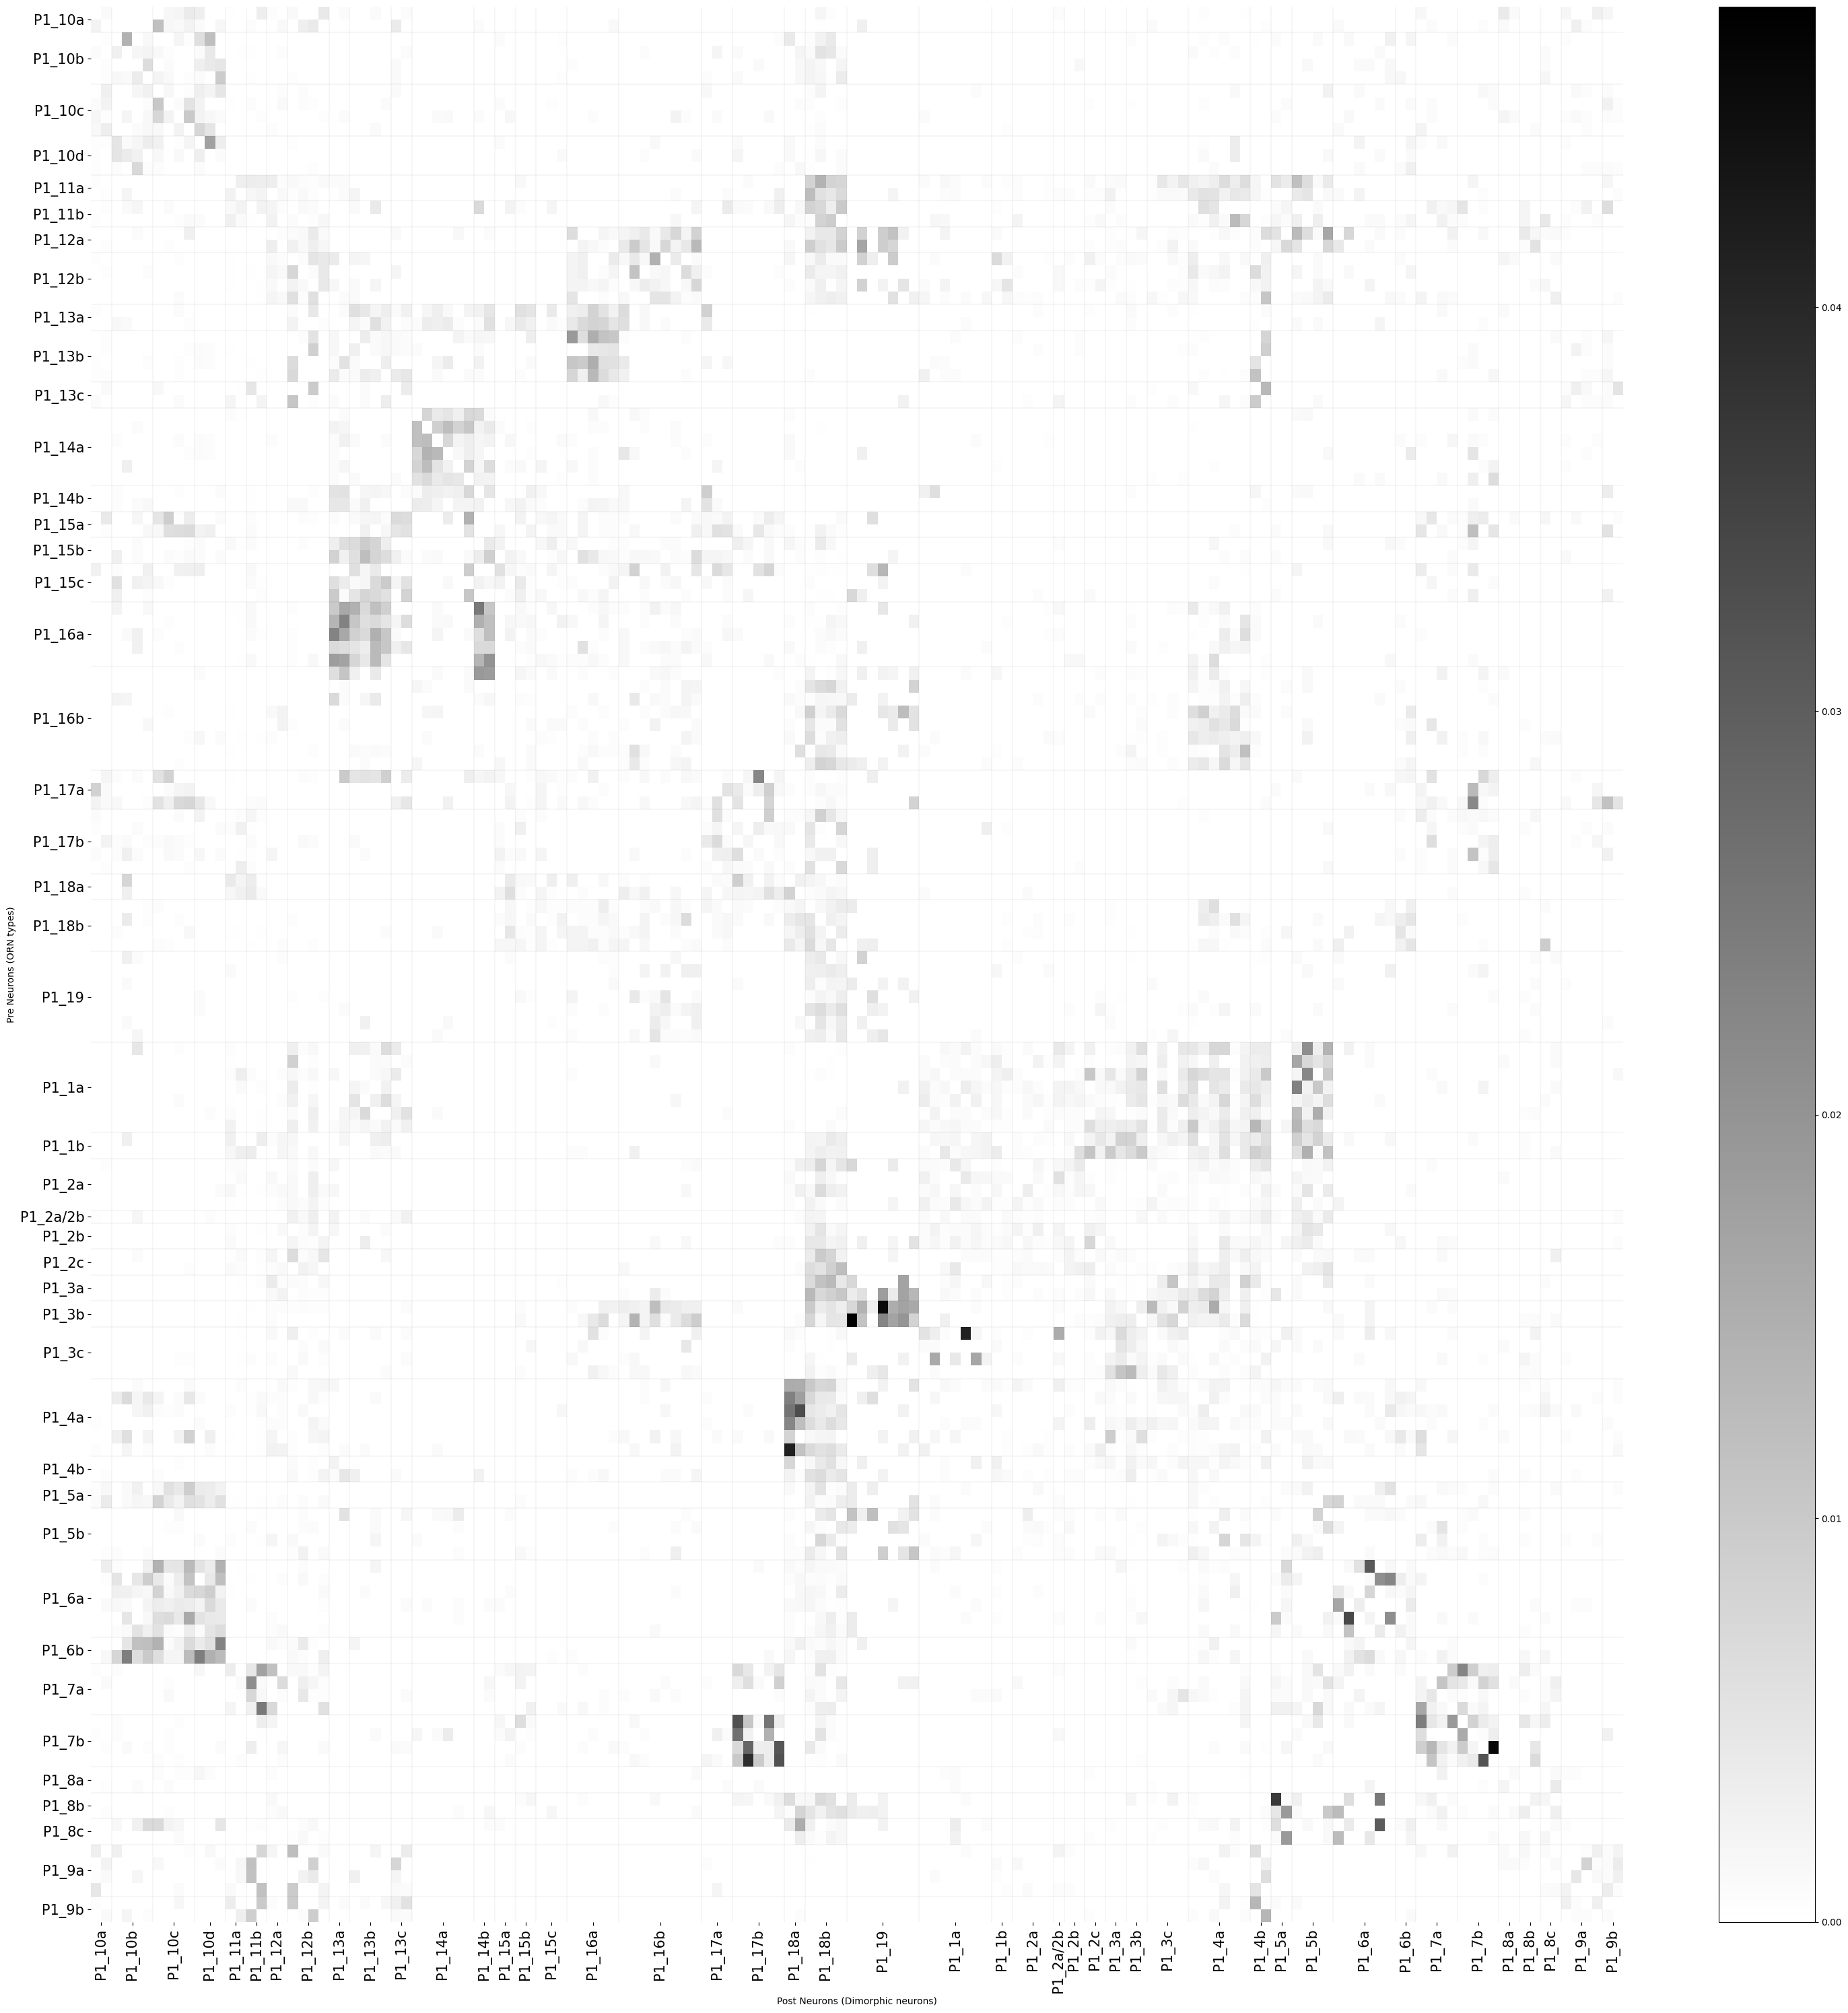

In [17]:
pre_neurons = P1_bodyIds
post_neurons = P1_bodyIds

first_order_matrix = create_first_order_connection_matrix(pre_neurons, post_neurons)

# get  neuron celltypes
pre_neurons_types = map_to_celltypes(pre_neurons, neurons[0])
post_neurons_types = map_to_celltypes(post_neurons, neurons[0])

# sort the second order matrix by pre neuron types and post neuron types
pre_sort_indices = np.argsort(pre_neurons_types)
post_sort_indices = np.argsort(post_neurons_types)
sorted_matrix = first_order_matrix[pre_sort_indices, :][:, post_sort_indices]

# remove any rows and columns that are all zero
nonzero_row_indices = np.where(np.any(sorted_matrix != 0, axis=1))[0]
nonzero_col_indices = np.where(np.any(sorted_matrix != 0, axis=0))[0]
sorted_matrix = sorted_matrix[nonzero_row_indices, :][:, nonzero_col_indices]

pre_neurons_types = pre_neurons_types[pre_sort_indices][nonzero_row_indices]
post_neurons_types = post_neurons_types[post_sort_indices][nonzero_col_indices]

plt.figure(figsize=(30, 30))
plt.imshow(sorted_matrix, cmap='binary', aspect='auto')

# draw a line at every change in pre_neurons_types
pre_type_changes = np.where(pre_neurons_types[:-1] != pre_neurons_types[1:])[0]
for change in pre_type_changes:
    plt.axhline(change + 0.5, color='k', linestyle='-', linewidth=0.05)

# draw a line at every change in post_neurons_types
post_type_changes = np.where(post_neurons_types[:-1] != post_neurons_types[1:])[0]
for change in post_type_changes:
    plt.axvline(change + 0.5, color='k', linestyle='-', linewidth=0.05)

plt.colorbar()

# Get unique cell types and their positions
pre_unique_types = []
pre_positions = []
current_type = pre_neurons_types[0]
start_idx = 0
for i in range(1, len(pre_neurons_types)):
    if pre_neurons_types[i] != current_type:
        pre_unique_types.append(current_type)
        pre_positions.append((start_idx + i - 1) / 2)
        current_type = pre_neurons_types[i]
        start_idx = i
pre_unique_types.append(current_type)
pre_positions.append((start_idx + len(pre_neurons_types) - 1) / 2)

post_unique_types = []
post_positions = []
current_type = post_neurons_types[0]
start_idx = 0
for i in range(1, len(post_neurons_types)):
    if post_neurons_types[i] != current_type:
        post_unique_types.append(current_type)
        post_positions.append((start_idx + i - 1) / 2)
        current_type = post_neurons_types[i]
        start_idx = i
post_unique_types.append(current_type)
post_positions.append((start_idx + len(post_neurons_types) - 1) / 2)

# Set ticks at the center of each cell type group
plt.yticks(pre_positions, pre_unique_types, fontsize=15)
plt.xticks(post_positions, post_unique_types, rotation=90, fontsize=15)

plt.xlabel('Post Neurons (Dimorphic neurons)')
plt.ylabel('Pre Neurons (ORN types)')

# Remove spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
# save as pdf
# plt.savefig('2nd_order_olfactory_to_dimorphic.pdf', dpi=600)
plt.show()

In [69]:
# Simulate P1-P1 network dynamics using a simple rate-based model
# Model: dx/dt = -x + W @ f(x) + input
# Where f(x) is a ReLU-like nonlinearity

def simulate_network_dynamics(W, initial_input, n_steps=100, tau=10.0, dt=0.1, 
                             nonlinearity='relu', noise_level=0.01, excitatory_strength=1.0):
    """
    Simulate network dynamics with connectivity matrix W.
    
    Parameters:
    - W: connectivity matrix (normalized weights)
    - initial_input: initial external input to neurons
    - n_steps: number of time steps to simulate
    - tau: time constant
    - dt: time step
    - nonlinearity: 'relu', 'sigmoid', or 'tanh'
    - noise_level: amplitude of noise added at each step
    - excitatory_strength: scaling factor for excitatory connections (default=1.0)
                          Values > 1 increase excitation, < 1 decrease it
    
    Returns:
    - activity: (n_steps, n_neurons) array of activity over time
    """
    n_neurons = W.shape[0]
    activity = np.zeros((n_steps, n_neurons))
    
    # Initialize with input
    activity[0, :] = initial_input
    
    # Scale the connectivity matrix by excitatory strength
    W_scaled = W * excitatory_strength
    
    # Define nonlinearity
    if nonlinearity == 'relu':
        f = lambda x: np.maximum(0, x)
    elif nonlinearity == 'sigmoid':
        f = lambda x: 1 / (1 + np.exp(-x))
    elif nonlinearity == 'tanh':
        f = lambda x: np.tanh(x)
    else:
        f = lambda x: x
    
    # Simulate dynamics
    for t in range(1, n_steps):
        # Add noise
        noise = noise_level * np.random.randn(n_neurons)
        
        # Update: dx/dt = -x + excitatory_strength * W @ f(x) + noise
        dxdt = -activity[t-1, :] + W_scaled @ f(activity[t-1, :]) + noise
        activity[t, :] = activity[t-1, :] + (dt / tau) * dxdt
        
        # Clip to prevent explosion
        activity[t, :] = np.clip(activity[t, :], -10, 10)
    
    return activity

# Prepare connectivity matrix (use normalized weights)
W = first_order_matrix.copy()

# Create initial input: stimulate a few random P1 neurons
n_neurons = W.shape[0]
initial_input = np.zeros(n_neurons)
# Stimulate 5 random neurons
n_stimulated = 0
stimulated_indices = np.random.choice(n_neurons, size=n_stimulated, replace=False)
initial_input[stimulated_indices] = 1.0

# Run simulation with controllable excitatory strength
excitatory_strength = 20.0  # Adjust this parameter: >1 = stronger, <1 = weaker, 1 = original
activity = simulate_network_dynamics(
    W, 
    initial_input, 
    n_steps=200, 
    tau=10.0, 
    dt=0.1, 
    nonlinearity='relu',
    noise_level=0.01,
    excitatory_strength=excitatory_strength
)

print(f"Simulation complete. Activity shape: {activity.shape}")
print(f"Stimulated neurons: {stimulated_indices}")
print(f"Excitatory strength: {excitatory_strength}")

Simulation complete. Activity shape: (200, 148)
Stimulated neurons: []
Excitatory strength: 20.0


/var/folders/y6/xn2dyw2s14b79mrpmzrhykhc0000gn/T/ipykernel_12421/2938308251.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=8)
/var/folders/y6/xn2dyw2s14b79mrpmzrhykhc0000gn/T/ipykernel_12421/2938308251.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(ax4.get_xticklabels(), rotation=90, fontsize=8)


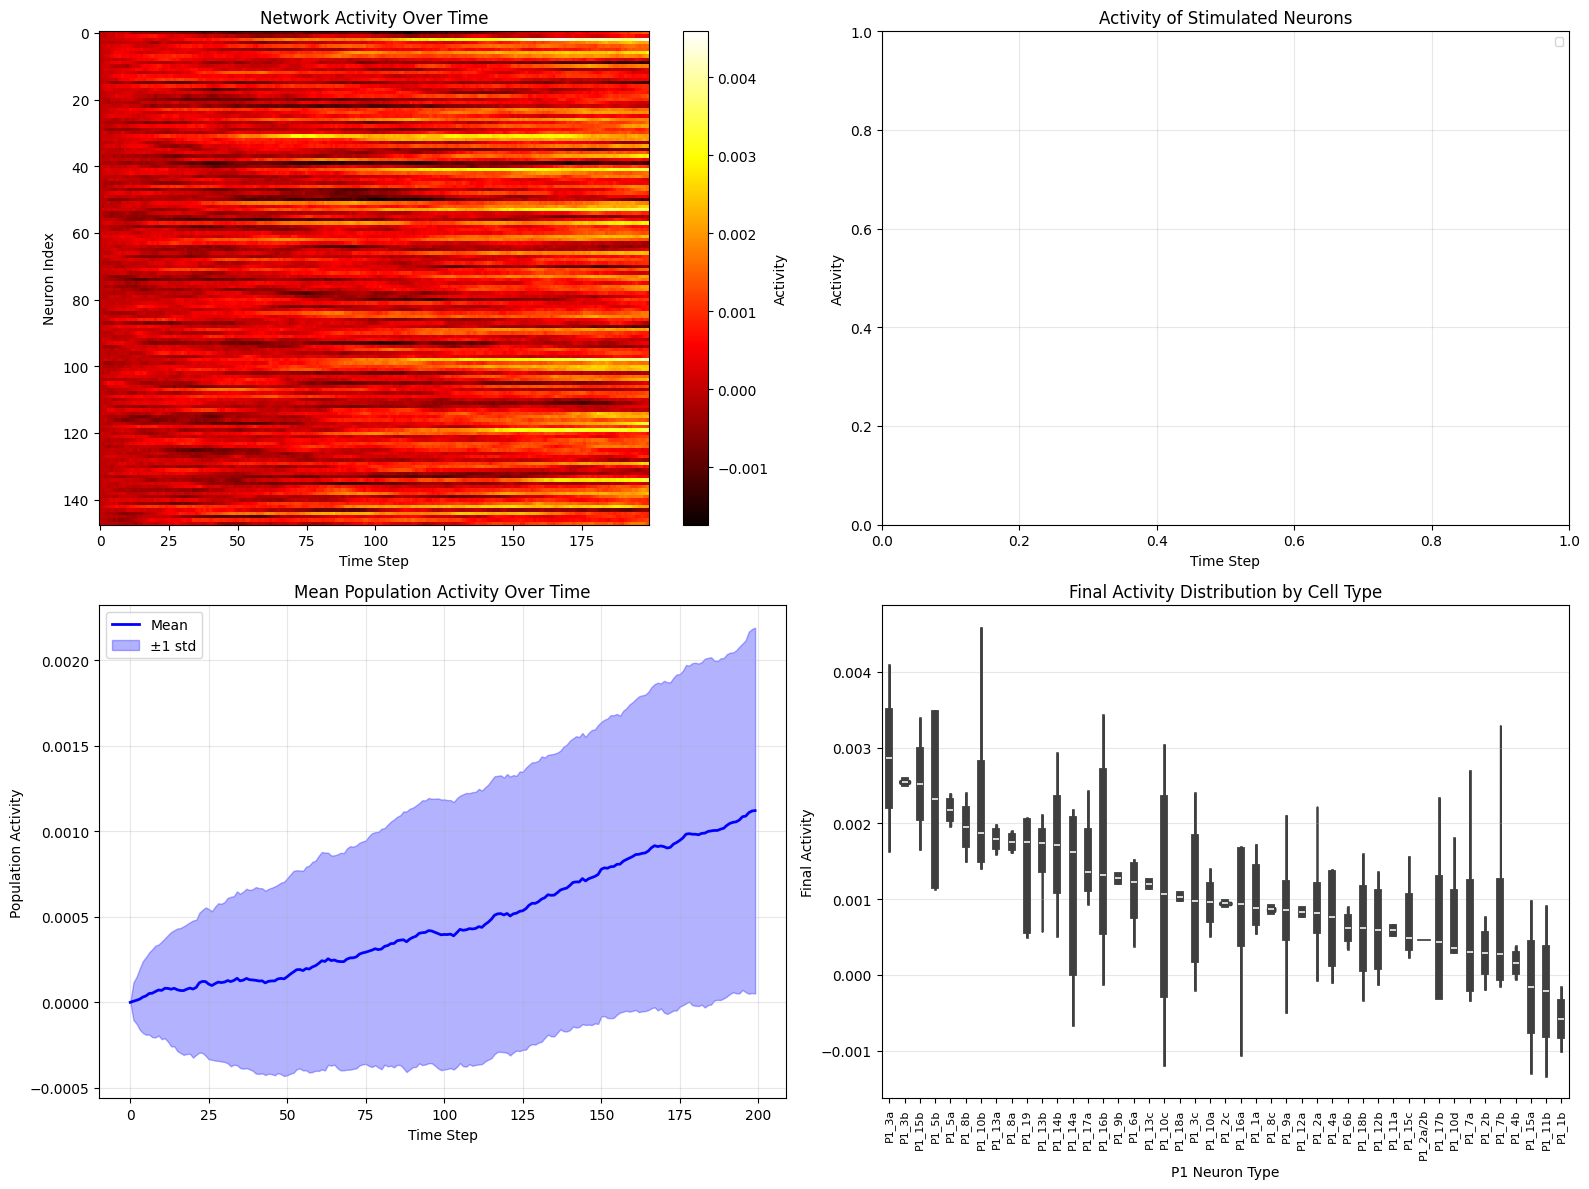

In [70]:
# Visualize network activity over time
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Heatmap of activity over time
ax1 = axes[0, 0]
im1 = ax1.imshow(activity.T, aspect='auto', cmap='hot', interpolation='nearest')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Neuron Index')
ax1.set_title('Network Activity Over Time')
plt.colorbar(im1, ax=ax1, label='Activity')

# Mark stimulated neurons
for idx in stimulated_indices:
    ax1.axhline(idx, color='cyan', linestyle='--', linewidth=0.5, alpha=0.7)

# 2. Activity traces for stimulated neurons
ax2 = axes[0, 1]
for idx in stimulated_indices:
    ax2.plot(activity[:, idx], label=f'Neuron {idx}', alpha=0.8)
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Activity')
ax2.set_title('Activity of Stimulated Neurons')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. Population activity (mean and std)
ax3 = axes[1, 0]
mean_activity = activity.mean(axis=1)
std_activity = activity.std(axis=1)
time_steps = np.arange(activity.shape[0])
ax3.plot(time_steps, mean_activity, 'b-', linewidth=2, label='Mean')
ax3.fill_between(time_steps, mean_activity - std_activity, mean_activity + std_activity, 
                  alpha=0.3, color='b', label='±1 std')
ax3.set_xlabel('Time Step')
ax3.set_ylabel('Population Activity')
ax3.set_title('Mean Population Activity Over Time')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Final activity distribution by cell type
ax4 = axes[1, 1]
final_activity = activity[-1, :]
# Map to cell types
neuron_types_in_matrix = pre_neurons_types

# Create a dataframe for easier plotting
activity_by_type = pd.DataFrame({
    'type': neuron_types_in_matrix,
    'final_activity': final_activity
})

# Plot violin plot or box plot
order = activity_by_type.groupby('type')['final_activity'].median().sort_values(ascending=False).index
sns.violinplot(data=activity_by_type, x='type', y='final_activity', order=order, ax=ax4, cut=0)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=90, fontsize=8)
ax4.set_xlabel('P1 Neuron Type')
ax4.set_ylabel('Final Activity')
ax4.set_title('Final Activity Distribution by Cell Type')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Top 20 neurons with largest activity increase:
     neuron_idx    type  initial     final    change  was_stimulated
121         121   P1_6a      0.0  0.243150  0.243150           False
66           66  P1_17b      0.0  0.201945  0.201945           False
120         120   P1_6a      0.0  0.191992  0.191992           False
104         104   P1_3c      0.0  0.186758  0.186758           False
124         124   P1_6a      0.0  0.168707  0.168707           False
68           68  P1_18a      0.0  0.168485  0.168485           False
53           53  P1_16b      0.0  0.168068  0.168068           False
51           51  P1_16b      0.0  0.166936  0.166936           False
41           41  P1_15b      0.0  0.161739  0.161739           False
98           98   P1_3a      0.0  0.159942  0.159942           False
2             2  P1_10b      0.0  0.155864  0.155864           False
52           52  P1_16b      0.0  0.155038  0.155038           False
94           94   P1_2b      0.0  0.147847  0.147847    

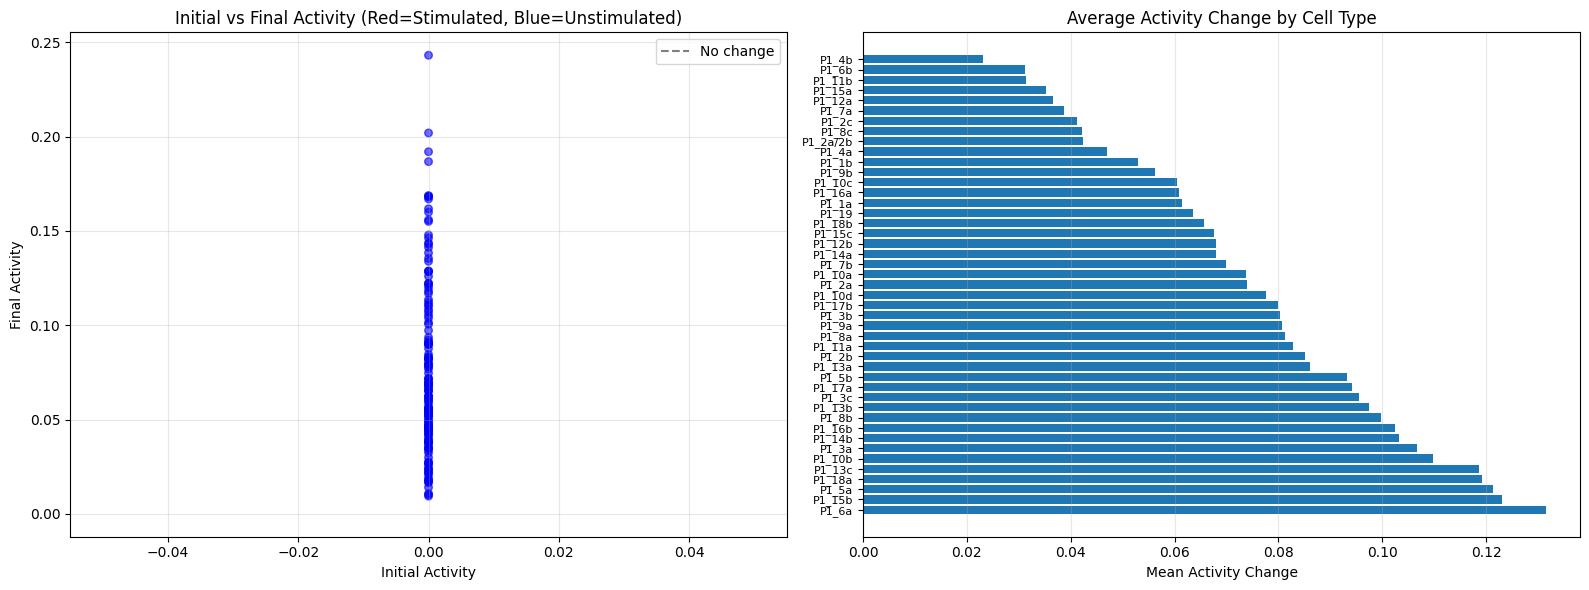

In [64]:
# Analyze which neurons are most activated (spreading from initial stimulus)
# Compare initial vs final activity

initial_activity = activity[0, :]
final_activity = activity[-1, :]
activity_change = final_activity - initial_activity

# Create a dataframe
activation_df = pd.DataFrame({
    'neuron_idx': np.arange(n_neurons),
    'type': neuron_types_in_matrix,
    'initial': initial_activity,
    'final': final_activity,
    'change': activity_change,
    'was_stimulated': [i in stimulated_indices for i in range(n_neurons)]
})

# Sort by activity change
activation_df = activation_df.sort_values(by='change', ascending=False)

print("Top 20 neurons with largest activity increase:")
print(activation_df.head(20)[['neuron_idx', 'type', 'initial', 'final', 'change', 'was_stimulated']])

print("\nTop 20 neurons with largest activity decrease:")
print(activation_df.tail(20)[['neuron_idx', 'type', 'initial', 'final', 'change', 'was_stimulated']])

# Visualize activity change
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter plot of initial vs final activity
ax1 = axes[0]
colors = ['red' if stim else 'blue' for stim in activation_df['was_stimulated']]
ax1.scatter(activation_df['initial'], activation_df['final'], 
           c=colors, alpha=0.6, s=30)
ax1.plot([0, activation_df['initial'].max()], [0, activation_df['initial'].max()], 
         'k--', alpha=0.5, label='No change')
ax1.set_xlabel('Initial Activity')
ax1.set_ylabel('Final Activity')
ax1.set_title('Initial vs Final Activity (Red=Stimulated, Blue=Unstimulated)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Activity change by cell type
ax2 = axes[1]
change_by_type = activation_df.groupby('type')['change'].mean().sort_values(ascending=False)
ax2.barh(range(len(change_by_type)), change_by_type.values)
ax2.set_yticks(range(len(change_by_type)))
ax2.set_yticklabels(change_by_type.index, fontsize=8)
ax2.set_xlabel('Mean Activity Change')
ax2.set_title('Average Activity Change by Cell Type')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [65]:
# Compare network dynamics across different excitatory strengths
strengths = [0.5, 1.0, 1.5, 2.0, 3.0]
activities_dict = {}

# Use the same stimulated neurons for fair comparison
np.random.seed(42)  # Set seed for reproducibility
initial_input_fixed = np.zeros(n_neurons)
n_stimulated = 5
stimulated_indices_fixed = np.random.choice(n_neurons, size=n_stimulated, replace=False)
initial_input_fixed[stimulated_indices_fixed] = 1.0

print("Running simulations for different excitatory strengths...")
for strength in strengths:
    act = simulate_network_dynamics(
        W, 
        initial_input_fixed, 
        n_steps=200, 
        tau=10.0, 
        dt=0.1, 
        nonlinearity='relu',
        noise_level=0.01,
        excitatory_strength=strength
    )
    activities_dict[strength] = act
    print(f"  Strength {strength}: Mean final activity = {act[-1, :].mean():.4f}")

print("Simulations complete!")

Running simulations for different excitatory strengths...
  Strength 0.5: Mean final activity = 0.0050
  Strength 1.0: Mean final activity = 0.0055
  Strength 1.5: Mean final activity = 0.0061
  Strength 2.0: Mean final activity = 0.0068
  Strength 3.0: Mean final activity = 0.0080
Simulations complete!


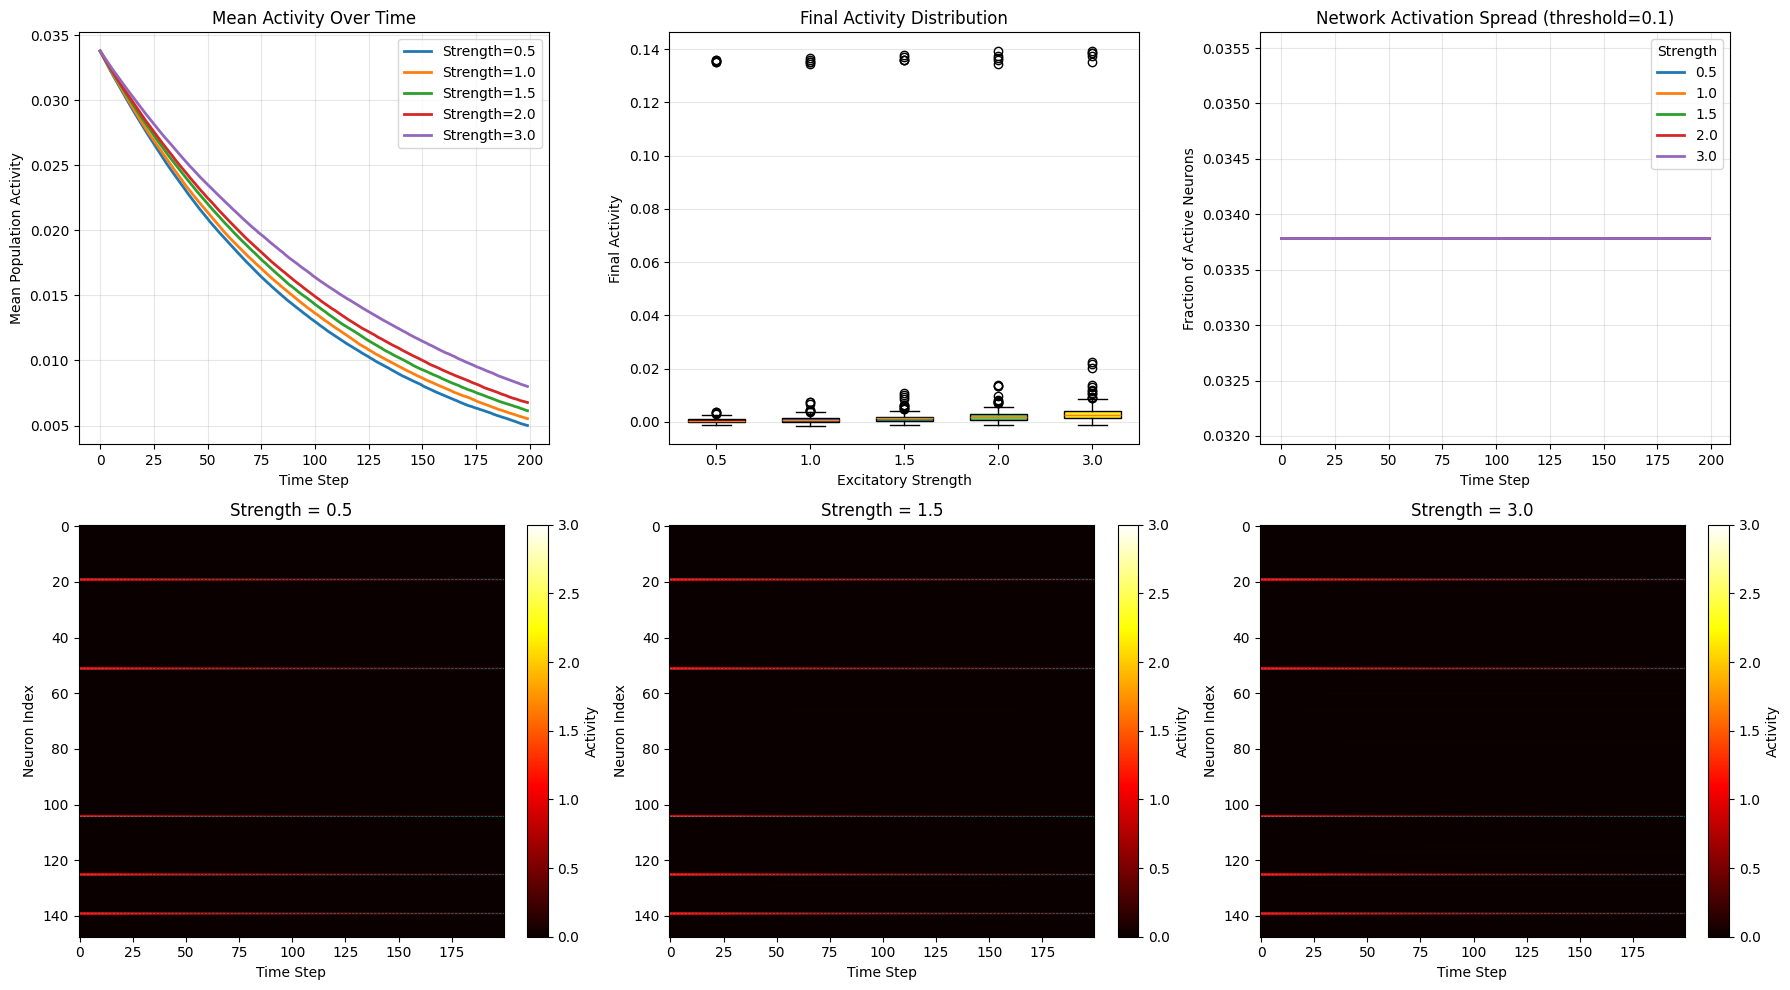

In [66]:
# Visualize comparison of different excitatory strengths
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Population activity over time for different strengths
ax1 = axes[0, 0]
for strength in strengths:
    mean_act = activities_dict[strength].mean(axis=1)
    ax1.plot(mean_act, label=f'Strength={strength}', linewidth=2)
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Mean Population Activity')
ax1.set_title('Mean Activity Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Final activity distributions
ax2 = axes[0, 1]
final_activities = [activities_dict[s][-1, :] for s in strengths]
positions = np.arange(len(strengths))
bp = ax2.boxplot(final_activities, positions=positions, widths=0.6, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.viridis(np.linspace(0, 1, len(strengths)))):
    patch.set_facecolor(color)
ax2.set_xticks(positions)
ax2.set_xticklabels([f'{s}' for s in strengths])
ax2.set_xlabel('Excitatory Strength')
ax2.set_ylabel('Final Activity')
ax2.set_title('Final Activity Distribution')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Activity spread (fraction of neurons activated)
ax3 = axes[0, 2]
threshold = 0.1  # Consider neuron "active" if activity > threshold
for strength in strengths:
    act = activities_dict[strength]
    active_fraction = [(act[t, :] > threshold).sum() / n_neurons for t in range(act.shape[0])]
    ax3.plot(active_fraction, label=f'{strength}', linewidth=2)
ax3.set_xlabel('Time Step')
ax3.set_ylabel('Fraction of Active Neurons')
ax3.set_title(f'Network Activation Spread (threshold={threshold})')
ax3.legend(title='Strength')
ax3.grid(True, alpha=0.3)

# 4. Heatmaps for low, medium, high strength
strength_examples = [0.5, 1.5, 3.0]
for idx, strength in enumerate(strength_examples):
    ax = axes[1, idx]
    im = ax.imshow(activities_dict[strength].T, aspect='auto', cmap='hot', 
                   interpolation='nearest', vmin=0, vmax=3)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Neuron Index')
    ax.set_title(f'Strength = {strength}')
    # Mark stimulated neurons
    for stim_idx in stimulated_indices_fixed:
        ax.axhline(stim_idx, color='cyan', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.colorbar(im, ax=ax, label='Activity', fraction=0.046)

plt.tight_layout()
plt.show()

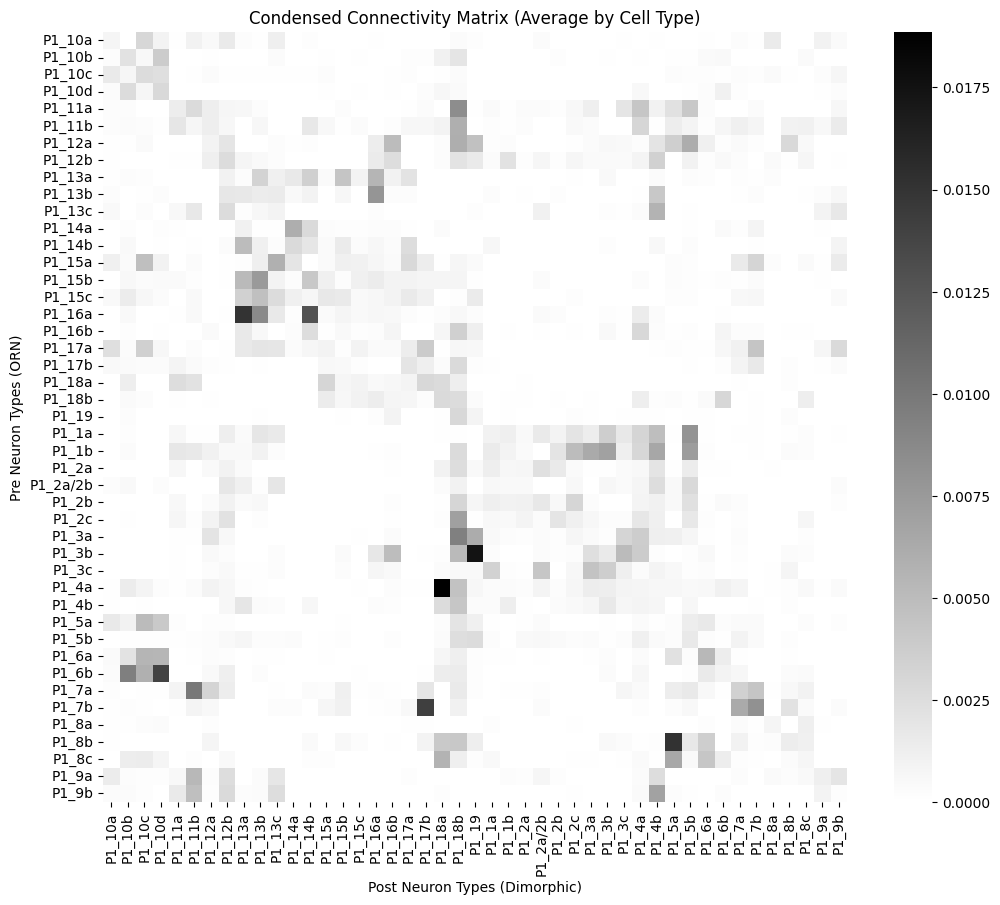

In [31]:
# Create a DataFrame from the sorted matrix
df_conn = pd.DataFrame(sorted_matrix, index=pre_neurons_types, columns=post_neurons_types)

# Group by index (pre_types) and take the mean
df_grouped_pre = df_conn.groupby(df_conn.index).mean()

# Transpose, group by index (post_types), take the mean, and transpose back
condensed_matrix = df_grouped_pre.T.groupby(df_grouped_pre.columns).mean().T

# Plot the condensed matrix
plt.figure(figsize=(12, 10))
sns.heatmap(condensed_matrix, cmap='binary', xticklabels=True, yticklabels=True)
plt.xlabel('Post Neuron Types (Dimorphic)')
plt.ylabel('Pre Neuron Types (ORN)')
plt.title('Condensed Connectivity Matrix (Average by Cell Type)')
plt.show()

In [42]:
import networkx as nx
from modularity_maximization import partition



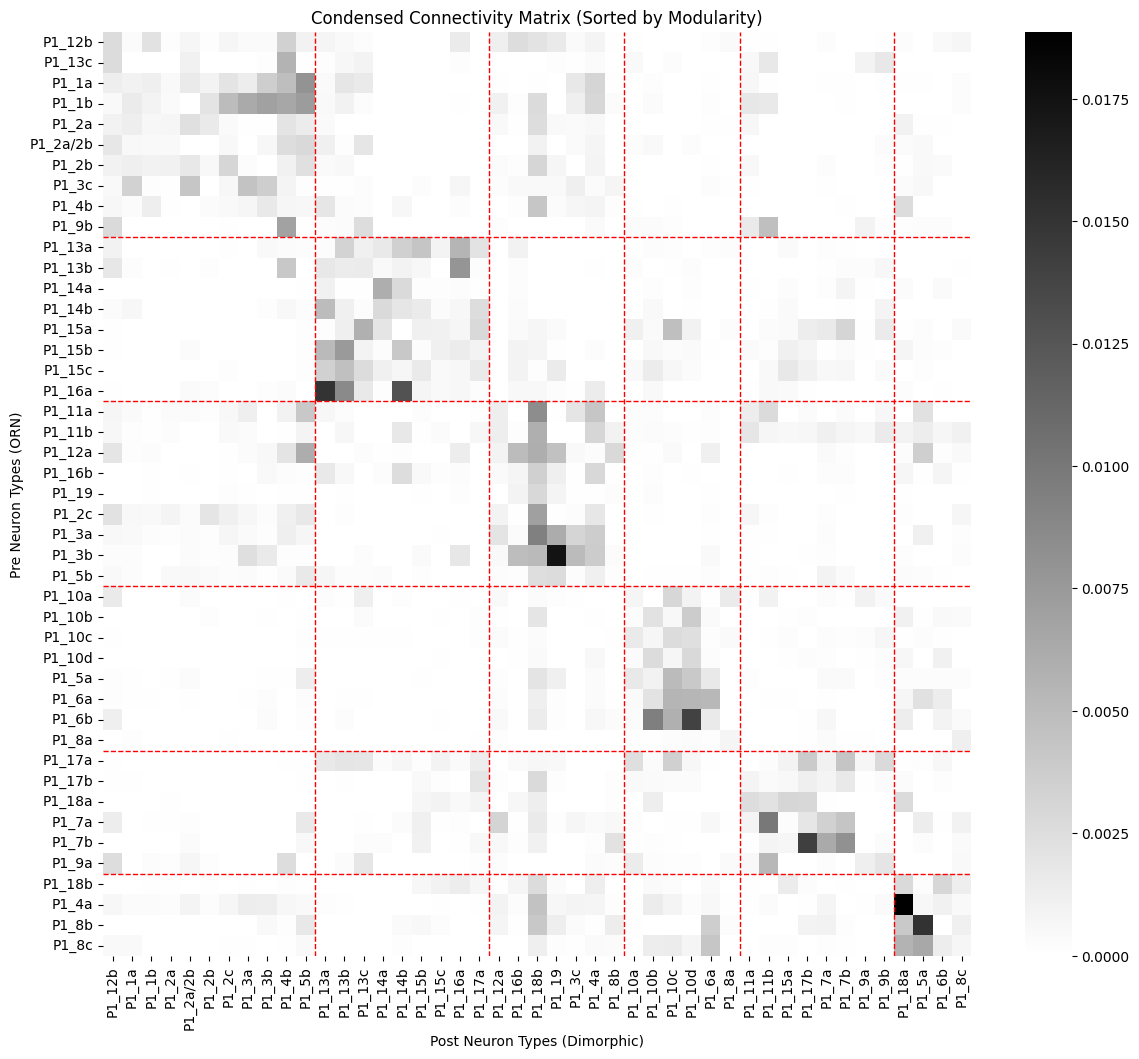

In [ ]:


# Perform modularity maximization to find community structure
# Use the condensed matrix (cell type to cell type)
matrix_for_clustering = condensed_matrix.fillna(0)

# Create a bipartite graph
G = nx.Graph()
pre_nodes = [f"Pre_{x}" for x in matrix_for_clustering.index]
post_nodes = [f"Post_{x}" for x in matrix_for_clustering.columns]
G.add_nodes_from(pre_nodes, bipartite=0)
G.add_nodes_from(post_nodes, bipartite=1)

# Add weighted edges
for r in matrix_for_clustering.index:
    for c in matrix_for_clustering.columns:
        w = matrix_for_clustering.loc[r, c]
        if w > 0:
            G.add_edge(f"Pre_{r}", f"Post_{c}", weight=w)

# Find communities
communities = greedy_modularity_communities(G, weight='weight')

# Map types to communities
pre_comm = {}
post_comm = {}
for i, comm in enumerate(communities):
    for node in comm:
        if node.startswith("Pre_"):
            pre_comm[node[4:]] = i
        elif node.startswith("Post_"):
            post_comm[node[5:]] = i

# Sort indices by community ID
sorted_rows = sorted(matrix_for_clustering.index, key=lambda x: (pre_comm.get(x, -1), x))
sorted_cols = sorted(matrix_for_clustering.columns, key=lambda x: (post_comm.get(x, -1), x))

# Reorder matrix
sorted_matrix_comm = matrix_for_clustering.loc[sorted_rows, sorted_cols]

# Plot the sorted matrix with community boundaries
plt.figure(figsize=(14, 12))
sns.heatmap(sorted_matrix_comm, cmap='binary', xticklabels=True, yticklabels=True)

# Draw community boundaries
for i in range(len(sorted_rows)-1):
    if pre_comm.get(sorted_rows[i]) != pre_comm.get(sorted_rows[i+1]):
        plt.axhline(i+1, color='red', linewidth=1, linestyle='--')

for i in range(len(sorted_cols)-1):
    if post_comm.get(sorted_cols[i]) != post_comm.get(sorted_cols[i+1]):
        plt.axvline(i+1, color='red', linewidth=1, linestyle='--')

plt.xlabel('Post Neuron Types (Dimorphic)')
plt.ylabel('Pre Neuron Types (ORN)')
plt.title('Condensed Connectivity Matrix (Sorted by Modularity)')
plt.show()

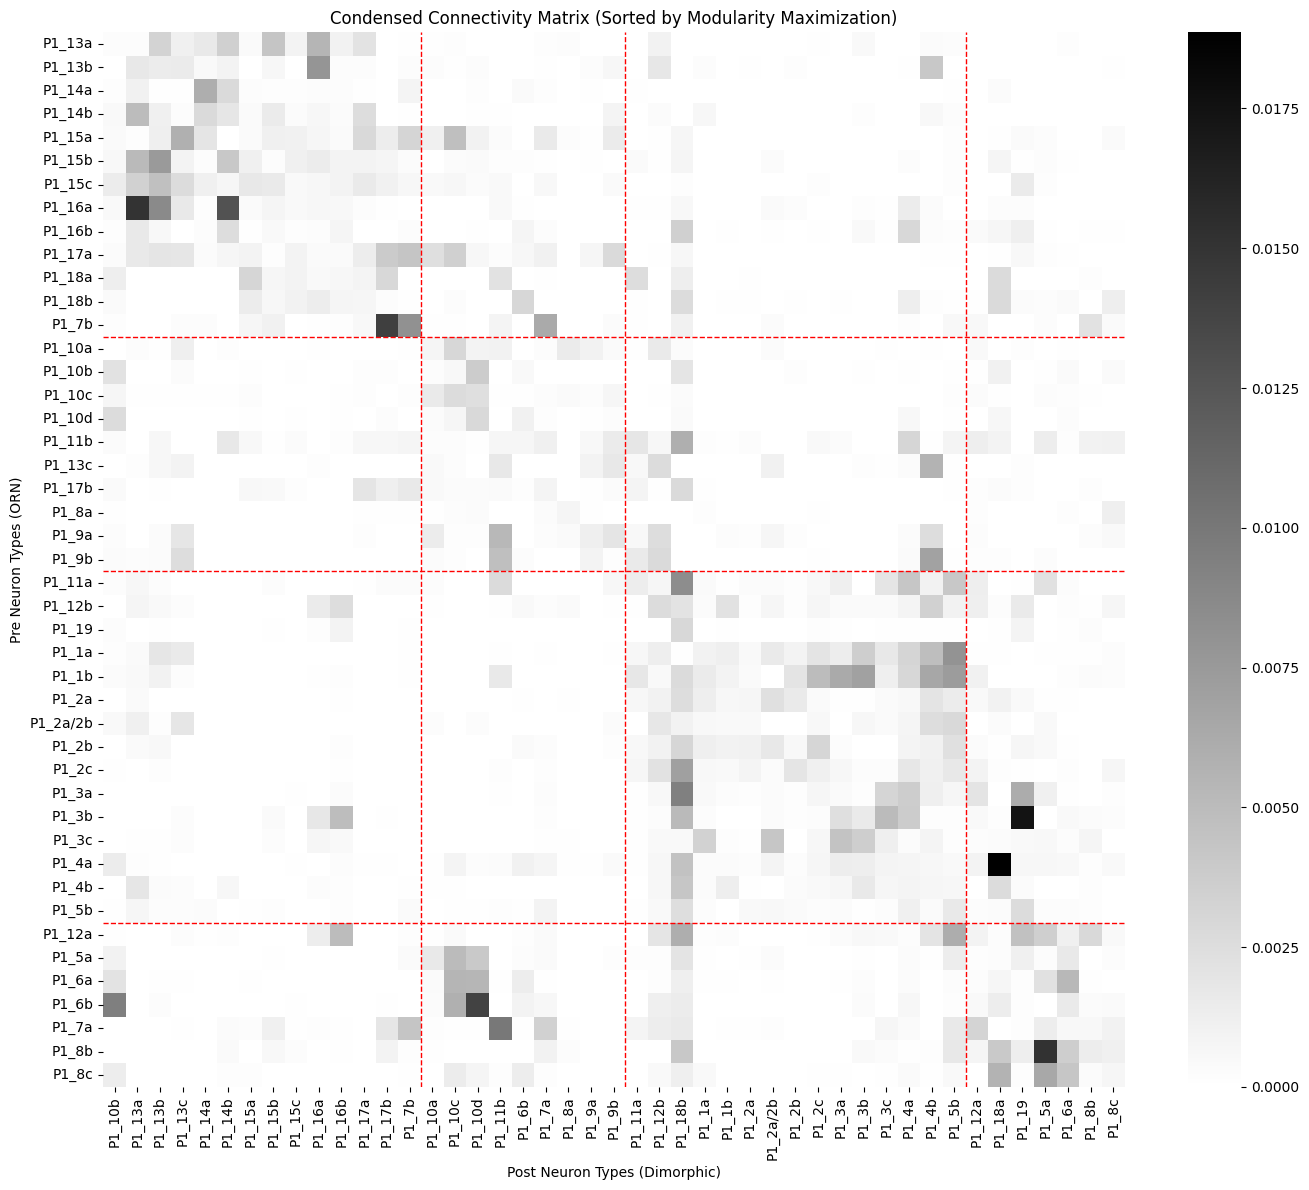

In [46]:
import networkx as nx
from modularity_maximization import partition

# Perform modularity maximization to find community structure
# Use the condensed matrix (cell type to cell type)
matrix_for_clustering = condensed_matrix.fillna(0)

# Create a graph from the condensed matrix
G = nx.Graph()

# Add nodes
pre_nodes = [f"Pre_{x}" for x in matrix_for_clustering.index]
post_nodes = [f"Post_{x}" for x in matrix_for_clustering.columns]
G.add_nodes_from(pre_nodes)
G.add_nodes_from(post_nodes)

threshold = np.percentile(condensed_matrix.values,50)

# Add weighted edges
for r in matrix_for_clustering.index:
    for c in matrix_for_clustering.columns:
        w = matrix_for_clustering.loc[r, c]
        if w > threshold:
            G.add_edge(f"Pre_{r}", f"Post_{c}", weight=w)

# Find communities using modularity maximization
communities = partition(G)

# Map types to communities
pre_comm = {}
post_comm = {}
for node, comm_id in communities.items():
    if node.startswith("Pre_"):
        pre_comm[node[4:]] = comm_id
    elif node.startswith("Post_"):
        post_comm[node[5:]] = comm_id

# Sort indices by community ID
sorted_rows = sorted(matrix_for_clustering.index, key=lambda x: (pre_comm.get(x, -1), x))
sorted_cols = sorted(matrix_for_clustering.columns, key=lambda x: (post_comm.get(x, -1), x))

# Reorder matrix
sorted_matrix_comm = matrix_for_clustering.loc[sorted_rows, sorted_cols]

# Plot the sorted matrix with community boundaries
plt.figure(figsize=(14, 12))
sns.heatmap(sorted_matrix_comm, cmap='binary', xticklabels=True, yticklabels=True)

# Draw community boundaries
for i in range(len(sorted_rows)-1):
    if pre_comm.get(sorted_rows[i]) != pre_comm.get(sorted_rows[i+1]):
        plt.axhline(i+1, color='red', linewidth=1, linestyle='--')

for i in range(len(sorted_cols)-1):
    if post_comm.get(sorted_cols[i]) != post_comm.get(sorted_cols[i+1]):
        plt.axvline(i+1, color='red', linewidth=1, linestyle='--')

plt.xlabel('Post Neuron Types (Dimorphic)')
plt.ylabel('Pre Neuron Types (ORN)')
plt.title('Condensed Connectivity Matrix (Sorted by Modularity Maximization)')
plt.tight_layout()
plt.show()

In [ ]:
neurons[0]['statusLabel'].unique()
# get count of each statusLabel
status_counts = pd.Series(neurons[0]['statusLabel']).value_counts()
# pie chart of status counts
plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Neuron Status Distribution')
plt.show()

In [6]:
neurons[0]['class'].unique()

array([None, 'MBON', 'ALPN', 'CX', 'ol_bilateral', 'ALLN', 'ALIN', 'DAN',
       'mechanosensory', 'ALON', 'unknown_sensory', 'visual', 'olfactory',
       'Kenyon_Cell', 'gustatory', 'thermosensory',
       'mechanosensory_proprioceptive', 'hygrosensory', 'chemosensory',
       'mechanosensory_tbc', 'mechanosensory_tactile'], dtype=object)

In [39]:
conn_matrix

,body_pre,body_post,weight,total_weight,normalized_weight
0,10352,10351,2591,45229,0.057286
1,13612,16076,2385,37118,0.064255
2,10663,10051,2248,58038,0.038733
3,10289,10611,2230,54910,0.040612
4,10893,10066,1929,77367,0.024933
...,...,...,...,...,...
151871789,54588,878777930,1,1,1.000000
151871790,54588,864658553,1,1,1.000000
151871791,54588,864364339,1,4,0.250000
151871792,54588,862568438,1,3,0.333333


In [30]:
JOs = neurons[0][neurons[0]['type'].str.startswith('JO').fillna(False)]
KCs = neurons[0][neurons[0]['type'].str.startswith('KC').fillna(False)]
# sort by type
JOs = JOs.sort_values(by='type').reset_index(drop=True)
KCs = KCs.sort_values(by='type').reset_index(drop=True)

# path from JOs to KCs
JO_bodyIds = JOs['bodyId'].values
KC_bodyIds = KCs['bodyId'].values

# 1st order
first_order_JO_KC_matrix = create_first_order_connection_matrix(JO_bodyIds, KC_bodyIds)
# check how many non-zero connections there are
nonzero_connections = np.sum(first_order_JO_KC_matrix > 0)
print(f'Number of non-zero first order connections from JOs to KCs: {nonzero_connections}')


/var/folders/y6/xn2dyw2s14b79mrpmzrhykhc0000gn/T/ipykernel_79920/2630732664.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  JOs = neurons[0][neurons[0]['type'].str.startswith('JO').fillna(False)]
/var/folders/y6/xn2dyw2s14b79mrpmzrhykhc0000gn/T/ipykernel_79920/2630732664.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  KCs = neurons[0][neurons[0]['type'].str.startswith('KC').fillna(False)]


Number of non-zero first order connections from JOs to KCs: 0


In [32]:
# 2nd order
second_order_JO_KC_matrix, I_neurons, pre_common_matrix, common_post_matrix = create_second_order_connection_matrix(JO_bodyIds, KC_bodyIds)
# check how many non-zero connections there are
nonzero_connections_2nd = np.sum(second_order_JO_KC_matrix > 0)
print(f'Number of non-zero second order connections from JOs to KCs: {nonzero_connections_2nd}')
print(f'Max second order connection weight: {np.max(second_order_JO_KC_matrix)}')

Number of non-zero second order connections from JOs to KCs: 2603
Max second order connection weight: 0.007229087760851357


In [33]:
# 3rd order
third_order_JO_KC_matrix, I1_neurons, I2_neurons, pre_I1_matrix, I1_I2_matrix, I2_post_matrix = create_third_order_connection_matrix(JO_bodyIds, KC_bodyIds)
# check how many non-zero connections there are
nonzero_connections_3rd = np.sum(third_order_JO_KC_matrix > 0)
print(f'Number of non-zero third order connections from JOs to KCs: {nonzero_connections_3rd}')
print(f'Max third order connection weight: {np.max(third_order_JO_KC_matrix)}')

Number of non-zero third order connections from JOs to KCs: 1578064
Max third order connection weight: 0.025934876715685097


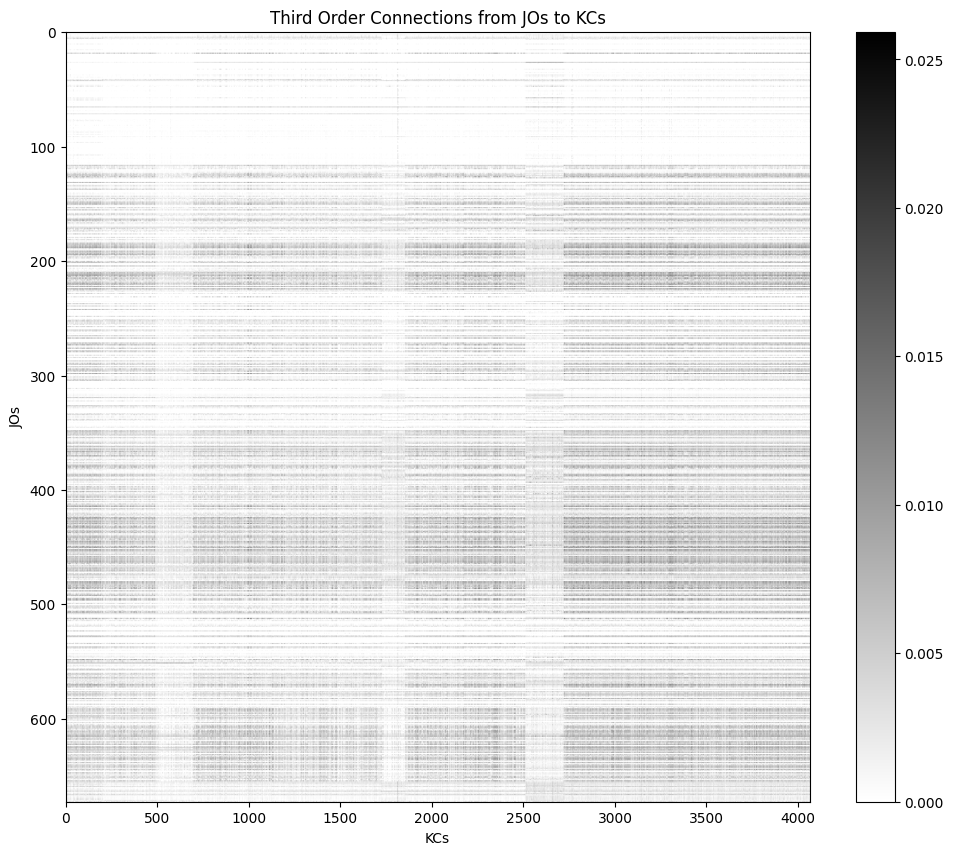

In [34]:
# plot the JO to KC third order connections as a heatmap
plt.figure(figsize=(12, 10))
plt.imshow(third_order_JO_KC_matrix, cmap='binary', aspect='auto')
plt.colorbar()
plt.title('Third Order Connections from JOs to KCs')
plt.xlabel('KCs')
plt.ylabel('JOs')
plt.show()

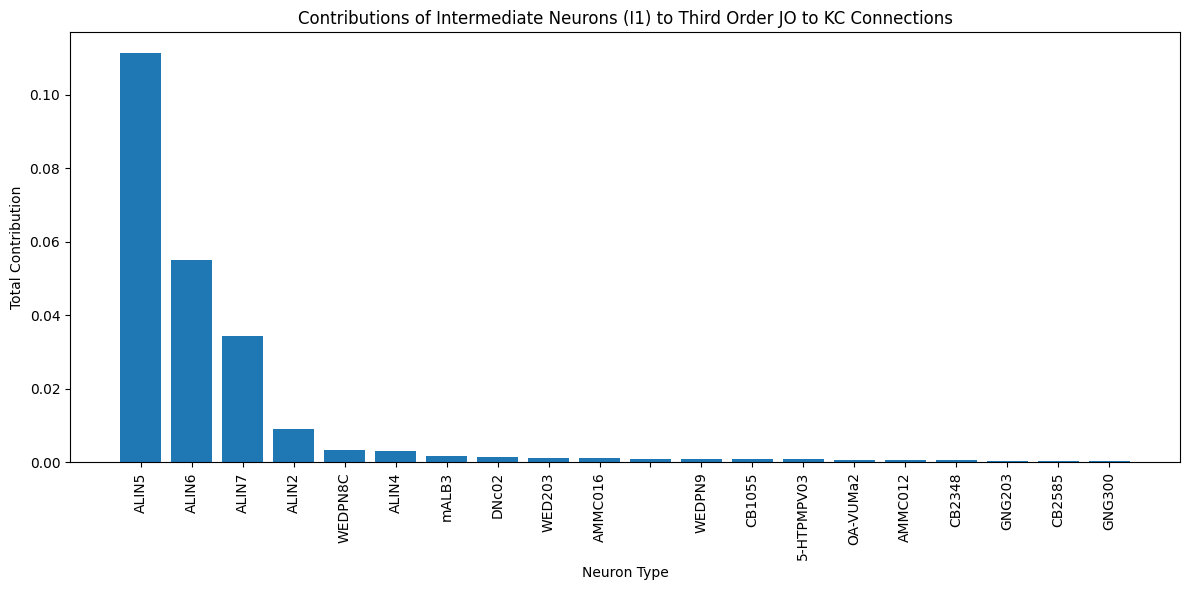

In [38]:
# get identities of intermediate neurons
I1_types = map_to_celltypes(I1_neurons, neurons[0])
# estimate contribution of each I1 neuron to the third order connections
# total input into each I1 from JOs
I1_in = np.sum(pre_I1_matrix, axis=0)  # shape: (len(I1_neurons),)
# total downstream drive from each I1 to KCs via I2
I1_downstream = (I1_I2_matrix @ I2_post_matrix).sum(axis=1)  # shape: (len(I1_neurons),)
# elementwise contribution per I1
I1_contributions = I1_in * I1_downstream
# sum contributions by cell type
I1_contrib_df = pd.DataFrame({'type': I1_types.flatten(), 'contribution': I1_contributions.flatten()})
I1_contrib_summary = I1_contrib_df.groupby('type')['contribution'].sum().reset_index()
# sort by contribution
I1_contrib_summary = I1_contrib_summary.sort_values(by='contribution', ascending=False)

In [39]:
# get ALIN5 neurons
ALIN5_neurons = neurons[0][neurons[0]['type'] == 'ALIN5']
ALIN5_neurons

,bodyId,instance,type,pre,post,downstream,upstream,size,status,statusLabel,...,assignedOlHex2,group,supertype,mancBodyid,totalNtPredictions,predictedNt,mancGroup,serialMotif,inputRois,outputRois
1452,11558,ALIN5_R,ALIN5,2681,2157,17230,2157,3.056877e+09,Traced,Roughly traced,...,NaN,11558.0,None,NaN,2681.0,gaba,NaN,None,"[AL(L), AMMC(L), AMMC(R), CAN(L), CAN(R), Cent...","[AL(L), AMMC(L), AMMC(R), CentralBrain, Centra..."
139282,529602,ALIN5_L,ALIN5,2968,2513,19021,2513,3.204405e+09,Traced,Roughly traced,...,NaN,11558.0,None,NaN,2968.0,gaba,NaN,None,"[AL(R), AMMC(L), AMMC(R), CAN(L), CAN(R), Cent...","[AL(R), AMMC(L), AMMC(R), CentralBrain, Centra..."


In [ ]:
# plot contributions as a bar graph
plt.figure(figsize=(12, 6))
plt.bar(I1_contrib_summary['type'][:20], I1_contrib_summary['contribution'][:20])
plt.xticks(rotation=90)
plt.title('Contributions of Intermediate Neurons (I1) to Third Order JO to KC Connections')
plt.xlabel('Neuron Type')
plt.ylabel('Total Contribution')
plt.tight_layout()

In [7]:
ORNs = neurons[0][neurons[0]['class']=='olfactory']
ORNs.head()

,bodyId,instance,type,pre,post,downstream,upstream,size,status,statusLabel,...,assignedOlHex2,group,supertype,mancBodyid,totalNtPredictions,predictedNt,mancGroup,serialMotif,inputRois,outputRois
1062,11151,ORN_VA1v_R,ORN_VA1v,184,236,816,236,188323135.0,Traced,Prelim Roughly traced,...,NaN,NaN,None,NaN,184.0,acetylcholine,NaN,None,"[AL(L), AL(R), CentralBrain]","[AL(L), AL(R), CentralBrain]"
7441,18147,ORN_VA2_R,ORN_VA2,248,266,1053,266,147626008.0,Traced,Prelim Roughly traced,...,NaN,NaN,None,NaN,248.0,acetylcholine,NaN,None,"[AL(L), AL(R), CentralBrain, CentralBrain-unsp...","[AL(L), AL(R), CentralBrain, CentralBrain-unsp..."
14663,26225,ORN_VM6v_R,ORN_VM6v,318,335,1720,335,269832844.0,Traced,Prelim Roughly traced,...,NaN,NaN,None,NaN,318.0,acetylcholine,NaN,None,"[AL(L), AL(R), CentralBrain, CentralBrain-unsp...","[AL(L), AL(R), CentralBrain]"
14719,26286,ORN_VM6v_R,ORN_VM6v,327,360,1844,360,214858519.0,Traced,Reviewed,...,NaN,NaN,None,NaN,327.0,acetylcholine,NaN,None,"[AL(L), AL(R), CentralBrain, CentralBrain-unsp...","[AL(L), AL(R), CentralBrain, CentralBrain-unsp..."
15487,27153,ORN_VA1v_R,ORN_VA1v,200,238,920,238,205856885.0,Traced,Prelim Roughly traced,...,NaN,NaN,None,NaN,200.0,acetylcholine,NaN,None,"[AL(L), AL(R), CentralBrain, CentralBrain-unsp...","[AL(L), AL(R), CentralBrain]"


In [ ]:
ORN_type = ORNs['flywireType']
ORN_sides = ORNs['rootSide'].apply(lambda x: -1 if x=='L' else (1 if x=='R' else 0))
AL_L_partners = ORNs['roiInfo'].apply(lambda x: x.get('AL(L)', {'post': 0}).get('post',0))
AL_R_partners = ORNs['roiInfo'].apply(lambda x: x.get('AL(R)', {'post': 0}).get('post',0))
LI_partner = (AL_R_partners - AL_L_partners) / (AL_R_partners + AL_L_partners + 1e-9) * ORN_sides

AL_L_synapses = ORNs['roiInfo'].apply(lambda x: x.get('AL(L)', {'downstream': 0}).get('downstream',0))
AL_R_synapses = ORNs['roiInfo'].apply(lambda x: x.get('AL(R)', {'downstream': 0}).get('downstream',0))
LI_synapse = (AL_R_synapses - AL_L_synapses) / (AL_R_synapses + AL_L_synapses + 1e-9) * ORN_sides

LI_dataframe = pd.DataFrame({'ORN_type': ORN_type, 'LI_partner': LI_partner, 'LI_synapse': LI_synapse, 'ORN_side':ORN_sides})

LI_dataframe.to_csv('male-cns-ORN-LI.csv', index=False)

/var/folders/y6/xn2dyw2s14b79mrpmzrhykhc0000gn/T/ipykernel_27189/1783814466.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ORN_type', y='LI_partner', data=LI_dataframe, order=order, fliersize=0, palette='vlag', showcaps=False)


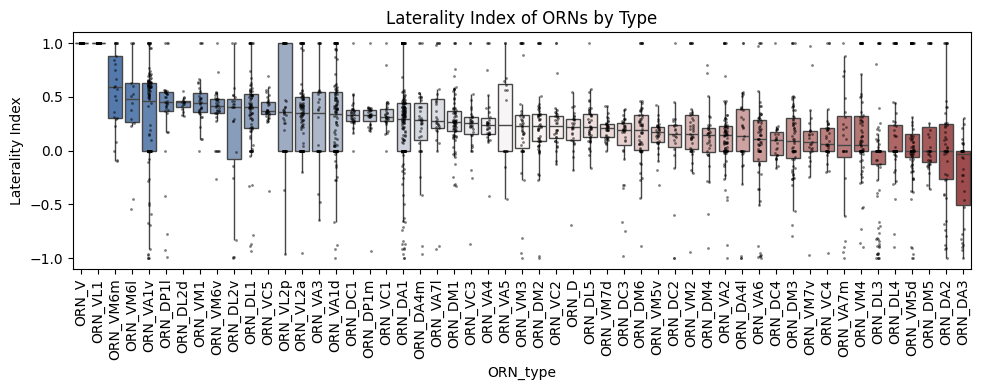

In [35]:
# plot aggregate laterality index by type (sorted by median laterality index)
order = LI_dataframe.groupby('ORN_type')['LI_partner'].median().sort_values(ascending=False).index

plt.figure(figsize=(10,4))
sns.boxplot(x='ORN_type', y='LI_partner', data=LI_dataframe, order=order, fliersize=0, palette='vlag', showcaps=False)
sns.stripplot(x='ORN_type', y='LI_partner', data=LI_dataframe, order=order, color='k', size=2, alpha=0.5, jitter=True)
plt.xticks(rotation=90)
plt.ylabel('Laterality Index')
plt.title('Laterality Index of ORNs by Type')
plt.tight_layout()
plt.show()


/var/folders/y6/xn2dyw2s14b79mrpmzrhykhc0000gn/T/ipykernel_27189/2226203355.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ORN_type', y='LI_synapse', data=LI_dataframe, order=order, fliersize=0, palette='vlag', showcaps=False)


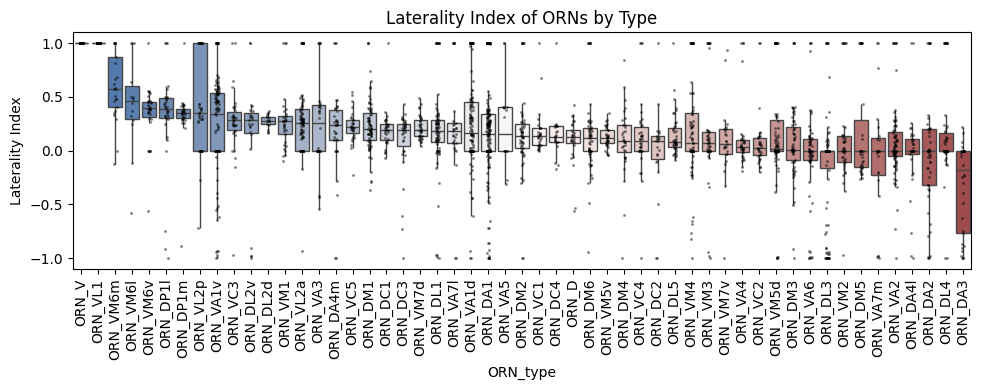

In [36]:
# plot aggregate laterality index by type (sorted by median laterality index)
order = LI_dataframe.groupby('ORN_type')['LI_synapse'].median().sort_values(ascending=False).index

plt.figure(figsize=(10,4))
sns.boxplot(x='ORN_type', y='LI_synapse', data=LI_dataframe, order=order, fliersize=0, palette='vlag', showcaps=False)
sns.stripplot(x='ORN_type', y='LI_synapse', data=LI_dataframe, order=order, color='k', size=2, alpha=0.5, jitter=True)
plt.xticks(rotation=90)
plt.ylabel('Laterality Index')
plt.title('Laterality Index of ORNs by Type')
plt.tight_layout()
plt.show()


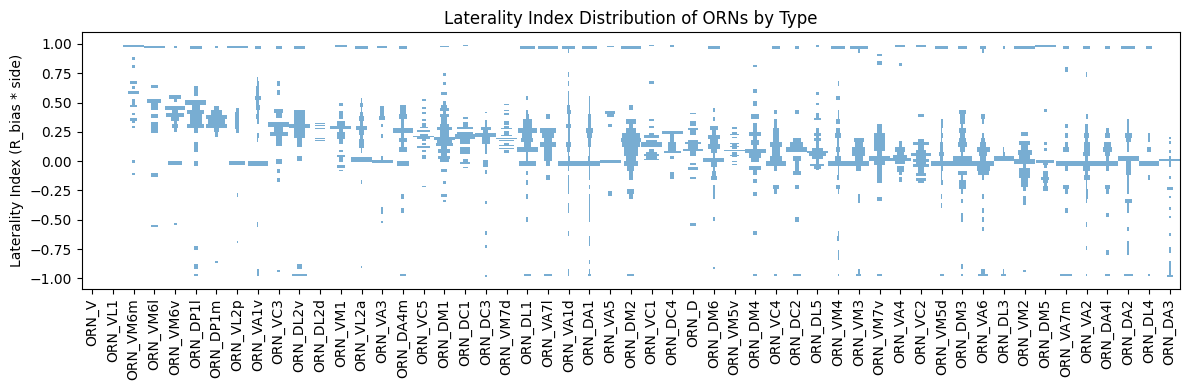

In [34]:
def mirrored_histogram_violin(df, x, y, bins=20, width=0.8, ax=None, order=None, **hist_kwargs):
    """
    Draw a violin-like histogram for each category by mirroring histograms horizontally.
    - x: categorical column name
    - y: numeric column name
    - bins: number of bins (or bin edges) for histogram
    - width: total width allocated per “violin”
    - order: list specifying the order of the categorical values on the x-axis 
    - hist_kwargs: passed to np.histogram (e.g. density=True, etc.)
    """
    if ax is None:
        fig, ax = plt.subplots()

    cats = order if order is not None else df[x].unique()
    n = len(cats)
    spacing = width  # spacing between centers
    half_width = width / 2

    for i, cat in enumerate(cats):
        ys = df.loc[df[x] == cat, y].dropna().values
        if len(ys) == 0:
            continue

        # compute histogram
        counts, bin_edges = np.histogram(ys, bins=bins, **hist_kwargs)

        # bin centers
        centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        # normalize to max width (so the largest histogram reaches half_width)
        max_count = counts.max()
        scale = half_width / max_count if max_count > 0 else 0

        # left side (mirror)
        ax.fill_betweenx(
            centers,
            i * spacing - counts * scale,
            i * spacing,
            step='mid',
            facecolor='C0',
            alpha=0.6
        )
        # right side
        ax.fill_betweenx(
            centers,
            i * spacing,
            i * spacing + counts * scale,
            step='mid',
            facecolor='C0',
            alpha=0.6
        )

    # set x ticks at the center positions
    ax.set_xticks(np.arange(n) * spacing)
    ax.set_xticklabels(cats)
    ax.set_xlim(-spacing * 0.5, spacing * (n - 0.5))
    return ax

fig, ax = plt.subplots(figsize=(12, 4))
mirrored_histogram_violin(LI_dataframe, x='ORN_type', y='LI_synapse', bins=50, width=0.5, ax=ax, order=order, density=True)
ax.set_ylabel('Laterality Index (R_bias * side)')
ax.set_title('Laterality Index Distribution of ORNs by Type')
plt.xticks(rotation=90)
plt.tight_layout()